# Loan Approval Analytics and Prediction System

## Task 1 — Data Handling and Dataset Integration

This study examines loan application records with the objective of establishing a reliable analytical foundation for evaluating loan approval decisions. The information required for the analysis is distributed across two datasets; therefore, the initial stage focuses on understanding the structure and content of each data source before integration.

Prior to combining the datasets, their dimensions, attributes, data types and potential identifying variables are examined independently. Particular attention is given to identifying a suitable primary key and verifying its integrity through uniqueness, missing-value and duplication checks. This validation is necessary because an inappropriate integration strategy could introduce duplicate observations, unmatched applications or information loss, potentially affecting subsequent exploratory analysis and model development.

### 1.1 Importing Required Libraries

In [2]:
# Core libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Improve dataframe display within the notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Required libraries imported successfully.")

Required libraries imported successfully.


### 1.2 Importing the Loan Approval Datasets

The two source datasets are imported independently using Pandas so that their structures can be examined before integration. Keeping the datasets separate at this stage allows their dimensions, attributes and record-level identifiers to be validated prior to selecting an appropriate merging strategy.

In [3]:
# Import the two source datasets
df1 = pd.read_csv("../data/Loan_Approval_Data_Set_1.csv")
df2 = pd.read_csv("../data/Loan_Approval_Data_Set_2.csv")

print("Dataset 1 loaded successfully.")
print("Dataset 2 loaded successfully.")

Dataset 1 loaded successfully.
Dataset 2 loaded successfully.


In [4]:
print(f"Dataset 1 dimensions: {df1.shape[0]:,} rows × {df1.shape[1]} columns")
print(f"Dataset 2 dimensions: {df2.shape[0]:,} rows × {df2.shape[1]} columns")

Dataset 1 dimensions: 20,000 rows × 16 columns
Dataset 2 dimensions: 20,000 rows × 18 columns


### 1.3 Initial Inspection of Dataset 1

Dataset 1 contains information relating primarily to applicants' employment, income, existing debt commitments, credit history and overall financial position. It also includes "LoanApproved", the binary response variable representing the final loan decision and therefore the principal target for the later predictive analysis.

Before integrating the two data sources, Dataset 1 is examined independently to establish its structural characteristics and identify potential data-quality concerns. The inspection considers representative observations, variable names, assigned data types and completeness. Although "ID" appears to represent an application-level identifier, its validity as a primary key will be formally assessed through uniqueness, duplication and missing-value checks before the datasets are merged.

In [5]:
# Display a sample of Dataset 1
display(df1.head())


,ID,ApplicationDate,AnnualIncome,EmploymentStatus,Experience,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,CheckingAccountBalance,TotalLiabilities,NetWorth,LoanApproved
0,A001,01-01-2018,39948,Employed,22,48,2,183,1,0,0,9,1202,19183,126928,0
1,A002,02-01-2018,39709,Employed,15,48,1,496,5,0,0,9,3460,9595,43609,0
2,A003,03-01-2018,40724,Employed,26,36,2,902,2,0,0,22,895,128874,5205,0
3,A004,04-01-2018,69084,Employed,34,96,1,755,2,0,0,10,1217,5370,99452,0
4,A005,05-01-2018,103264,Employed,17,36,1,274,0,0,0,27,4981,17286,227019,1


In [6]:
# Examine column names, non-null counts and data types
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ID                       20000 non-null  object
 1   ApplicationDate          20000 non-null  object
 2   AnnualIncome             20000 non-null  int64 
 3   EmploymentStatus         20000 non-null  object
 4   Experience               20000 non-null  int64 
 5   LoanDuration             20000 non-null  int64 
 6   NumberOfDependents       20000 non-null  int64 
 7   MonthlyDebtPayments      20000 non-null  int64 
 8   NumberOfOpenCreditLines  20000 non-null  int64 
 9   BankruptcyHistory        20000 non-null  int64 
 10  PreviousLoanDefaults     20000 non-null  int64 
 11  LengthOfCreditHistory    20000 non-null  int64 
 12  CheckingAccountBalance   20000 non-null  int64 
 13  TotalLiabilities         20000 non-null  int64 
 14  NetWorth                 20000 non-nul

In [7]:
# Summarise the data types in Dataset 1
dataset1_types = pd.DataFrame({
    "Column": df1.columns,
    "Data_Type": df1.dtypes.astype(str).values
})

display(dataset1_types)

,Column,Data_Type
0,ID,object
1,ApplicationDate,object
2,AnnualIncome,int64
3,EmploymentStatus,object
4,Experience,int64
5,LoanDuration,int64
6,NumberOfDependents,int64
7,MonthlyDebtPayments,int64
8,NumberOfOpenCreditLines,int64
9,BankruptcyHistory,int64


#### Dataset 1 — Initial Observations

The structural inspection shows that Dataset 1 contains 20,000 loan application records and 16 attributes. Thirteen variables are currently represented as integer-valued numerical features, while "ID", "ApplicationDate", and "EmploymentStatus" have been imported as object-type variables. No null values are reported at this initial stage, indicating that Dataset 1 is structurally complete with respect to conventional missing-value representations.

Although "ApplicationDate" is currently stored as an object, it represents temporal information and should therefore be converted to an appropriate datetime format during preprocessing. Similarly, while "LoanApproved" is numerically encoded as 0 and 1, it represents a binary categorical outcome rather than a continuous numerical measurement. These distinctions will be considered during subsequent preprocessing and modelling.

The absence of conventional null values does not, however, establish that the dataset is completely free from data-quality issues. Further investigation is required to identify duplicated records, invalid values, unusual distributions and potentially inconsistent representations.

### 1.4 Initial Inspection of Dataset 2

Dataset 2 extends the applicant information available in the first data source by incorporating demographic characteristics, educational background, credit behaviour, requested loan information, asset position and risk-related indicators. These variables provide additional dimensions that may help explain differences in loan approval outcomes.

Prior to integration, the dataset is examined independently to assess its dimensions, variable types and completeness. The "ID" attribute is of particular interest because it is also present in Dataset 1 and may provide the common identifier required to associate corresponding applicant records.

In [8]:
# Display a sample of Dataset 2
display(df2.head())

,ApplicationDate,Age,CreditScore,EducationLevel,Experience,LoanAmount,MaritalStatus,HomeOwnershipStatus,ID,CreditCardUtilizationRate,NumberOfCreditInquiries,LoanPurpose,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore
0,01-01-2018,45,617,Master,22.0,13152,Married,Own,A001,35.40,2,Home,29,7632,146111,11,22.75,49
1,02-01-2018,38,628,Associate,NaN,26045,Single,Mortgage,A002,8.78,3,Debt Consolidation,21,4627,53204,3,20.10,XX
2,03-01-2018,47,570,Bachelor,26.0,17627,Married,Rent,A003,13.70,0,Education,20,886,25176,6,21.25,XX
3,04-01-2018,58,545,High School,34.0,37898,Single,Mortgage,A004,2.67,1,Home,27,1675,104822,5,30.09,54
4,05-01-2018,37,594,Associate,17.0,9184,Married,Mortgage,A005,3.20,0,Debt Consolidation,26,1555,244305,5,17.59,36


In [9]:
# Examine column names, non-null counts and data types
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ApplicationDate            20000 non-null  object 
 1   Age                        20000 non-null  int64  
 2   CreditScore                20000 non-null  int64  
 3   EducationLevel             20000 non-null  object 
 4   Experience                 19334 non-null  float64
 5   LoanAmount                 20000 non-null  int64  
 6   MaritalStatus              19985 non-null  object 
 7   HomeOwnershipStatus        20000 non-null  object 
 8   ID                         20000 non-null  object 
 9   CreditCardUtilizationRate  20000 non-null  float64
 10  NumberOfCreditInquiries    20000 non-null  int64  
 11  LoanPurpose                20000 non-null  object 
 12  PaymentHistory             20000 non-null  int64  
 13  SavingsAccountBalance      20000 non-null  int

In [10]:
# Summarise the data types in Dataset 2
dataset2_types = pd.DataFrame({
    "Column": df2.columns,
    "Data_Type": df2.dtypes.astype(str).values
})

display(dataset2_types)

,Column,Data_Type
0,ApplicationDate,object
1,Age,int64
2,CreditScore,int64
3,EducationLevel,object
4,Experience,float64
5,LoanAmount,int64
6,MaritalStatus,object
7,HomeOwnershipStatus,object
8,ID,object
9,CreditCardUtilizationRate,float64


#### Dataset 2 — Initial Observations

Dataset 2 contains 20,000 observations and 18 attributes, comprising eight integer, three floating-point and seven object-type variables. Unlike Dataset 1, the initial structural assessment identifies explicit missing observations in two attributes. "Experience" contains 19,334 non-null records, indicating 666 missing values, while "MaritalStatus" contains 19,985 non-null records, corresponding to 15 missing observations.

A further data-quality concern is evident in "RiskScore". Although Pandas reports 20,000 non-null observations for this variable, it has been imported as an object rather than a numerical data type. Inspection of the source records indicates that non-numeric placeholders such as "XX" occur within this field. Consequently, the non-null count alone understates the true extent of missing or invalid information because these placeholders are interpreted as text rather than conventional null values.

"ApplicationDate" has similarly been imported as an object and will require conversion to a datetime representation before time-based analysis. These findings demonstrate the importance of examining both data types and underlying values rather than relying exclusively on conventional null-value counts when assessing data quality.

### 1.5 Primary Key Validation

The "ID" attribute occurs in both source datasets and therefore represents the principal candidate for linking corresponding loan application records. However, the presence of a common field does not by itself establish that it is a valid primary key. Prior to integration, the identifier is evaluated for completeness and uniqueness within each dataset, followed by an assessment of the degree of correspondence between the two sets of identifiers.

A suitable application-level key should contain no missing values, should uniquely identify individual records within each dataset, and should provide consistent correspondence between records across the two data sources. These checks reduce the risk of creating duplicate observations or unintended many-to-many relationships during the merge operation.

In [11]:
# Validate ID as a candidate primary key in both datasets
key_validation = pd.DataFrame({
    "Dataset": ["Dataset 1", "Dataset 2"],
    "Total_Rows": [len(df1), len(df2)],
    "Unique_IDs": [
        df1["ID"].nunique(),
        df2["ID"].nunique()
    ],
    "Missing_IDs": [
        df1["ID"].isna().sum(),
        df2["ID"].isna().sum()
    ],
    "Duplicate_IDs": [
        df1["ID"].duplicated().sum(),
        df2["ID"].duplicated().sum()
    ]
})

display(key_validation)

,Dataset,Total_Rows,Unique_IDs,Missing_IDs,Duplicate_IDs
0,Dataset 1,20000,20000,0,0
1,Dataset 2,20000,20000,0,0


In [12]:
# Examine the correspondence of IDs across the two datasets
ids_df1 = set(df1["ID"].dropna())
ids_df2 = set(df2["ID"].dropna())

common_ids = ids_df1.intersection(ids_df2)
only_df1 = ids_df1.difference(ids_df2)
only_df2 = ids_df2.difference(ids_df1)

print(f"Unique IDs in Dataset 1 : {len(ids_df1):,}")
print(f"Unique IDs in Dataset 2 : {len(ids_df2):,}")
print(f"IDs common to both       : {len(common_ids):,}")
print(f"IDs only in Dataset 1    : {len(only_df1):,}")
print(f"IDs only in Dataset 2    : {len(only_df2):,}")

Unique IDs in Dataset 1 : 20,000
Unique IDs in Dataset 2 : 20,000
IDs common to both       : 20,000
IDs only in Dataset 1    : 0
IDs only in Dataset 2    : 0


In [13]:
# Identify variables occurring in both source datasets
common_columns = sorted(
    set(df1.columns).intersection(df2.columns)
)

print("Columns shared by both datasets:")
for column in common_columns:
    print(f"- {column}")

Columns shared by both datasets:
- ApplicationDate
- Experience
- ID


#### Primary Key Assessment

The validation results provide strong evidence that "ID" is an appropriate primary key for integrating the two data sources. Each dataset contains 20,000 records and exactly 20,000 unique identifiers, with no missing or duplicated "ID" values. This establishes uniqueness and completeness of the candidate key within each individual dataset.

Cross-dataset comparison further shows that all 20,000 identifiers are shared between the two datasets, with no application identifiers occurring exclusively in either source. The datasets therefore exhibit complete one-to-one correspondence at the application level. On this basis, "ID" can be used as the primary merge key while preserving the expected 20,000 application records.

The schema comparison also identifies "ApplicationDate" and "Experience" as attributes occurring in both datasets. These overlapping variables require additional consistency checks before integration to avoid retaining redundant or conflicting versions of the same information.

In [14]:
# Compare ApplicationDate values between the two datasets by ID
date_comparison = df1[["ID", "ApplicationDate"]].merge(
    df2[["ID", "ApplicationDate"]],
    on="ID",
    how="inner",
    suffixes=("_df1", "_df2"),
    validate="one_to_one"
)

date_comparison["Date_Match"] = (
    date_comparison["ApplicationDate_df1"]
    == date_comparison["ApplicationDate_df2"]
)

print("ApplicationDate consistency check")
print("-" * 40)
print(f"Matching dates    : {date_comparison['Date_Match'].sum():,}")
print(f"Non-matching dates: {(~date_comparison['Date_Match']).sum():,}")

ApplicationDate consistency check
----------------------------------------
Matching dates    : 2,922
Non-matching dates: 17,078


In [15]:
# Compare Experience values between datasets using the common ID
experience_comparison = df1[["ID", "Experience"]].merge(
    df2[["ID", "Experience"]],
    on="ID",
    how="inner",
    suffixes=("_df1", "_df2"),
    validate="one_to_one"
)

# Compare values only where Dataset 2 contains Experience
available_experience = experience_comparison[
    experience_comparison["Experience_df2"].notna()
].copy()

experience_matches = (
    available_experience["Experience_df1"]
    == available_experience["Experience_df2"]
)

print("Experience consistency check")
print("-" * 40)
print(f"Dataset 1 non-null Experience : {df1['Experience'].notna().sum():,}")
print(f"Dataset 2 non-null Experience : {df2['Experience'].notna().sum():,}")
print(f"Dataset 2 missing Experience  : {df2['Experience'].isna().sum():,}")
print(f"Comparable records            : {len(available_experience):,}")
print(f"Matching values               : {experience_matches.sum():,}")
print(f"Non-matching values           : {(~experience_matches).sum():,}")


Experience consistency check
----------------------------------------
Dataset 1 non-null Experience : 20,000
Dataset 2 non-null Experience : 19,334
Dataset 2 missing Experience  : 666
Comparable records            : 19,334
Matching values               : 19,334
Non-matching values           : 0


### 1.6 Investigation of Overlapping Attributes

The comparison of the duplicated "Experience" attribute demonstrates complete agreement across all 19,334 records for which Dataset 2 contains an observed value. Dataset 2 nevertheless contains 666 missing "Experience" observations, whereas Dataset 1 provides a complete value for every applicant. This suggests that the version contained in Dataset 1 can be retained during integration without requiring statistical imputation, subject to the established cross-source consistency.

In contrast, direct comparison of "ApplicationDate" produces a substantial number of apparent mismatches. Since the variable was imported as an object in both datasets, these differences may reflect inconsistent textual date representations rather than genuine disagreement in application dates. The discrepant records are therefore examined before determining how the duplicated date fields should be reconciled.

In [16]:
# Inspect examples where ApplicationDate does not match
date_mismatches = date_comparison[
    ~date_comparison["Date_Match"]
].copy()

display(date_mismatches.head(15))

,ID,ApplicationDate_df1,ApplicationDate_df2,Date_Match
2922,A2923,01-01-2018,01-01-2026,False
2923,A2924,02-01-2018,02-01-2026,False
2924,A2925,03-01-2018,03-01-2026,False
2925,A2926,04-01-2018,04-01-2026,False
2926,A2927,05-01-2018,05-01-2026,False
2927,A2928,06-01-2018,06-01-2026,False
2928,A2929,07-01-2018,07-01-2026,False
2929,A2930,08-01-2018,08-01-2026,False
2930,A2931,09-01-2018,09-01-2026,False
2931,A2932,10-01-2018,10-01-2026,False


In [17]:
# Inspect the original date formats in both datasets
print("Dataset 1 date examples:")
print(df1["ApplicationDate"].head(15).tolist())

print("\nDataset 2 date examples:")
print(df2["ApplicationDate"].head(15).tolist())

Dataset 1 date examples:
['01-01-2018', '02-01-2018', '03-01-2018', '04-01-2018', '05-01-2018', '06-01-2018', '07-01-2018', '08-01-2018', '09-01-2018', '10-01-2018', '11-01-2018', '12-01-2018', '13-01-2018', '14-01-2018', '15-01-2018']

Dataset 2 date examples:
['01-01-2018', '02-01-2018', '03-01-2018', '04-01-2018', '05-01-2018', '06-01-2018', '07-01-2018', '08-01-2018', '09-01-2018', '10-01-2018', '11-01-2018', '12-01-2018', '13-01-2018', '14-01-2018', '15-01-2018']


In [18]:
# Convert ApplicationDate to datetime using the known day-month-year format
df1_dates = pd.to_datetime(
    df1["ApplicationDate"],
    format="%d-%m-%Y",
    errors="coerce"
)

df2_dates = pd.to_datetime(
    df2["ApplicationDate"],
    format="%d-%m-%Y",
    errors="coerce"
)

print("Dataset 1")
print(f"Earliest date : {df1_dates.min().date()}")
print(f"Latest date   : {df1_dates.max().date()}")
print(f"Invalid dates : {df1_dates.isna().sum():,}")

print("\nDataset 2")
print(f"Earliest date : {df2_dates.min().date()}")
print(f"Latest date   : {df2_dates.max().date()}")
print(f"Invalid dates : {df2_dates.isna().sum():,}")

Dataset 1
Earliest date : 2018-01-01
Latest date   : 2025-12-31
Invalid dates : 0

Dataset 2
Earliest date : 2018-01-01
Latest date   : 2072-10-03
Invalid dates : 0


In [19]:
# Examine the distribution of records by year
year_comparison = pd.DataFrame({
    "Dataset_1": df1_dates.dt.year.value_counts().sort_index(),
    "Dataset_2": df2_dates.dt.year.value_counts().sort_index()
}).fillna(0).astype(int)

display(year_comparison)

,Dataset_1,Dataset_2
ApplicationDate,,
2018,2555,365
2019,2555,365
2020,2562,366
2021,2555,365
2022,2555,365
2023,2555,365
2024,2473,366
2025,2190,365
2026,0,365


In [20]:
# Examine agreement between the two date fields after datetime conversion
date_check = pd.DataFrame({
    "ID": df1["ID"],
    "Date_df1": df1_dates,
    "Date_df2": df2_dates
})

date_check["Match"] = date_check["Date_df1"] == date_check["Date_df2"]

print(f"Matching records     : {date_check['Match'].sum():,}")
print(f"Non-matching records : {(~date_check['Match']).sum():,}")

print("\nFirst five mismatches:")
display(date_check.loc[~date_check["Match"]].head())

print("Last five mismatches:")
display(date_check.loc[~date_check["Match"]].tail())

Matching records     : 2,922
Non-matching records : 17,078

First five mismatches:


,ID,Date_df1,Date_df2,Match
2922,A2923,2018-01-01,2026-01-01,False
2923,A2924,2018-01-02,2026-01-02,False
2924,A2925,2018-01-03,2026-01-03,False
2925,A2926,2018-01-04,2026-01-04,False
2926,A2927,2018-01-05,2026-01-05,False


Last five mismatches:


,ID,Date_df1,Date_df2,Match
19995,B9997,2024-09-29,2072-09-29,False
19996,B9998,2024-09-30,2072-09-30,False
19997,B9999,2024-10-01,2072-10-01,False
19998,C001,2024-10-02,2072-10-02,False
19999,C002,2024-10-03,2072-10-03,False


#### Reconciliation of Overlapping Attributes

Further examination of the duplicated attributes reveals different data-quality characteristics between the two sources. For "Experience", all 19,334 observations available in both datasets agree exactly, while Dataset 1 additionally contains valid values for the 666 observations that are missing from Dataset 2. Consequently, Dataset 1 provides the more complete version of this attribute and is retained for the integrated dataset. This cross-source reconciliation is preferable to statistical imputation because observed applicant-level information is available from the corresponding record in the alternative source.

A more substantial inconsistency is identified in "ApplicationDate". Only 2,922 of the 20,000 paired records contain identical dates. Dataset 1 covers the period from 1 January 2018 to 31 December 2025, corresponding to the stated 96-month data-collection period. In contrast, Dataset 2 extends from 2018 to 2072, with later records containing implausible future dates. The discrepancy therefore cannot reasonably be attributed solely to formatting differences.

Dataset 1 is consequently treated as the authoritative source for "ApplicationDate", while the duplicate date field from Dataset 2 is excluded during integration. This decision preserves consistency with the documented observation period and prevents erroneous temporal information from affecting subsequent trend analysis or predictive modelling. In a production environment, such a discrepancy should additionally be referred to the data owner and documented through a formal data-quality process rather than silently corrected.

### 1.7 Dataset Integration

Following validation of the primary key and reconciliation of the overlapping attributes, the two datasets are integrated at application level using "ID". Since "ApplicationDate" and "Experience" from Dataset 1 have been selected as the authoritative versions, their duplicate counterparts are removed from Dataset 2 before merging.

A one-to-one merge constraint is applied explicitly. This provides an additional integrity safeguard by causing the operation to fail if either source unexpectedly contains multiple records for the same identifier.

In [21]:
# Remove duplicate attributes from Dataset 2 before integration
df2_for_merge = df2.drop(
    columns=["ApplicationDate", "Experience"]
).copy()

# Merge the datasets using the validated primary key
loan_data = df1.merge(
    df2_for_merge,
    on="ID",
    how="inner",
    validate="one_to_one"
)

print("Datasets merged successfully.")
print(f"Rows after merge    : {loan_data.shape[0]:,}")
print(f"Columns after merge : {loan_data.shape[1]}")

Datasets merged successfully.
Rows after merge    : 20,000
Columns after merge : 31


In [22]:
# Post-merge integrity checks
print("POST-MERGE VALIDATION")
print("-" * 45)

print(f"Expected records       : {len(df1):,}")
print(f"Actual merged records  : {len(loan_data):,}")
print(f"Unique IDs             : {loan_data['ID'].nunique():,}")
print(f"Missing IDs            : {loan_data['ID'].isna().sum():,}")
print(f"Duplicate IDs          : {loan_data['ID'].duplicated().sum():,}")

print(
    "All Dataset 1 IDs retained:",
    set(df1["ID"]) == set(loan_data["ID"])
)

print(
    "All Dataset 2 IDs retained:",
    set(df2["ID"]) == set(loan_data["ID"])
)

POST-MERGE VALIDATION
---------------------------------------------
Expected records       : 20,000
Actual merged records  : 20,000
Unique IDs             : 20,000
Missing IDs            : 0
Duplicate IDs          : 0
All Dataset 1 IDs retained: True
All Dataset 2 IDs retained: True


In [23]:
# Inspect the integrated analytical dataset
display(loan_data.head())

print(f"\nFinal Task 1 dataset shape: {loan_data.shape}")

,ID,ApplicationDate,AnnualIncome,EmploymentStatus,Experience,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,CheckingAccountBalance,TotalLiabilities,NetWorth,LoanApproved,Age,CreditScore,EducationLevel,LoanAmount,MaritalStatus,HomeOwnershipStatus,CreditCardUtilizationRate,NumberOfCreditInquiries,LoanPurpose,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate,RiskScore
0,A001,01-01-2018,39948,Employed,22,48,2,183,1,0,0,9,1202,19183,126928,0,45,617,Master,13152,Married,Own,35.40,2,Home,29,7632,146111,11,22.75,49
1,A002,02-01-2018,39709,Employed,15,48,1,496,5,0,0,9,3460,9595,43609,0,38,628,Associate,26045,Single,Mortgage,8.78,3,Debt Consolidation,21,4627,53204,3,20.10,XX
2,A003,03-01-2018,40724,Employed,26,36,2,902,2,0,0,22,895,128874,5205,0,47,570,Bachelor,17627,Married,Rent,13.70,0,Education,20,886,25176,6,21.25,XX
3,A004,04-01-2018,69084,Employed,34,96,1,755,2,0,0,10,1217,5370,99452,0,58,545,High School,37898,Single,Mortgage,2.67,1,Home,27,1675,104822,5,30.09,54
4,A005,05-01-2018,103264,Employed,17,36,1,274,0,0,0,27,4981,17286,227019,1,37,594,Associate,9184,Married,Mortgage,3.20,0,Debt Consolidation,26,1555,244305,5,17.59,36



Final Task 1 dataset shape: (20000, 31)


### 1.8 Task 1 Summary

The data integration stage established a reliable analytical foundation by validating the structure and compatibility of the two source datasets before combining them. Both sources contained 20,000 application records, and "ID" was confirmed as a suitable primary key through tests of uniqueness, completeness and cross-dataset correspondence. No missing or duplicated identifiers were identified, and every application ID was represented in both datasets.

The assessment of overlapping attributes also identified important data-quality differences between the sources. "Experience" showed complete agreement across all records where values were available in both datasets; however, Dataset 2 contained 666 missing observations. Since Dataset 1 contained a complete and consistent version of this attribute, it was retained rather than introducing unnecessary statistical imputation. The duplicated "ApplicationDate" fields presented a more significant inconsistency. Dataset 1 covered January 2018 to December 2025, which corresponds to the documented 96-month observation period, whereas Dataset 2 extended to 2072. Dataset 1 was therefore selected as the authoritative source for the application date.

Following these validation and reconciliation procedures, the datasets were integrated through a one-to-one inner join on "I"`. The resulting analytical dataset contains 20,000 observations and 31 attributes, with no loss of applicant records, missing identifiers or duplicated identifiers. This integrated dataset will form the basis of the subsequent exploratory analysis, preprocessing, feature engineering and predictive modelling stages.

# Task 2 — Exploratory Data Analysis and Data Preprocessing

## 2(a) Fundamental Data Understanding

The exploratory stage begins with a systematic audit of the integrated analytical dataset before any substantive cleaning or modelling transformations are applied. The purpose is not limited to producing descriptive statistics; rather, the analysis evaluates the structural integrity, measurement characteristics, completeness and analytical suitability of the available variables.

Particular attention is given to data-type validity, variable cardinality, numerical distributions, categorical composition and patterns of missingness. These characteristics are important because apparently minor data-quality issues may propagate into later stages through biased summary statistics, inappropriate encoding, information loss or distorted model estimates.

The analysis also gives specific consideration to "RiskScore", "MaritalStatus" and "Experience", for which missing or irregular observations require explicit methodological justification. Rather than applying automatic imputation, the nature and context of the missing information are first investigated so that subsequent preprocessing decisions can be supported by empirical evidence and real-world lending considerations.

### 2.1 Structural Profile of the Integrated Dataset

The first stage establishes the dimensional and structural characteristics of the integrated dataset. This provides a baseline against which subsequent cleaning operations can be evaluated and confirms that the dataset entering exploratory analysis remains consistent with the output of the integration stage.

In [24]:
# Establish the structural profile of the integrated dataset
print("INTEGRATED DATASET — STRUCTURAL PROFILE")
print("-" * 55)

print(f"Number of observations : {loan_data.shape[0]:,}")
print(f"Number of attributes   : {loan_data.shape[1]}")
print(f"Total data points      : {loan_data.size:,}")
print(f"Unique applicant IDs   : {loan_data['ID'].nunique():,}")
print(f"Duplicate rows         : {loan_data.duplicated().sum():,}")

memory_mb = loan_data.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memory usage           : {memory_mb:.2f} MB")

INTEGRATED DATASET — STRUCTURAL PROFILE
-------------------------------------------------------
Number of observations : 20,000
Number of attributes   : 31
Total data points      : 620,000
Unique applicant IDs   : 20,000
Duplicate rows         : 0
Memory usage           : 13.26 MB


In [25]:
# Classify variables according to their current pandas data types
numeric_columns = loan_data.select_dtypes(include="number").columns.tolist()
categorical_columns = loan_data.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Numerical attributes   : {len(numeric_columns)}")
print(f"Object/categorical     : {len(categorical_columns)}")

print("\nNumerical columns:")
print(numeric_columns)

print("\nObject/categorical columns:")
print(categorical_columns)


Numerical attributes   : 23
Object/categorical     : 8

Numerical columns:
['AnnualIncome', 'Experience', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'LoanApproved', 'Age', 'CreditScore', 'LoanAmount', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate']

Object/categorical columns:
['ID', 'ApplicationDate', 'EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'RiskScore']


#### Interpretation of the Structural Profile

The integrated dataset retains all 20,000 applicant records across 31 attributes, representing 620,000 individual data points. The presence of 20,000 unique applicant identifiers and the absence of fully duplicated observations provide further evidence that the integration procedure preserved record-level integrity. At approximately 13.26 MB, the dataset is also computationally manageable for exploratory analysis and conventional machine-learning workflows on a standard computing environment.

Initial type inspection identifies 23 attributes as numerical and eight as object-based. This classification should, however, be interpreted as a representation of the current storage schema rather than the definitive analytical type of each variable. In particular, "ID" functions as an identifier rather than a conventional categorical predictor, "ApplicationDate" represents temporal information despite being stored as an object, and "RiskScore" is conceptually quantitative but has been imported as an object. The latter suggests the presence of non-numeric values or other irregular entries requiring further investigation.

Consequently, subsequent analysis distinguishes between computational data types and the substantive measurement role of the variables rather than relying exclusively on pandas' inferred data types.

### 2.2 Schema, Completeness and Cardinality Audit

A variable-level profiling table is constructed to examine the schema more systematically. In addition to the current data type, the audit considers completeness and cardinality. Missing-value percentages quantify the extent of incomplete information, while the number and proportion of unique observations assist in distinguishing identifiers, continuous measurements, discrete numerical variables and low-cardinality categorical attributes.

In [26]:
# Construct a variable-level data quality profile
schema_profile = pd.DataFrame({
    "Data_Type": loan_data.dtypes.astype(str),
    "Non_Null_Count": loan_data.notna().sum(),
    "Missing_Count": loan_data.isna().sum(),
    "Missing_Percent": loan_data.isna().mean() * 100,
    "Unique_Values": loan_data.nunique(dropna=True)
})

schema_profile["Cardinality_Percent"] = (
    schema_profile["Unique_Values"] / len(loan_data) * 100
)

# Improve presentation
schema_profile["Missing_Percent"] = schema_profile["Missing_Percent"].round(2)
schema_profile["Cardinality_Percent"] = (
    schema_profile["Cardinality_Percent"].round(2)
)

schema_profile.index.name = "Variable"

display(schema_profile)

,Data_Type,Non_Null_Count,Missing_Count,Missing_Percent,Unique_Values,Cardinality_Percent
Variable,,,,,,
ID,object,20000,0,0.00,20000,100.00
ApplicationDate,object,20000,0,0.00,2922,14.61
AnnualIncome,int64,20000,0,0.00,17516,87.58
EmploymentStatus,object,20000,0,0.00,3,0.02
Experience,int64,20000,0,0.00,62,0.31
LoanDuration,int64,20000,0,0.00,10,0.05
NumberOfDependents,int64,20000,0,0.00,6,0.03
MonthlyDebtPayments,int64,20000,0,0.00,1299,6.49
NumberOfOpenCreditLines,int64,20000,0,0.00,14,0.07


In [27]:
# Examine unique-value counts to support analytical variable classification
cardinality_summary = (
    schema_profile[
        ["Data_Type", "Unique_Values", "Cardinality_Percent"]
    ]
    .sort_values("Unique_Values")
)

display(cardinality_summary)

,Data_Type,Unique_Values,Cardinality_Percent
Variable,,,
LoanApproved,int64,2,0.01
BankruptcyHistory,int64,2,0.01
PreviousLoanDefaults,int64,2,0.01
EmploymentStatus,object,3,0.02
HomeOwnershipStatus,object,4,0.02
MaritalStatus,object,4,0.02
LoanPurpose,object,5,0.02
EducationLevel,object,5,0.02
NumberOfDependents,int64,6,0.03


#### Interpretation of Schema and Cardinality

The schema audit demonstrates substantial heterogeneity in the analytical roles of the 31 attributes. High-cardinality financial variables such as "AnnualIncome", "LoanAmount", "TotalAssets", "TotalLiabilities" and "NetWorth" exhibit many distinct observations and are consistent with quantitative measurements. Conversely, several integer-encoded variables have very low cardinality. In particular, "LoanApproved", "BankruptcyHistory" and "PreviousLoanDefaults" each contain only two distinct values and should therefore be interpreted as binary indicators rather than conventional continuous numerical measurements.

The identifier "ID" is unique for every observation, producing 100% cardinality. Although stored as an object, its function is relational rather than predictive; consequently, it should not later be encoded as an ordinary categorical model feature. "ApplicationDate" contains 2,922 distinct dates across 20,000 applications, indicating that multiple applications were recorded on the same dates during the observation period.

The audit also identifies two immediate data-quality concerns. "MaritalStatus" contains 15 missing observations (0.08% of the dataset), while "RiskScore", despite representing a conceptually quantitative risk measure, is stored as an object and contains 53 distinct representations. This provides evidence that the variable may contain non-numeric tokens or inconsistent entries. These issues require domain-level inspection before an imputation or conversion strategy is selected.

Notably, "Experience" contains no missing observations in the integrated dataset. This does not imply that missingness was absent from the original sources: Dataset 2 contained 666 missing values, but the corresponding observations were available in Dataset 1 and were shown to be fully consistent wherever both sources contained data. The absence of missing "Experience" values in the integrated dataset is therefore the result of evidence-based cross-source reconciliation rather than statistical imputation.

### 2.3 Domain and Unique-Value Validation

Cardinality identifies the number of distinct observations but does not establish whether those observations are semantically valid. A domain-level inspection is therefore performed for low-cardinality and categorical attributes. This is particularly relevant for variables represented numerically despite functioning as binary or discrete indicators, and for object variables where spelling inconsistencies, placeholder values or undocumented categories may otherwise remain undetected.

The investigation is initially diagnostic. Values are inspected without modifying the analytical dataset so that subsequent cleaning decisions remain traceable to observed data-quality evidence.

In [28]:
# Inspect the observed domains of categorical and low-cardinality variables
domain_columns = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose",
    "LoanApproved",
    "BankruptcyHistory",
    "PreviousLoanDefaults",
    "NumberOfDependents",
    "LoanDuration",
    "NumberOfCreditInquiries"
]

for column in domain_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print(
        loan_data[column]
        .value_counts(dropna=False)
        .sort_index()
    )


EmploymentStatus
----------------
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

EducationLevel
--------------
EducationLevel
Associate      4034
Bachelor       6054
Doctorate       954
High School    5908
Master         3050
Name: count, dtype: int64

MaritalStatus
-------------
MaritalStatus
Divorced     2881
Married     10029
Single       6077
Widowed       998
NaN            15
Name: count, dtype: int64

HomeOwnershipStatus
-------------------
HomeOwnershipStatus
Mortgage    7939
Other       2036
Own         3938
Rent        6087
Name: count, dtype: int64

LoanPurpose
-----------
LoanPurpose
Auto                  4034
Debt Consolidation    5027
Education             3008
Home                  5925
Other                 2006
Name: count, dtype: int64

LoanApproved
------------
LoanApproved
0    15220
1     4780
Name: count, dtype: int64

BankruptcyHistory
-----------------
BankruptcyHistory
0    18952
1     1048
Name

### 2.4 Preliminary Investigation of `RiskScore`

"RiskScore" is stored as an object despite its substantive interpretation as a numerical risk measure. Rather than coercing the variable immediately, its observed representations are examined to determine whether the non-numeric storage type results from genuine categorical information, malformed observations, or explicit placeholder values.

In [29]:
# Inspect all representations occurring in RiskScore
risk_frequency = (
    loan_data["RiskScore"]
    .value_counts(dropna=False)
    .rename_axis("RiskScore_Value")
    .reset_index(name="Frequency")
)

display(risk_frequency)

print(f"Number of distinct representations: {loan_data['RiskScore'].nunique(dropna=False)}")

,RiskScore_Value,Frequency
0,XX,1275
1,51,1271
2,53,1254
3,54,1226
4,55,1160
5,50,1095
6,56,912
7,49,890
8,57,826
9,40,799


Number of distinct representations: 53


In [30]:
# Test which RiskScore observations cannot be interpreted numerically
risk_numeric_test = pd.to_numeric(
    loan_data["RiskScore"],
    errors="coerce"
)

invalid_risk_mask = (
    loan_data["RiskScore"].notna()
    & risk_numeric_test.isna()
)

print("RISK SCORE VALIDITY CHECK")
print("-" * 40)
print(f"Total observations          : {len(loan_data):,}")
print(f"Existing null values        : {loan_data['RiskScore'].isna().sum():,}")
print(f"Non-numeric observations    : {invalid_risk_mask.sum():,}")
print(
    f"Non-numeric percentage      : "
    f"{invalid_risk_mask.mean() * 100:.2f}%"
)

print("\nNon-numeric representations:")
print(
    loan_data.loc[invalid_risk_mask, "RiskScore"]
    .value_counts(dropna=False)
)

RISK SCORE VALIDITY CHECK
----------------------------------------
Total observations          : 20,000
Existing null values        : 0
Non-numeric observations    : 1,275
Non-numeric percentage      : 6.38%

Non-numeric representations:
RiskScore
XX    1275
Name: count, dtype: int64


#### Interpretation of `RiskScore` Data Quality

The domain-level assessment reveals that the apparent completeness of "RiskScore" is misleading. Although the variable contains no conventional null values, 1,275 observations are represented by the non-numeric token "XX", accounting for 6.38% of the integrated dataset. The remaining representations are numerical scores. Consequently, the current "object" data type is attributable to the presence of this placeholder rather than to the underlying analytical nature of the variable.

This distinction is important because conventional null-count diagnostics alone would classify "RiskScore" as fully observed, despite a substantial proportion of records lacking a usable numerical score. The "XX" values should therefore be treated as encoded missing or invalid observations and converted to a recognised missing-value representation before numerical analysis.

No immediate imputation is performed at this stage. Replacing 6.38% of observations with a single summary statistic without first examining the distribution and missingness mechanism could distort the empirical distribution of risk and potentially weaken relationships between "RiskScore" and the loan-approval outcome. The appropriate treatment will therefore be determined after assessing the variable's distribution and whether the occurrence of "XX" is systematically associated with other applicant characteristics.

### 2.5 Missing-Data Profile

Following the structural and domain-level validation, missingness is assessed using both conventional null values and non-standard representations identified during the preceding audit. This distinction is necessary because syntactically populated observations may still represent unavailable information, as demonstrated by the "XX" encoding detected in "RiskScore".

The analysis below quantifies the effective missingness requiring consideration before statistical exploration and predictive modelling.

In [31]:
# Create a diagnostic copy for missing-data assessment
# The analytical dataset is not modified at this stage.
missing_audit = loan_data.copy()

# Recognise the identified non-numeric RiskScore token as missing
missing_audit["RiskScore"] = pd.to_numeric(
    missing_audit["RiskScore"],
    errors="coerce"
)

# Construct missing-value summary
missing_summary = pd.DataFrame({
    "Missing_Count": missing_audit.isna().sum(),
    "Missing_Percent": (
        missing_audit.isna().mean() * 100
    ).round(2)
})

# Retain only variables containing missing information
missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Percent", ascending=False)
)

display(missing_summary)

,Missing_Count,Missing_Percent
Variable,,
RiskScore,1275,6.38
MaritalStatus,15,0.08


In [32]:
print("LoanApproved distribution")
print("-" * 30)

loan_approved_counts = loan_data["LoanApproved"].value_counts().sort_index()
loan_approved_percent = (
    loan_data["LoanApproved"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

loan_approved_summary = pd.DataFrame({
    "Count": loan_approved_counts,
    "Percentage": loan_approved_percent
})

display(loan_approved_summary)

LoanApproved distribution
------------------------------


,Count,Percentage
LoanApproved,,
0,15220,76.1
1,4780,23.9


#### Missingness and Target-Distribution Assessment

The extended completeness audit identifies two variables requiring further consideration. "RiskScore" contains 1,275 analytically unusable observations (6.38% of the dataset) after the non-numeric "XX" representation is interpreted as missing information, whereas "MaritalStatus" contains only 15 missing observations (0.08%). The substantial difference in their prevalence suggests that a uniform missing-data treatment would be inappropriate. In particular, the relatively material absence of valid "RiskScore" values warrants investigation of its missingness pattern before an imputation strategy is selected.

The response variable, "LoanApproved", is also asymmetrically distributed. Of the 20,000 applications, 15,220 (76.1%) were not approved, while 4,780 (23.9%) were approved. This represents an approximate class ratio of 3.18:1 in favour of non-approved applications. The imbalance is sufficiently pronounced to influence subsequent predictive modelling and model evaluation. Consequently, overall classification accuracy should not be considered in isolation; class-sensitive measures such as precision, recall, F1-score, ROC-AUC and, where appropriate, precision-recall performance should also be considered during model assessment.

### 2.6 Investigation of the `RiskScore` Missingness Pattern

Given that unavailable "RiskScore" observations account for 6.38% of the analytical sample, their occurrence is examined before any corrective transformation is applied. The objective is to determine whether missingness appears approximately random or is systematically associated with the loan outcome or other applicant characteristics. Such evidence is relevant to the choice of an appropriate treatment strategy, since indiscriminate imputation may suppress informative structure in the data.

In [33]:
# Construct an indicator for unavailable RiskScore observations
risk_missing = missing_audit["RiskScore"].isna()

# Compare RiskScore availability with the target variable
risk_missing_by_target = pd.crosstab(
    loan_data["LoanApproved"],
    risk_missing.map({False: "RiskScore Available",
                      True: "RiskScore Missing"}),
    margins=True
)

display(risk_missing_by_target)

# Percentage of missing RiskScore within each approval class
risk_missing_rate = (
    pd.DataFrame({
        "LoanApproved": loan_data["LoanApproved"],
        "RiskScore_Missing": risk_missing
    })
    .groupby("LoanApproved")["RiskScore_Missing"]
    .agg(["sum", "count", "mean"])
)

risk_missing_rate["Missing_Percent"] = (
    risk_missing_rate["mean"] * 100
).round(2)

risk_missing_rate = risk_missing_rate[
    ["sum", "count", "Missing_Percent"]
].rename(columns={
    "sum": "Missing_Count",
    "count": "Total_Applications"
})

display(risk_missing_rate)

RiskScore,RiskScore Available,RiskScore Missing,All
LoanApproved,,,
0,13961,1259,15220
1,4764,16,4780
All,18725,1275,20000


,Missing_Count,Total_Applications,Missing_Percent
LoanApproved,,,
0,1259,15220,8.27
1,16,4780,0.33


#### Interpretation of `RiskScore` Missingness

The missingness analysis indicates a pronounced association between "RiskScore" availability and the loan-approval outcome. Among non-approved applications, 1,259 of 15,220 records (8.27%) contain an unavailable "RiskScore", whereas only 16 of 4,780 approved applications (0.33%) exhibit the same condition. Consequently, 1,259 of the 1,275 unavailable "RiskScore" observations occur within the non-approved class.

This substantial disparity suggests that the absence of "RiskScore" is unlikely to behave as a purely random data-quality event. The missingness rate among rejected applications is approximately 25 times that observed among approved applications, indicating that the availability of the score may itself carry information associated with the lending outcome.

Accordingly, simple deletion of these observations would be undesirable because it would disproportionately remove rejected applications and could alter the observed class structure. Similarly, replacing all unavailable scores with a single summary value without preserving their missingness status could suppress potentially informative information. A more defensible preprocessing strategy is therefore to retain an explicit missingness indicator while subsequently applying an appropriate numerical treatment to the unavailable "RiskScore" values.

This relationship is interpreted as an empirical association rather than evidence of causality. Furthermore, because the analysis is currently exploratory, any preprocessing involving "RiskScore" must ultimately be fitted using training data only during predictive modelling to prevent information leakage.

### 2.7 Investigation of "MaritalStatus" Missingness

Although missingness in "MaritalStatus" is quantitatively minor, the affected observations are examined before a treatment decision is made. This assessment determines whether the missing records are concentrated within a particular loan-outcome class or applicant subgroup, thereby avoiding an automatic treatment based solely on their small frequency.

In [34]:
# Identify records with unavailable MaritalStatus
marital_missing = loan_data["MaritalStatus"].isna()

print("MARITAL STATUS MISSINGNESS CHECK")
print("-" * 45)
print(f"Missing observations : {marital_missing.sum():,}")
print(f"Missing percentage   : {marital_missing.mean() * 100:.3f}%")

# Relationship with loan approval outcome
marital_missing_by_target = pd.crosstab(
    loan_data["LoanApproved"],
    marital_missing.map({
        False: "MaritalStatus Available",
        True: "MaritalStatus Missing"
    }),
    margins=True
)

display(marital_missing_by_target)

# Inspect the affected observations
marital_missing_records = loan_data.loc[
    marital_missing,
    [
        "ID",
        "Age",
        "EmploymentStatus",
        "EducationLevel",
        "HomeOwnershipStatus",
        "LoanPurpose",
        "LoanApproved"
    ]
]

display(marital_missing_records)

MARITAL STATUS MISSINGNESS CHECK
---------------------------------------------
Missing observations : 15
Missing percentage   : 0.075%


MaritalStatus,MaritalStatus Available,MaritalStatus Missing,All
LoanApproved,,,
0,15207,13,15220
1,4778,2,4780
All,19985,15,20000


Variable,ID,Age,EmploymentStatus,EducationLevel,HomeOwnershipStatus,LoanPurpose,LoanApproved
21,A022,37,Employed,Associate,Own,Auto,0
231,A232,42,Self-Employed,Bachelor,Rent,Home,0
232,A233,40,Self-Employed,Associate,Rent,Other,0
15002,B5004,40,Employed,Bachelor,Own,Debt Consolidation,1
15003,B5005,51,Self-Employed,Master,Mortgage,Education,0
15004,B5006,31,Employed,Bachelor,Other,Auto,0
15005,B5007,29,Unemployed,Master,Mortgage,Home,0
15152,B5154,24,Employed,Bachelor,Mortgage,Auto,0
15153,B5155,48,Employed,Bachelor,Rent,Home,0
15154,B5156,26,Employed,Associate,Rent,Other,0


#### Interpretation of "MaritalStatus" Missingness

Only 15 observations (0.075% of the analytical dataset) contain missing values for "MaritalStatus", indicating that incompleteness in this variable is negligible at the dataset level. Of these observations, 13 correspond to non-approved applications and two to approved applications. Given the very small number of affected records, however, this distribution alone is insufficient to infer a systematic relationship between marital-status missingness and the loan outcome.

Inspection of the affected applicants further shows that missing observations occur across different age groups, employment conditions, education levels, home-ownership categories and loan purposes. No immediately dominant applicant profile is therefore evident from the descriptive assessment.

Because the missing proportion is extremely small, removing complete applicant records solely because "MaritalStatus" is unavailable would unnecessarily discard otherwise usable information. A categorical treatment that preserves these observations, such as assigning an explicit "Unknown" category during preprocessing, is consequently preferable to case deletion. This approach also avoids imposing an unsupported marital category through mode substitution.

### 2.8 Data-Quality Treatment Strategy

The preceding diagnostics indicate that preprocessing should be variable-specific rather than based on a uniform missing-value rule. "RiskScore" requires particular attention because its non-numeric "XX" representation affects 6.38% of observations and is disproportionately concentrated among non-approved applications. Its missingness status will therefore be retained explicitly as potentially informative information, while the score itself will subsequently require a numerical treatment suitable for modelling.

For "MaritalStatus", the missing proportion is only 0.075%. Rather than deleting otherwise complete observations or assigning the modal marital category without supporting evidence, unavailable values will be represented by an explicit "Unknown" category.

These transformations are separated conceptually from the exploratory audit. For predictive modelling, parameter-dependent preprocessing operations, including numerical imputation and scaling, will be estimated from the training partition rather than from the complete dataset in order to minimise information leakage.

### 2.9 Numerical Distribution and Plausibility Audit

In [35]:
# Select numerical variables for distributional assessment
numeric_features = loan_data.select_dtypes(include="number").columns.tolist()

# Exclude the binary target from general numerical distribution analysis
numeric_predictors = [
    col for col in numeric_features
    if col != "LoanApproved"
]

# Generate an extended descriptive profile
numerical_profile = (
    loan_data[numeric_predictors]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .T
)

# Add skewness and number of unique observations
numerical_profile["Skewness"] = (
    loan_data[numeric_predictors].skew(numeric_only=True)
)

numerical_profile["Unique_Values"] = (
    loan_data[numeric_predictors].nunique()
)

display(numerical_profile.round(2))

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,Skewness,Unique_Values
Variable,,,,,,,,,,,,,,
AnnualIncome,20000.0,59161.47,40350.85,15000.00,15000.00,17407.80,31679.00,48566.00,74391.00,135879.35,211041.33,485341.00,2.09,17516
Experience,20000.0,17.52,11.32,0.00,0.00,0.00,9.00,17.00,25.00,37.00,45.00,61.00,0.34,62
LoanDuration,20000.0,54.06,24.66,12.00,12.00,24.00,36.00,48.00,72.00,108.00,120.00,120.00,0.65,10
NumberOfDependents,20000.0,1.52,1.39,0.00,0.00,0.00,0.00,1.00,2.00,4.00,5.00,5.00,0.64,6
MonthlyDebtPayments,20000.0,454.29,240.51,50.00,122.00,176.00,286.00,402.00,564.00,909.00,1269.00,2919.00,1.65,1299
NumberOfOpenCreditLines,20000.0,3.02,1.74,0.00,0.00,1.00,2.00,3.00,4.00,6.00,8.00,13.00,0.60,14
BankruptcyHistory,20000.0,0.05,0.22,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,4.02,2
PreviousLoanDefaults,20000.0,0.10,0.30,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,2.67,2
LengthOfCreditHistory,20000.0,14.96,8.37,1.00,1.00,2.00,8.00,15.00,22.00,28.00,29.00,29.00,0.00,29


#### Interpretation of Numerical Structure

The numerical profile demonstrates substantial heterogeneity in the distributional characteristics of the integrated variables. Several financial attributes exhibit pronounced positive skewness, particularly "SavingsAccountBalance", "TotalLiabilities", "NetWorth", "CreditCardUtilizationRate", "TotalAssets", and "CheckingAccountBalance". Their upper percentiles are considerably separated from their respective medians, indicating long right-tailed distributions and the presence of relatively small groups of high-value observations.

Moderate positive skewness is also evident in "AnnualIncome" and "LoanAmount". These patterns are economically plausible for financial variables, where a minority of applicants may hold substantially greater income, assets, liabilities or account balances than the majority. Consequently, extreme observations should not be removed solely on the basis of statistical distance from the centre of the distribution; their plausibility and influence require separate assessment.

In contrast, demographic and behavioural measures including "Age", "Experience", "PaymentHistory", "JobTenure" and "InterestRate" exhibit substantially lower skewness. The high skewness observed for binary indicators such as "BankruptcyHistory" and "PreviousLoanDefaults" reflects unequal category frequencies rather than a conventional continuous-variable outlier problem.

A particularly notable feature is the distribution of "CreditCardUtilizationRate", for which the upper percentiles extend considerably beyond 100. This warrants a targeted domain and scale assessment before the observations are interpreted as erroneous or subjected to corrective treatment. Overall, the descriptive evidence supports a variable-specific approach to outlier and plausibility assessment rather than indiscriminate trimming of extreme observations.

### 2.10 Range and Domain Plausibility Assessment

Descriptive extremity does not necessarily imply data error, particularly for financial variables characterised by naturally right-skewed distributions. The following assessment therefore evaluates selected variables against their observed ranges and basic logical constraints before formal outlier treatment is considered.

In [36]:
# Examine observed ranges for variables with interpretable domain constraints
range_variables = [
    "Age",
    "Experience",
    "LoanDuration",
    "NumberOfDependents",
    "MonthlyDebtPayments",
    "NumberOfOpenCreditLines",
    "LengthOfCreditHistory",
    "CreditScore",
    "LoanAmount",
    "CreditCardUtilizationRate",
    "NumberOfCreditInquiries",
    "PaymentHistory",
    "JobTenure",
    "InterestRate"
]

range_audit = pd.DataFrame({
    "Minimum": loan_data[range_variables].min(),
    "Maximum": loan_data[range_variables].max(),
    "Mean": loan_data[range_variables].mean(),
    "Median": loan_data[range_variables].median(),
    "Unique_Values": loan_data[range_variables].nunique()
})

display(range_audit.round(2))

,Minimum,Maximum,Mean,Median,Unique_Values
Variable,,,,,
Age,18.00,80.00,39.75,40.00,63
Experience,0.00,61.00,17.52,17.00,62
LoanDuration,12.00,120.00,54.06,48.00,10
NumberOfDependents,0.00,5.00,1.52,1.00,6
MonthlyDebtPayments,50.00,2919.00,454.29,402.00,1299
NumberOfOpenCreditLines,0.00,13.00,3.02,3.00,14
LengthOfCreditHistory,1.00,29.00,14.96,15.00,29
CreditScore,343.00,712.00,571.61,578.00,322
LoanAmount,3674.00,184732.00,24882.87,21914.50,15578


In [37]:
# Evaluate selected cross-variable logical relationships

logical_checks = pd.Series({
    "Experience greater than Age":
        (loan_data["Experience"] > loan_data["Age"]).sum(),

    "JobTenure greater than Experience":
        (loan_data["JobTenure"] > loan_data["Experience"]).sum(),

    "Negative LoanAmount":
        (loan_data["LoanAmount"] < 0).sum(),

    "Negative AnnualIncome":
        (loan_data["AnnualIncome"] < 0).sum(),

    "Negative TotalAssets":
        (loan_data["TotalAssets"] < 0).sum(),

    "Negative TotalLiabilities":
        (loan_data["TotalLiabilities"] < 0).sum(),

    "Negative InterestRate":
        (loan_data["InterestRate"] < 0).sum(),

    "CreditCardUtilizationRate > 100":
        (loan_data["CreditCardUtilizationRate"] > 100).sum()
})

display(
    logical_checks
    .rename("Number_of_Records")
    .to_frame()
)

,Number_of_Records
Experience greater than Age,0
JobTenure greater than Experience,3098
Negative LoanAmount,0
Negative AnnualIncome,0
Negative TotalAssets,0
Negative TotalLiabilities,0
Negative InterestRate,0
CreditCardUtilizationRate > 100,1028


#### Interpretation of Range and Logical Plausibility

The range assessment provides no immediate evidence of impossible negative values in the principal financial variables. "LoanAmount", "AnnualIncome", "TotalAssets", "TotalLiabilities" and "InterestRate" are non-negative throughout the dataset, while the observed ranges of variables such as "Age", "LoanDuration", "NumberOfDependents", "CreditScore" and "NumberOfCreditInquiries" are broadly plausible for the context of consumer lending.

No observation records "Experience" greater than "Age", providing some support for the internal plausibility of the experience measure. By contrast, 3,008 observations contain "JobTenure" values exceeding "Experience". This should not automatically be interpreted as a data error because the precise operational definitions of the two attributes are not available. For example, the variables may represent different dimensions of occupational history. These observations are therefore flagged for awareness rather than modified on the basis of an unsupported semantic assumption.

A more notable finding concerns "CreditCardUtilizationRate", for which 1,028 observations exceed 100. Combined with the previously observed maximum of 992 and strong positive skewness, this indicates an unusual upper tail requiring further investigation. Nevertheless, values above 100 are not removed at this stage because the measurement scale and construction of the variable have not yet been established. The analysis therefore distinguishes statistical unusualness from confirmed data invalidity.

### 2.11 Targeted Assessment of "CreditCardUtilizationRate"

The preliminary range audit identified a substantial upper tail in "CreditCardUtilizationRate", including observations above 100. A targeted assessment is therefore conducted to characterise the frequency and magnitude of these values before determining whether they represent legitimate high utilisation, an alternative measurement scale, or potential data-quality anomalies.

In [38]:
# Characterise the upper tail of CreditCardUtilizationRate
utilisation = loan_data["CreditCardUtilizationRate"]

utilisation_thresholds = pd.DataFrame({
    "Threshold": [50, 100, 150, 200, 300, 500, 750],
    "Count_Above": [
        (utilisation > threshold).sum()
        for threshold in [50, 100, 150, 200, 300, 500, 750]
    ]
})

utilisation_thresholds["Percent_of_Data"] = (
    utilisation_thresholds["Count_Above"] / len(loan_data) * 100
).round(2)

display(utilisation_thresholds)

,Threshold,Count_Above,Percent_of_Data
0,50,1181,5.90
1,100,1028,5.14
2,150,992,4.96
3,200,917,4.58
4,300,732,3.66
5,500,403,2.02
6,750,132,0.66


In [39]:
# Examine selected quantiles of the utilisation distribution
utilisation_quantiles = utilisation.quantile(
    [0.50, 0.75, 0.90, 0.95, 0.975, 0.99, 0.995, 1.00]
).to_frame(name="CreditCardUtilizationRate")

display(utilisation_quantiles.round(2))

,CreditCardUtilizationRate
0.500,11.3
0.750,25.6
0.900,42.2
0.950,142.0
0.975,423.0
0.990,655.0
0.995,798.0
1.000,992.0


#### Interpretation of the Utilisation Upper Tail

The targeted assessment confirms that the unusual values in "CreditCardUtilizationRate" are not confined to a small number of isolated observations. Although the median utilisation rate is 11.3 and the 90th percentile is 42.2, the distribution changes markedly beyond this point. The 95th percentile reaches 142, increasing to 423 at the 97.5th percentile and 655 at the 99th percentile, with an observed maximum of 992.

In total, 1,028 applications (5.14%) record utilisation values above 100, while 403 observations (2.02%) exceed 500. The progressive increase across the upper quantiles suggests a structured and strongly right-skewed upper tail rather than a small collection of isolated extreme records.

These observations should not, however, be classified as erroneous solely because they exceed 100. Such a conclusion would require confirmation that the variable is formally defined as a percentage bounded between 0 and 100. In the absence of a supporting data dictionary, the values are retained during the data-understanding stage and flagged for consideration during subsequent preprocessing. This avoids imposing an unsupported correction that could remove legitimate information or distort the underlying distribution.

### 2.12 Categorical Distribution Analysis

Categorical attributes are examined to determine the relative frequency of their observed levels and to identify dominant, rare or potentially inconsistent categories. This assessment is particularly relevant before encoding because substantial category imbalance or anomalous labels may influence subsequent feature representation and predictive modelling.



In [40]:
# Define categorical variables for distributional assessment
categorical_variables = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose"
]

# Construct a consolidated frequency and percentage summary
categorical_distribution = []

for variable in categorical_variables:
    counts = loan_data[variable].value_counts(dropna=False)
    percentages = (
        loan_data[variable]
        .value_counts(dropna=False, normalize=True)
        .mul(100)
    )

    for category, count in counts.items():
        categorical_distribution.append({
            "Variable": variable,
            "Category": category,
            "Frequency": count,
            "Percentage": percentages.loc[category]
        })

categorical_distribution = pd.DataFrame(categorical_distribution)

# Improve presentation
categorical_distribution["Percentage"] = (
    categorical_distribution["Percentage"].round(2)
)

display(categorical_distribution)

,Variable,Category,Frequency,Percentage
0,EmploymentStatus,Employed,17036,85.18
1,EmploymentStatus,Self-Employed,1573,7.86
2,EmploymentStatus,Unemployed,1391,6.96
3,EducationLevel,Bachelor,6054,30.27
4,EducationLevel,High School,5908,29.54
5,EducationLevel,Associate,4034,20.17
6,EducationLevel,Master,3050,15.25
7,EducationLevel,Doctorate,954,4.77
8,MaritalStatus,Married,10029,50.14
9,MaritalStatus,Single,6077,30.38


#### Interpretation of Categorical Composition

The categorical distributions reveal differing degrees of concentration across the applicant characteristics. "EmploymentStatus" is particularly asymmetric, with employed applicants accounting for 85.18% of the sample, compared with 7.86% classified as self-employed and 6.96% as unemployed. Consequently, employment-related comparisons should be interpreted with awareness of the substantially different group sizes.

Educational attainment exhibits a broader distribution. Bachelor- and High School-educated applicants represent 30.27% and 29.54% of observations respectively, followed by Associate (20.17%), Master (15.25%) and Doctorate (4.77%) qualifications. Although the Doctorate category is comparatively small, each educational group retains sufficient representation for meaningful exploratory comparison.

"MaritalStatus" is dominated by married applicants (50.14%), followed by single (30.38%), divorced (14.40%) and widowed (4.99%) applicants. The previously identified 15 missing observations are also evident in this distribution, representing only 0.08% of the complete sample.

Housing circumstances are comparatively heterogeneous: 39.70% of applicants have a mortgage, 30.44% rent their residence, 19.69% own their property outright and 10.18% are classified under other arrangements. Loan purpose similarly demonstrates representation across all five recorded categories, with home-related borrowing being the most frequent (29.62%), followed by debt consolidation (25.14%), auto (20.17%), education (15.04%) and other purposes (10.03%).

Overall, the categorical attributes contain plausible and interpretable levels without evidence of obvious label fragmentation or extremely sparse categories. Nevertheless, the pronounced concentration within "EmploymentStatus" and the smaller representation of several categories should be considered when conducting subgroup analysis and subsequently encoding categorical predictors for modelling.

### 2.13 Target Association Screening

Having established the marginal distributions of the principal categorical attributes, the analysis now considers their relationship with the binary loan-approval outcome. Approval rates are examined across applicant subgroups to identify preliminary differences in outcome prevalence. These comparisons are descriptive at this stage and are not interpreted as evidence of causal relationships.

In [41]:
# Examine loan-approval outcomes across categorical applicant characteristics
association_tables = []

for variable in categorical_variables:
    summary = (
        loan_data
        .groupby(variable, dropna=False)["LoanApproved"]
        .agg(
            Applications="count",
            Approved="sum",
            Approval_Rate="mean"
        )
        .reset_index()
    )

    summary["Approval_Rate_Percent"] = (
        summary["Approval_Rate"] * 100
    ).round(2)

    summary["Variable"] = variable

    association_tables.append(
        summary[
            [
                "Variable",
                variable,
                "Applications",
                "Approved",
                "Approval_Rate_Percent"
            ]
        ].rename(columns={variable: "Category"})
    )

categorical_approval_summary = pd.concat(
    association_tables,
    ignore_index=True
)

display(categorical_approval_summary)

,Variable,Category,Applications,Approved,Approval_Rate_Percent
0,EmploymentStatus,Employed,17036,4089,24.00
1,EmploymentStatus,Self-Employed,1573,438,27.84
2,EmploymentStatus,Unemployed,1391,253,18.19
3,EducationLevel,Associate,4034,824,20.43
4,EducationLevel,Bachelor,6054,1613,26.64
5,EducationLevel,Doctorate,954,420,44.03
6,EducationLevel,High School,5908,853,14.44
7,EducationLevel,Master,3050,1070,35.08
8,MaritalStatus,Divorced,2881,705,24.47
9,MaritalStatus,Married,10029,2394,23.87


#### Interpretation of Categorical Associations with Loan Approval

The subgroup analysis indicates that the strength of association with loan approval differs considerably across the categorical applicant characteristics. The most pronounced variation is observed for "EducationLevel". Approval rates increase from 14.44% among applicants with a High School qualification to 20.43% for Associate, 26.64% for Bachelor, 35.08% for Master and 44.03% for Doctorate qualifications. This ordered progression suggests that educational attainment may contain substantial discriminatory information with respect to the observed approval outcome and therefore warrants further investigation during subsequent multivariate analysis.

Differences are also evident across "EmploymentStatus". Self-employed applicants exhibit the highest approval rate at 27.84%, followed by employed applicants at 24.00%, while unemployed applicants have a substantially lower rate of 18.19%. These results suggest that employment characteristics may contribute information relevant to approval outcomes, although the considerable imbalance in subgroup sizes should be recognised when interpreting these differences.

In comparison, "MaritalStatus", "HomeOwnershipStatus" and "LoanPurpose" display relatively modest variation in approval prevalence. Excluding the very small group with missing marital status, approval rates across marital categories remain within a comparatively narrow range. Home-ownership categories similarly exhibit moderate differences, ranging from 20.48% for the "Other" category to 25.15% for applicants with a mortgage. Approval rates across loan purposes are also relatively stable, ranging from 22.33% to 25.30%.

These comparisons provide descriptive evidence of association rather than causal effects. In particular, the apparent relationship between educational attainment and approval may partly reflect differences in correlated financial or socioeconomic characteristics such as income, credit quality, assets or employment circumstances. Consequently, these patterns should be reassessed in a multivariate setting before drawing conclusions regarding their independent predictive contribution.

### 2.14 Numerical Characteristics by Loan-Approval Outcome

To extend the target-oriented analysis beyond categorical attributes, numerical applicant characteristics are compared across approved and non-approved applications. Differences in group-level central tendency are examined to identify variables exhibiting potentially meaningful separation between the two outcome classes. These comparisons are exploratory and are intended to guide subsequent preprocessing, visualisation and multivariate modelling rather than establish independent or causal effects.

In [42]:
# Compare numerical characteristics across loan-approval outcomes

# Exclude identifiers, target, and variables requiring separate treatment
target_numeric_variables = [
    column for column in numeric_columns
    if column not in ["LoanApproved"]
]

numerical_target_summary = []

for variable in target_numeric_variables:
    group_summary = (
        loan_data
        .groupby("LoanApproved")[variable]
        .agg(["count", "mean", "median", "std"])
    )

    rejected_mean = group_summary.loc[0, "mean"]
    approved_mean = group_summary.loc[1, "mean"]

    # Express the difference relative to the rejected-group mean
    relative_difference = (
        ((approved_mean - rejected_mean) / rejected_mean) * 100
        if rejected_mean != 0 else np.nan
    )

    numerical_target_summary.append({
        "Variable": variable,
        "Rejected_Mean": rejected_mean,
        "Approved_Mean": approved_mean,
        "Rejected_Median": group_summary.loc[0, "median"],
        "Approved_Median": group_summary.loc[1, "median"],
        "Relative_Mean_Difference_Percent": relative_difference
    })

numerical_target_summary = pd.DataFrame(
    numerical_target_summary
).set_index("Variable")

# Rank variables by magnitude of mean separation
numerical_target_summary["Absolute_Difference"] = (
    numerical_target_summary[
        "Relative_Mean_Difference_Percent"
    ].abs()
)

numerical_target_summary = (
    numerical_target_summary
    .sort_values("Absolute_Difference", ascending=False)
    .drop(columns="Absolute_Difference")
)

display(numerical_target_summary.round(2))

,Rejected_Mean,Approved_Mean,Rejected_Median,Approved_Median,Relative_Mean_Difference_Percent
Variable,,,,,
AnnualIncome,45641.46,102210.55,40557.50,91269.50,123.94
NetWorth,59878.03,111829.04,28798.00,50528.50,86.76
TotalAssets,84507.63,136627.99,56638.00,77370.00,61.68
BankruptcyHistory,0.06,0.02,0.00,0.00,-60.37
PreviousLoanDefaults,0.11,0.07,0.00,0.00,-41.41
LoanAmount,26685.00,19144.71,23566.00,17336.50,-28.26
Experience,16.63,20.37,16.00,20.00,22.46
LengthOfCreditHistory,14.46,16.54,14.00,17.00,14.38
InterestRate,24.62,21.63,24.28,21.36,-12.12


#### Interpretation of Numerical Differences by Approval Outcome

The comparison of numerical characteristics reveals substantial differences between approved and rejected applications for several measures of financial capacity. "AnnualIncome" exhibits the largest positive separation: approved applicants have a mean annual income of 102,210.55 compared with 45,641.46 among rejected applicants, representing an increase of approximately 123.94%. The corresponding medians (91,269.50 and 40,557.50 respectively) demonstrate that this difference is not attributable solely to a small number of exceptionally high-income observations.

A similar pattern is observed for measures of accumulated financial resources. Mean "NetWorth" is approximately 86.76% higher among approved applicants, while mean "TotalAssets" is 61.68% higher. The medians also remain considerably higher within the approved group. Collectively, these results suggest that measures of income, wealth and asset ownership provide substantial descriptive separation between the two approval classes.

Credit-history characteristics display differences in the opposite direction. The mean prevalence of "BankruptcyHistory" is approximately 60.37% lower among approved applicants, while "PreviousLoanDefaults" is approximately 41.41% lower. Since both variables are binary, their group means can be interpreted as approximate event proportions. This indicates that adverse historical credit events occur less frequently within the approved population.

Several additional characteristics demonstrate moderate separation. Approved applicants have greater mean "Experience" and "LengthOfCreditHistory", while their mean "LoanAmount", "InterestRate", "LoanDuration", "TotalLiabilities" and "MonthlyDebtPayments" are lower than those observed among rejected applicants. These patterns are directionally consistent with differences in financial capacity, borrowing exposure and credit profile, although their independent contributions cannot be established from univariate comparisons alone.

In contrast, variables including "JobTenure", "NumberOfDependents", "SavingsAccountBalance", "CheckingAccountBalance", "NumberOfOpenCreditLines" and "NumberOfCreditInquiries" exhibit comparatively small differences in group means. Their limited univariate separation does not necessarily imply an absence of predictive value, since nonlinear effects and interactions with other applicant characteristics may become apparent during multivariate modelling.

Overall, the analysis identifies "AnnualIncome", "NetWorth", "TotalAssets" and selected credit-history indicators as particularly prominent candidates for subsequent investigation. These findings remain descriptive rather than causal, and the substantial skewness previously identified in several financial variables should be considered when evaluating their relationships with the target.

### 2.15 Visual Assessment of Key Numerical Distributions

The preceding numerical screening identified several attributes exhibiting substantial differences between approved and rejected applications. Selected variables are therefore examined visually to assess distributional shape, class separation, skewness and the influence of extreme observations. Visualisation is restricted to analytically informative variables rather than applied indiscriminately across the complete feature set.

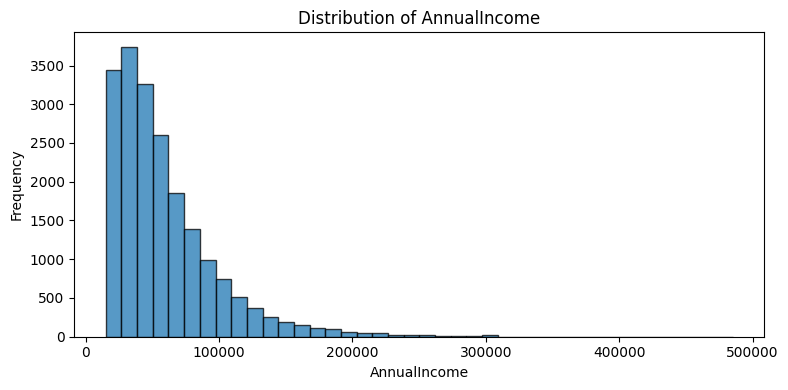

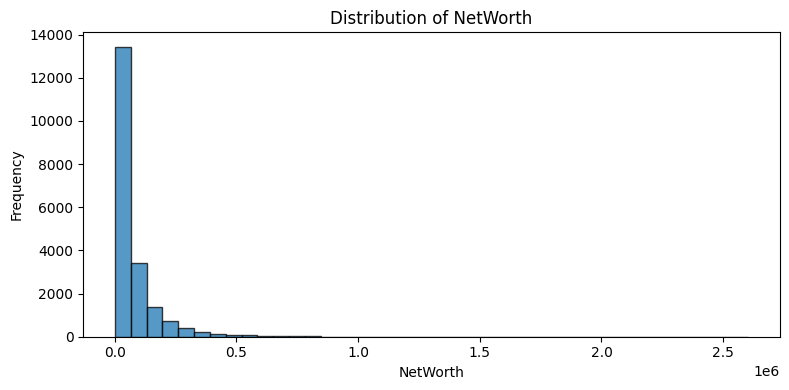

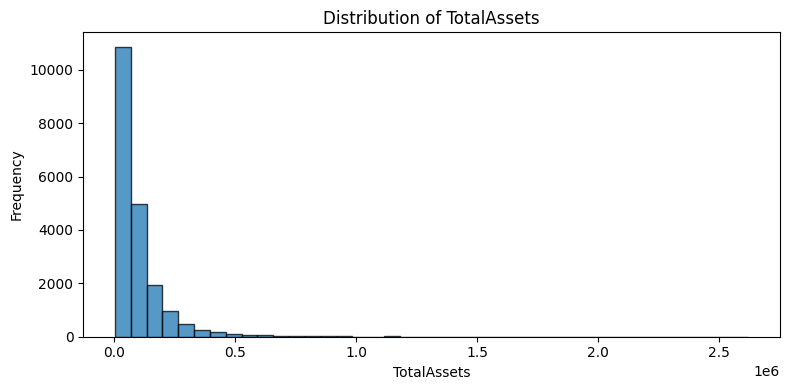

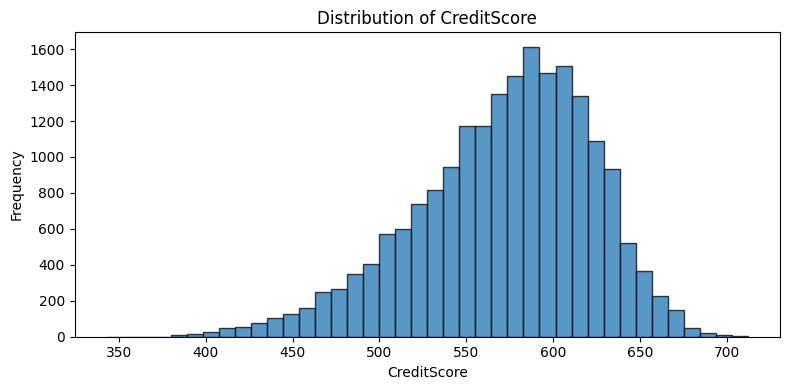

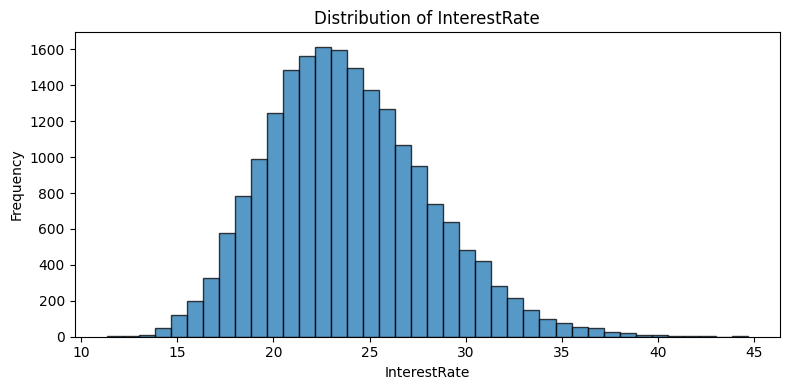

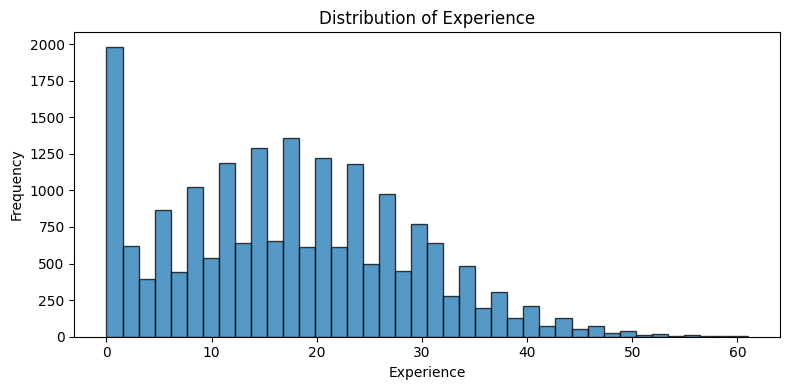

In [43]:
# Visualise distributions of selected numerical variables

import matplotlib.pyplot as plt

key_numerical_variables = [
    "AnnualIncome",
    "NetWorth",
    "TotalAssets",
    "CreditScore",
    "InterestRate",
    "Experience"
]

for variable in key_numerical_variables:
    plt.figure(figsize=(8, 4))

    plt.hist(
        loan_data[variable].dropna(),
        bins=40,
        edgecolor="black",
        alpha=0.75
    )

    plt.title(f"Distribution of {variable}")
    plt.xlabel(variable)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

#### Interpretation of Key Numerical Distributions

The visual assessment confirms substantial heterogeneity in the distributional characteristics of the selected numerical attributes. In particular, "AnnualIncome", "NetWorth" and "TotalAssets" exhibit pronounced positive skewness. Most applicants are concentrated within the lower-to-middle ranges of these variables, while progressively smaller numbers of observations extend into substantially higher values. This visual structure is consistent with the positive skewness identified during the preceding numerical audit and explains the considerable differences observed between their means and medians.

The distributions of "NetWorth" and "TotalAssets" display especially extended upper tails. Such observations may represent financially affluent applicants rather than erroneous records; consequently, their extremity alone does not provide sufficient justification for deletion. Nevertheless, these distributions may affect statistical summaries, visual scaling and the behaviour of modelling procedures that are sensitive to feature magnitude or extreme observations. Transformation or robust scaling may therefore warrant consideration during preprocessing.

"CreditScore" exhibits a markedly different structure. Values are concentrated primarily within the middle and upper portions of the observed range, with a longer extension towards lower credit scores. Compared with the financial variables, its distribution is substantially less affected by extreme upper-tail observations, suggesting that conventional measures of central tendency provide a more representative summary of this attribute.

"InterestRate" displays a unimodal distribution with moderate positive skewness. Most observations are concentrated around the lower-to-middle twenties, while progressively fewer applications occur at higher interest rates. This distribution appears considerably less extreme than those observed for income, wealth and asset measures.

Finally, "Experience" demonstrates a discrete and mildly right-skewed distribution, with applicant frequency generally declining at higher levels of experience. The visible irregularity in the histogram reflects the integer-valued nature of the variable rather than necessarily indicating data-quality problems.

Overall, the visual evidence reinforces the need for variable-specific preprocessing rather than applying a uniform transformation strategy across all numerical predictors. Strongly skewed financial attributes may require different treatment from comparatively well-behaved variables such as "CreditScore", while any transformation or outlier-handling decision should be justified using both distributional evidence and the substantive meaning of the variables.

### 2.16 Visual Assessment of Numerical Separation by Approval Outcome

The preceding analyses identified substantial differences in several numerical characteristics between approved and rejected applications. To evaluate whether these differences reflect broader distributional separation rather than isolated extreme observations, selected high-information variables are examined conditional on the loan-approval outcome. Particular attention is given to differences in central tendency, dispersion and distributional overlap between the two classes.

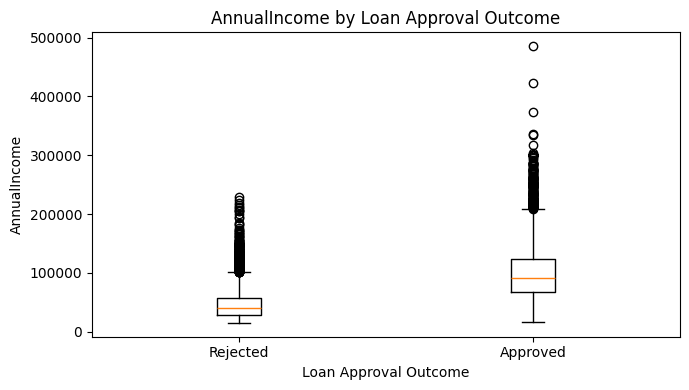

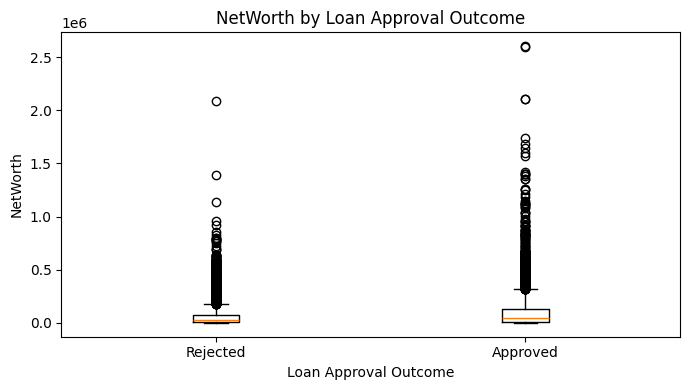

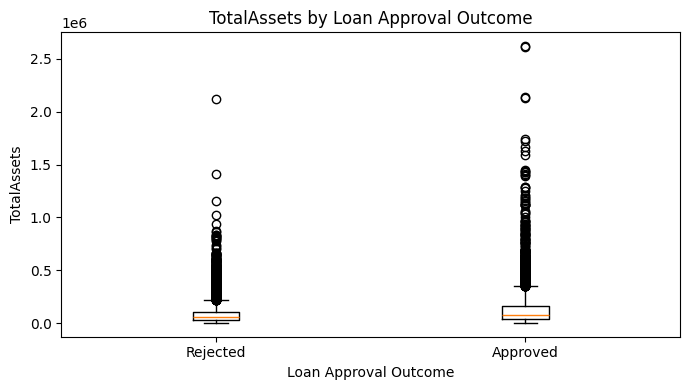

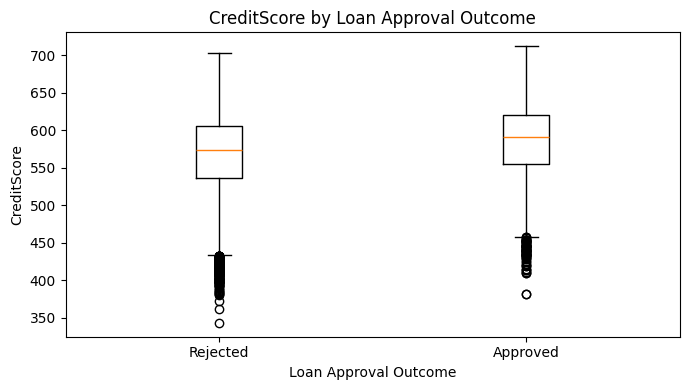

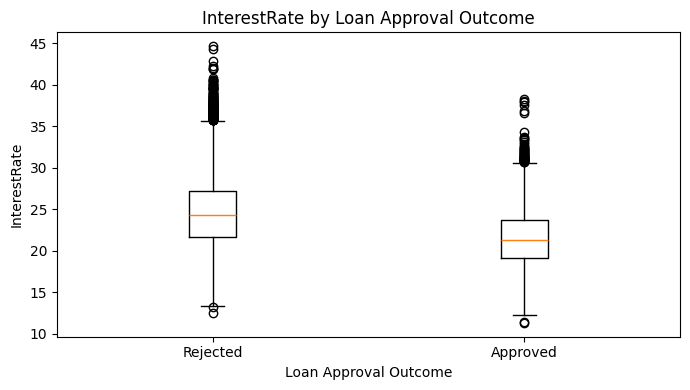

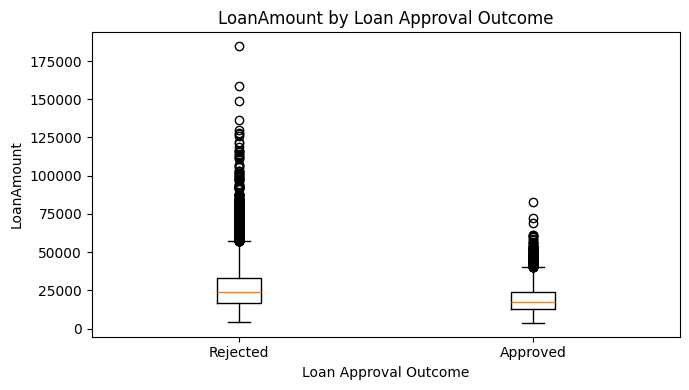

In [44]:
# Compare selected numerical variables across loan-approval outcomes

comparison_variables = [
    "AnnualIncome",
    "NetWorth",
    "TotalAssets",
    "CreditScore",
    "InterestRate",
    "LoanAmount"
]

for variable in comparison_variables:
    rejected = loan_data.loc[
        loan_data["LoanApproved"] == 0, variable
    ].dropna()

    approved = loan_data.loc[
        loan_data["LoanApproved"] == 1, variable
    ].dropna()

    plt.figure(figsize=(7, 4))

    plt.boxplot(
        [rejected, approved],
        tick_labels=["Rejected", "Approved"],
        showfliers=True
    )

    plt.title(f"{variable} by Loan Approval Outcome")
    plt.xlabel("Loan Approval Outcome")
    plt.ylabel(variable)

    plt.tight_layout()
    plt.show()

#### Interpretation of Numerical Separation by Approval Outcome

The class-conditional boxplots provide visual confirmation that several numerical attributes differ systematically between approved and rejected applications. Importantly, the observed differences are not restricted to group means; shifts in the medians and interquartile ranges indicate broader changes in the underlying distributions.

"AnnualIncome" demonstrates the clearest separation between the two outcome classes. Approved applicants exhibit a substantially higher median and interquartile range than rejected applicants, supporting the large difference previously identified in both mean and median income. Although both groups contain upper-tail observations, the displacement of the central distribution indicates that the association is not being generated solely by a small number of exceptionally high-income applicants.

"NetWorth" and "TotalAssets" also tend to be higher among approved applicants. Their interpretation is complicated by pronounced positive skewness and numerous observations beyond the conventional boxplot whiskers, which compress the central boxes visually. Nevertheless, the approved group exhibits an upward shift in its central distribution. These extreme observations should not automatically be regarded as erroneous, since the earlier distributional assessment established that heavy upper tails are structural characteristics of these financial variables.

A more moderate but clearly visible upward shift occurs for "CreditScore", with approved applicants displaying a higher median score. Considerable overlap remains between the two classes, indicating that credit score alone does not provide complete discrimination between approval outcomes.

Conversely, "InterestRate" demonstrates a downward shift among approved applications. Both its median and central range are lower than those observed for rejected applications. "LoanAmount" follows a similar pattern, with approved applicants generally requesting smaller loan amounts and exhibiting a lower central distribution than rejected applicants.

Taken together, the plots indicate that loan approval is associated with a combination of stronger financial capacity, more favourable credit characteristics and comparatively lower borrowing conditions. However, substantial overlap remains across all examined variables, suggesting that no individual numerical characteristic is sufficient to explain the approval outcome independently. This provides further motivation for subsequent multivariate analysis, where the joint contribution of applicant characteristics can be evaluated.

### 2.17 Correlation Structure Among Numerical Attributes

Following the univariate and outcome-based assessments, the next stage examines the dependency structure among numerical attributes. Pairwise correlation analysis is used to identify variables that exhibit substantial linear association, reveal potentially redundant information and provide an initial indication of multicollinearity within the predictor space.

This assessment is particularly relevant for the financial variables, such as "AnnualIncome", "NetWorth", "TotalAssets", "TotalLiabilities", "SavingsAccountBalance" and "CheckingAccountBalance", where related measures of financial capacity may contain overlapping information.

The analysis will distinguish relationships involving the target variable ("LoanApproved") from relationships occurring between predictors themselves. Correlation coefficients are interpreted as measures of linear association rather than evidence of causal relationships. Consequently, strong correlation will be treated as a diagnostic signal requiring further investigation rather than as an automatic criterion for feature removal.

In [45]:
# Construct a numerical dataset for correlation analysis
correlation_data = loan_data.select_dtypes(include="number").copy()

# Exclude the identifier-like date representation if present
correlation_columns = [
    column for column in correlation_data.columns
    if column != "LoanApproved"
]

# Compute predictor correlation matrix
predictor_correlation = (
    correlation_data[correlation_columns]
    .corr(method="pearson")
)

print("NUMERICAL CORRELATION ANALYSIS")
print("-" * 40)
print(f"Numerical predictors examined : {len(correlation_columns)}")
print(f"Correlation matrix dimensions : {predictor_correlation.shape}")

display(predictor_correlation.round(3))

NUMERICAL CORRELATION ANALYSIS
----------------------------------------
Numerical predictors examined : 22
Correlation matrix dimensions : (22, 22)


Variable,AnnualIncome,Experience,LoanDuration,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,BankruptcyHistory,PreviousLoanDefaults,LengthOfCreditHistory,CheckingAccountBalance,TotalLiabilities,NetWorth,Age,CreditScore,LoanAmount,CreditCardUtilizationRate,NumberOfCreditInquiries,PaymentHistory,SavingsAccountBalance,TotalAssets,JobTenure,InterestRate
Variable,,,,,,,,,,,,,,,,,,,,,,
AnnualIncome,1.000,0.146,0.003,-0.001,-0.001,-0.008,0.004,0.004,-0.005,0.009,-0.002,-0.004,0.145,0.104,-0.004,-0.003,-0.005,0.004,-0.001,-0.005,-0.001,-0.064
Experience,0.146,1.000,-0.008,0.000,0.019,-0.002,0.010,-0.002,-0.001,0.009,-0.000,0.015,0.983,0.328,-0.008,0.007,-0.003,-0.003,0.006,0.013,-0.001,-0.206
LoanDuration,0.003,-0.008,1.000,-0.001,0.000,0.001,-0.000,0.016,0.014,-0.003,0.004,-0.009,-0.007,-0.001,-0.000,0.003,0.001,0.002,0.002,-0.008,0.004,0.488
NumberOfDependents,-0.001,0.000,-0.001,1.000,-0.002,0.006,-0.001,0.006,0.003,0.002,0.010,-0.008,-0.000,-0.014,-0.007,0.000,-0.004,0.001,-0.002,-0.006,0.011,0.007
MonthlyDebtPayments,-0.001,0.019,0.000,-0.002,1.000,0.006,-0.007,0.003,-0.004,0.002,-0.004,0.004,0.016,0.011,0.021,-0.001,0.010,-0.003,-0.004,0.003,0.006,0.004
NumberOfOpenCreditLines,-0.008,-0.002,0.001,0.006,0.006,1.000,-0.002,0.013,0.004,-0.005,-0.008,-0.002,-0.001,-0.009,0.001,0.005,0.000,0.002,0.009,-0.004,0.007,0.008
BankruptcyHistory,0.004,0.010,-0.000,-0.001,-0.007,-0.002,1.000,-0.004,0.010,-0.005,-0.001,-0.001,0.011,0.009,0.005,0.001,-0.006,0.007,0.007,-0.001,0.004,0.003
PreviousLoanDefaults,0.004,-0.002,0.016,0.006,0.003,0.013,-0.004,1.000,0.006,0.006,-0.004,0.009,-0.004,-0.008,-0.002,0.002,-0.006,0.002,0.003,0.007,0.004,0.008
LengthOfCreditHistory,-0.005,-0.001,0.014,0.003,-0.004,0.004,0.010,0.006,1.000,-0.003,0.000,0.004,-0.000,0.005,0.001,0.002,-0.003,0.001,-0.011,0.005,0.015,0.005


### 2.18 Identification of Strong Predictor Correlations

The complete correlation matrix provides an initial representation of linear dependence among the numerical predictors; however, interpretation of the full matrix is difficult because of its dimensionality and duplicated pairwise coefficients. A targeted correlation audit is therefore performed to isolate the strongest predictor relationships.

Absolute Pearson correlation is used for ranking so that both strong positive and strong negative relationships are captured. The diagonal and duplicated lower-triangular entries are excluded. Particular attention is given to very strong relationships because these may indicate overlapping information and potential multicollinearity, which can affect coefficient stability in subsequent statistical and machine-learning models.

The purpose of this stage is diagnostic rather than corrective. Highly correlated variables will not be removed automatically; their analytical meaning, relationship with the target and implications for the selected modelling approach will be considered during preprocessing and feature selection.

In [46]:
# Extract unique pairwise correlations from the upper triangle
upper_triangle = np.triu(
    np.ones(predictor_correlation.shape, dtype=bool),
    k=1
)

correlation_pairs = (
    predictor_correlation
    .where(upper_triangle)
    .stack()
    .rename("Correlation")
    .rename_axis(["Variable_1", "Variable_2"])
    .reset_index()
)

# Calculate absolute correlation magnitude for ranking
correlation_pairs["Absolute_Correlation"] = (
    correlation_pairs["Correlation"].abs()
)

# Rank predictor relationships from strongest to weakest
strongest_correlations = (
    correlation_pairs
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

print("STRONGEST NUMERICAL PREDICTOR CORRELATIONS")
print("-" * 50)

display(strongest_correlations.head(15).round(3))

STRONGEST NUMERICAL PREDICTOR CORRELATIONS
--------------------------------------------------


,Variable_1,Variable_2,Correlation,Absolute_Correlation
0,Experience,Age,0.983,0.983
1,NetWorth,TotalAssets,0.979,0.979
2,CreditScore,InterestRate,-0.599,0.599
3,LoanDuration,InterestRate,0.488,0.488
4,Experience,CreditScore,0.328,0.328
5,Age,CreditScore,0.323,0.323
6,LoanAmount,InterestRate,0.323,0.323
7,Experience,InterestRate,-0.206,0.206
8,Age,InterestRate,-0.203,0.203
9,AnnualIncome,Experience,0.146,0.146


#### Interpretation

The pairwise correlation audit identifies two exceptionally strong positive relationships: "Age" with "Experience" (*r* = 0.983) and "NetWorth" with "TotalAssets" (*r* = 0.979). These coefficients indicate substantial linear redundancy and suggest that retaining both variables in each pair may introduce multicollinearity in models that are sensitive to correlated predictors.

A moderately strong negative association is observed between "CreditScore" and "InterestRate" (*r* = -0.599), indicating that applicants with higher credit scores tend to be associated with lower interest rates. "LoanDuration" and "InterestRate" also demonstrate a moderate positive association (*r* = 0.488). Other pairwise relationships are substantially weaker, suggesting that severe predictor correlation is concentrated within a small number of specific variable combinations rather than being pervasive throughout the dataset.

These findings do not justify immediate feature removal. Instead, the highly correlated pairs should be retained for subsequent multicollinearity diagnostics and considered alongside domain interpretation, target association and the requirements of the eventual modelling algorithms.

### 2.19 Numerical Association with the Loan-Approval Target

Having examined correlation among the predictors, the analysis now considers the marginal linear association between each numerical attribute and the binary target variable, "LoanApproved". Because the target is coded as 0 and 1, Pearson correlation with a continuous predictor is equivalent to the point-biserial correlation and therefore provides a useful initial measure of numerical separation between approved and rejected applications.

The analysis is exploratory rather than inferential. Correlation magnitude is used to rank potential predictive relationships, while recognising that weak marginal correlation does not imply an absence of predictive value because nonlinear effects and interactions may still contribute to subsequent models.

In [47]:
# Measure numerical association with the binary loan-approval target
target_correlations = (
    loan_data
    .select_dtypes(include="number")
    .corr(method="pearson")["LoanApproved"]
    .drop("LoanApproved")
    .dropna()
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .to_frame(name="Correlation_with_LoanApproved")
)

target_correlations["Absolute_Correlation"] = (
    target_correlations["Correlation_with_LoanApproved"].abs()
)

print("NUMERICAL ASSOCIATION WITH LOAN APPROVAL")
print("-" * 50)

display(target_correlations.round(3))

NUMERICAL ASSOCIATION WITH LOAN APPROVAL
--------------------------------------------------


,Correlation_with_LoanApproved,Absolute_Correlation
Variable,,
AnnualIncome,0.598,0.598
InterestRate,-0.302,0.302
LoanAmount,-0.239,0.239
NetWorth,0.188,0.188
TotalAssets,0.184,0.184
CreditScore,0.142,0.142
Age,0.141,0.141
Experience,0.141,0.141
LengthOfCreditHistory,0.106,0.106


#### Interpretation

The target-association analysis demonstrates that "AnnualIncome" has the strongest marginal numerical relationship with loan approval (*r* = 0.598), indicating substantially higher approval propensity among applicants with greater income. This finding is consistent with the pronounced income separation previously observed between approved and rejected applicants.

"InterestRate" exhibits the strongest negative association with the target (*r* = -0.302), while "LoanAmount" also shows a negative relationship (*r* = -0.239). These results indicate that approved applications tend to be associated with lower interest rates and, on average, lower requested loan amounts.

Positive but weaker associations are observed for "NetWorth" (*r* = 0.188), "TotalAssets" (*r* = 0.184), "CreditScore" (*r* = 0.142), "Age" (*r* = 0.141) and "Experience" (*r* = 0.141). The near-identical target correlations for "Age" and "Experience", considered alongside their extremely high inter-correlation (*r* = 0.983), provide further evidence that these variables contain substantial overlapping information. A similar issue exists for "NetWorth" and "TotalAssets", which have comparable target associations while being highly correlated with one another.

Several predictors demonstrate negligible marginal linear association with the target. This should not be interpreted as evidence of irrelevance, since Pearson correlation does not capture nonlinear relationships, threshold effects or multivariable interactions. Consequently, feature-retention decisions will be deferred until subsequent preprocessing, multicollinearity assessment and predictive modelling stages.

### 2.20 Multicollinearity Assessment Using Variance Inflation Factors

Pairwise correlation analysis identified exceptionally strong relationships between selected numerical predictors, particularly "Age" and "Experience", and between "NetWorth" and "TotalAssets". Pairwise coefficients, however, evaluate relationships between only two variables at a time and therefore cannot fully characterise multivariable redundancy.

Variance Inflation Factors (VIFs) are consequently examined to quantify the extent to which the variance of each numerical predictor can be explained by the remaining predictors. Higher VIF values indicate greater linear dependence within the predictor set and potential instability in coefficient-based models.

The diagnostic is used to identify multicollinearity rather than to perform automatic feature elimination. Any subsequent treatment will additionally consider domain meaning, target association and the characteristics of the modelling algorithms employed.

In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Prepare numerical predictors for multicollinearity assessment
vif_data = (
    loan_data
    .select_dtypes(include="number")
    .drop(columns=["LoanApproved"])
    .dropna()
    .astype(float)
)

# Add intercept for the auxiliary regressions used in VIF estimation
vif_matrix = add_constant(vif_data)

vif_results = pd.DataFrame({
    "Variable": vif_data.columns,
    "VIF": [
        variance_inflation_factor(vif_matrix.values, i)
        for i in range(1, vif_matrix.shape[1])
    ]
})

vif_results = (
    vif_results
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print("VARIANCE INFLATION FACTOR DIAGNOSTIC")
print("-" * 45)
print(f"Predictors assessed : {len(vif_data.columns)}")

display(vif_results.round(2))

VARIANCE INFLATION FACTOR DIAGNOSTIC
---------------------------------------------
Predictors assessed : 22


,Variable,VIF
0,NetWorth,40.47
1,TotalAssets,39.79
2,Experience,29.76
3,Age,29.65
4,InterestRate,3.30
5,CreditScore,2.29
6,LoanDuration,1.78
7,TotalLiabilities,1.68
8,LoanAmount,1.33
9,AnnualIncome,1.03


#### Interpretation

The variance inflation analysis confirms that multicollinearity is concentrated within two specific predictor pairs rather than being a general characteristic of the numerical feature space.

"NetWorth" (VIF = 40.47) and "TotalAssets" (VIF = 39.79) exhibit exceptionally high variance inflation, consistent with their previously observed pairwise correlation of *r* = 0.979. Similarly, "Experience" (VIF = 29.76) and "Age" (VIF = 29.65) demonstrate severe multicollinearity, supporting the very strong correlation identified between these variables (*r* = 0.983).

By comparison, the remaining predictors display substantially lower VIF values. "InterestRate" has the largest value outside these two pairs (VIF = 3.30), followed by "CreditScore" (VIF = 2.29) and "LoanDuration" (VIF = 1.78), while the majority of variables are close to 1. This indicates that problematic linear redundancy is highly localised.

The evidence therefore supports targeted treatment of the two highly redundant predictor pairs rather than broad feature elimination. However, variables will not be removed solely on the basis of VIF. Decisions will additionally consider target association, domain interpretation and the requirements of the subsequent modelling algorithms.

### 2.21 Task 2(a) — Fundamental Data Understanding: Analytical Summary

The exploratory assessment establishes a detailed understanding of the integrated loan-application dataset prior to preprocessing and predictive modelling. The dataset contains 20,000 observations and 31 attributes, with a mixture of numerical, categorical, temporal and identifier information.

Data completeness is generally high; however, two quality issues require explicit treatment. "MaritalStatus" contains 15 missing observations (0.08%), while "RiskScore" contains 1,275 non-numeric "XX" representations, corresponding to 6.38% of the dataset. Investigation of the latter revealed substantial outcome-dependent missingness: the affected representation occurs predominantly among rejected applications. Consequently, the missingness mechanism may contain predictive information and should not be treated as simple random noise during preprocessing.

The target variable is moderately imbalanced, with 76.1% of applications rejected and 23.9% approved. Exploratory target comparisons reveal substantial differences across several applicant characteristics. "AnnualIncome" demonstrates the strongest marginal numerical association with approval, while "InterestRate" and "LoanAmount" exhibit notable negative relationships. Education level also displays considerable variation in approval rates across categories.

Distributional analysis identifies pronounced positive skewness and extreme upper-tail observations in several financial variables, particularly "AnnualIncome", "NetWorth", "TotalAssets", account balances and credit-card utilisation. These observations should not automatically be classified as erroneous because they may represent legitimate financial heterogeneity. Their influence will therefore be evaluated during preprocessing rather than removed solely on the basis of statistical extremity.

Correlation and variance-inflation diagnostics additionally identify severe redundancy between "Age" and "Experience", and between "NetWorth" and "TotalAssets". In contrast, multicollinearity among the remaining numerical predictors is comparatively limited. These findings provide evidence for targeted feature treatment rather than indiscriminate dimensionality reduction.

Overall, the analysis indicates that the integrated dataset is structurally suitable for predictive modelling but requires deliberate preprocessing of missing and anomalous representations, categorical attributes, skewed numerical distributions, class imbalance and highly correlated predictors. These findings establish the empirical basis for the preprocessing strategy developed in the subsequent stage.

## Task 2(b) — Data Preprocessing

### 2.22 Preprocessing Strategy and Preservation of the Integrated Dataset

The exploratory analysis identified several characteristics requiring treatment before predictive modelling, including non-numeric representations within "RiskScore", limited missingness in "MaritalStatus", categorical predictors, highly correlated numerical attributes, strongly skewed financial distributions and moderate target-class imbalance.

Preprocessing will be performed systematically while preserving the original integrated analytical dataset. A separate working copy is created so that transformations remain traceable and the unmodified dataset can be retained for comparison and reproducibility.

Particular attention will be given to preventing data leakage. Transformations whose parameters depend on the observed data distribution will ultimately be estimated using training data rather than the complete dataset. Consequently, this stage distinguishes deterministic data-quality corrections from model-dependent preprocessing operations that must occur after the train-test partition.

In [49]:
# Preserve the integrated analytical dataset
loan_data_original = loan_data.copy(deep=True)

# Create a separate working dataset for preprocessing
loan_preprocessed = loan_data.copy(deep=True)

print("PREPROCESSING DATASET INITIALISATION")
print("-" * 45)
print(f"Original dataset shape   : {loan_data_original.shape}")
print(f"Working dataset shape    : {loan_preprocessed.shape}")
print(
    "Independent copy       :",
    loan_preprocessed is not loan_data_original
)

# Confirm that the working copy initially contains identical values
print(
    "Initial values equal   :",
    loan_preprocessed.equals(loan_data_original)
)


PREPROCESSING DATASET INITIALISATION
---------------------------------------------
Original dataset shape   : (20000, 31)
Working dataset shape    : (20000, 31)
Independent copy       : True
Initial values equal   : True


### 2.23 Preprocessing of "RiskScore" and Preservation of Missingness Information

The exploratory analysis established that "RiskScore" contains 1,275 "XX" representations rather than conventional null values. These observations cannot be interpreted as valid numerical risk scores and are therefore converted to missing numerical values before modelling.

Importantly, the earlier missingness analysis demonstrated that the occurrence of "XX" is strongly associated with the loan-approval outcome. Approximately 8.27% of rejected applications contain unavailable risk scores compared with only 0.33% of approved applications. Consequently, the absence of a valid risk score may itself contain predictive information.

Rather than deleting affected observations or immediately replacing missing values using statistics calculated from the complete dataset, a binary missingness indicator is introduced. This preserves information concerning whether the original risk score was available while allowing "RiskScore" itself to be represented numerically.

Numerical imputation is deliberately deferred until after the train-test partition. This prevents the imputation statistic from being estimated using information from the test set and therefore reduces the risk of data leakage.

In [50]:
# Preserve information about unavailable RiskScore values
loan_preprocessed["RiskScoreMissing"] = (
    pd.to_numeric(
        loan_preprocessed["RiskScore"],
        errors="coerce"
    )
    .isna()
    .astype(int)
)

# Convert valid RiskScore observations to numeric;
# original "XX" representations become NaN
loan_preprocessed["RiskScore"] = pd.to_numeric(
    loan_preprocessed["RiskScore"],
    errors="coerce"
)

print("RISK SCORE PREPROCESSING")
print("-" * 40)

print(
    f"Missing RiskScore values     : "
    f"{loan_preprocessed['RiskScore'].isna().sum():,}"
)

print(
    f"Missingness indicators = 1   : "
    f"{loan_preprocessed['RiskScoreMissing'].sum():,}"
)

print(
    f"RiskScore data type           : "
    f"{loan_preprocessed['RiskScore'].dtype}"
)

print(
    f"Dataset shape                 : "
    f"{loan_preprocessed.shape}"
)

# Validate that the indicator corresponds exactly to missing RiskScore values
risk_indicator_valid = (
    loan_preprocessed["RiskScore"].isna().astype(int)
    == loan_preprocessed["RiskScoreMissing"]
).all()

print(
    f"Indicator validation          : "
    f"{risk_indicator_valid}"
)

RISK SCORE PREPROCESSING
----------------------------------------


Missing RiskScore values     : 1,275
Missingness indicators = 1   : 1,275
RiskScore data type           : float64
Dataset shape                 : (20000, 32)
Indicator validation          : True


### 2.24 Preprocessing of Missing "MaritalStatus" Values

The completeness audit identified only 15 missing observations in "MaritalStatus", representing approximately 0.08% of the integrated dataset. Unlike "RiskScore", the missingness is extremely limited and does not justify removing complete applicant records.

As "MaritalStatus" is a nominal categorical attribute, the missing observations are assigned an explicit "Unknown" category. This approach preserves all observations, avoids imposing an unsupported marital-status classification, and allows subsequent categorical encoding to retain missingness as a distinct state.

An explicit category is preferred to mode substitution because replacing missing observations with the most frequent category would introduce artificial information by assuming that applicants with unavailable marital status belong to the dominant group.

In [51]:
# Preserve missing MaritalStatus as an explicit categorical state
marital_missing_before = (
    loan_preprocessed["MaritalStatus"].isna().sum()
)

loan_preprocessed["MaritalStatus"] = (
    loan_preprocessed["MaritalStatus"]
    .fillna("Unknown")
)

marital_missing_after = (
    loan_preprocessed["MaritalStatus"].isna().sum()
)

print("MARITAL STATUS PREPROCESSING")
print("-" * 40)

print(
    f"Missing before preprocessing : "
    f"{marital_missing_before:,}"
)

print(
    f"Missing after preprocessing  : "
    f"{marital_missing_after:,}"
)

print("\nCategory distribution:")
print(
    loan_preprocessed["MaritalStatus"]
    .value_counts(dropna=False)
)

print(
    f"\nDataset shape                : "
    f"{loan_preprocessed.shape}"
)

MARITAL STATUS PREPROCESSING
----------------------------------------
Missing before preprocessing : 15
Missing after preprocessing  : 0

Category distribution:
MaritalStatus
Married     10029
Single       6077
Divorced     2881
Widowed       998
Unknown        15
Name: count, dtype: int64

Dataset shape                : (20000, 32)


### 2.25 Definition of Predictor and Target Variables

Following the targeted preprocessing of identified data-quality issues, the analytical variables are separated according to their intended modelling roles. "LoanApproved" represents the binary response variable and is therefore isolated as the prediction target, while "ID" is excluded from the predictor matrix because it functions solely as an applicant identifier and carries no substantive predictive meaning.

All remaining attributes, including the engineered "RiskScoreMissing" indicator, are retained as candidate predictors at this stage. Feature transformations, encoding and model-dependent preprocessing will subsequently be estimated using training data only to minimise the risk of information leakage.

In [52]:
# Define target, identifier and candidate predictor variables
target_column = "LoanApproved"
identifier_column = "ID"

X = loan_preprocessed.drop(
    columns=[target_column, identifier_column]
).copy()

y = loan_preprocessed[target_column].copy()

print("PREDICTOR–TARGET DEFINITION")
print("-" * 45)

print(f"Predictor matrix shape : {X.shape}")
print(f"Target vector shape    : {y.shape}")
print(f"Identifier excluded    : {identifier_column not in X.columns}")
print(f"Target excluded from X : {target_column not in X.columns}")
print(f"Missing target values  : {y.isna().sum():,}")
print(f"Target classes         : {sorted(y.unique().tolist())}")

print("\nTarget distribution:")
print(y.value_counts().sort_index())

print("\nCandidate predictors:")
print(X.columns.tolist())

PREDICTOR–TARGET DEFINITION
---------------------------------------------
Predictor matrix shape : (20000, 30)
Target vector shape    : (20000,)
Identifier excluded    : True
Target excluded from X : True
Missing target values  : 0
Target classes         : [0, 1]

Target distribution:
LoanApproved
0    15220
1     4780
Name: count, dtype: int64

Candidate predictors:
['ApplicationDate', 'AnnualIncome', 'EmploymentStatus', 'Experience', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'BankruptcyHistory', 'PreviousLoanDefaults', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'Age', 'CreditScore', 'EducationLevel', 'LoanAmount', 'MaritalStatus', 'HomeOwnershipStatus', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'LoanPurpose', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore', 'RiskScoreMissing']


### 2.26 Stratified Training and Test Partition

The analytical dataset is partitioned into training and test subsets before any data-dependent feature transformation is estimated. An 80:20 hold-out design is adopted, providing a sufficiently large training sample while preserving an independent subset for subsequent evaluation of generalisation performance.

Because the loan-approval outcome is imbalanced, stratified sampling is applied using "LoanApproved". This preserves approximately the same class proportions in both partitions and prevents differences in outcome prevalence from confounding model evaluation. A fixed random state is specified to ensure computational reproducibility.

Importantly, the split is performed prior to imputation, encoding, scaling or other learned transformations. Subsequent preprocessing parameters will therefore be estimated from the training partition only, reducing the risk of information leakage from the held-out test data.

In [53]:
from sklearn.model_selection import train_test_split

# Create reproducible stratified training and test partitions
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("STRATIFIED TRAIN–TEST PARTITION")
print("-" * 45)

print(f"Training predictors : {X_train.shape}")
print(f"Test predictors     : {X_test.shape}")
print(f"Training target     : {y_train.shape}")
print(f"Test target         : {y_test.shape}")

# Compare target prevalence across partitions
class_balance = pd.DataFrame({
    "Full_Dataset": y.value_counts(normalize=True).sort_index(),
    "Training_Set": y_train.value_counts(normalize=True).sort_index(),
    "Test_Set": y_test.value_counts(normalize=True).sort_index()
}).mul(100).round(2)

class_balance.index = ["Rejected (0)", "Approved (1)"]

print("\nClass distribution (%)")
display(class_balance)

# Verify that the partitions are mutually exclusive
train_test_overlap = len(
    set(X_train.index).intersection(set(X_test.index))
)

print(f"\nTraining/test index overlap : {train_test_overlap}")
print(
    "All observations retained :",
    len(X_train) + len(X_test) == len(X)
)

STRATIFIED TRAIN–TEST PARTITION
---------------------------------------------
Training predictors : (16000, 30)
Test predictors     : (4000, 30)
Training target     : (16000,)
Test target         : (4000,)

Class distribution (%)


,Full_Dataset,Training_Set,Test_Set
Rejected (0),76.1,76.1,76.1
Approved (1),23.9,23.9,23.9



Training/test index overlap : 0
All observations retained : True


### 2.27 Predictor-Type Architecture for Model Preprocessing

Prior to constructing the modelling pipeline, candidate predictors are organised according to their analytical roles rather than relying exclusively on their current pandas data types. This distinction is important because numerical storage does not necessarily imply that a variable should be treated as continuous; binary indicators and discrete attributes may require different preprocessing decisions.

Predictors are therefore separated into continuous/numerical, categorical and binary groups. "ApplicationDate" is retained separately as a temporal attribute because its raw string representation is not directly suitable for most statistical learning algorithms and requires explicit feature engineering.

This schema provides an auditable preprocessing specification and will subsequently support controlled transformation through training-data-fitted pipelines.

In [54]:
# Define predictor groups according to analytical meaning

temporal_features = [
    "ApplicationDate"
]

categorical_features = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose"
]

binary_features = [
    "BankruptcyHistory",
    "PreviousLoanDefaults",
    "RiskScoreMissing"
]

numerical_features = [
    col for col in X_train.columns
    if col not in (
        temporal_features
        + categorical_features
        + binary_features
    )
]

# Validate predictor classification
classified_features = (
    temporal_features
    + categorical_features
    + binary_features
    + numerical_features
)

unclassified_features = sorted(
    set(X_train.columns) - set(classified_features)
)

duplicated_classifications = [
    feature
    for feature in set(classified_features)
    if classified_features.count(feature) > 1
]

print("PREDICTOR-TYPE ARCHITECTURE")
print("-" * 45)

print(f"Total predictors       : {X_train.shape[1]}")
print(f"Numerical features     : {len(numerical_features)}")
print(f"Categorical features   : {len(categorical_features)}")
print(f"Binary features        : {len(binary_features)}")
print(f"Temporal features      : {len(temporal_features)}")

print(f"\nUnclassified features  : {unclassified_features}")
print(f"Duplicate assignments  : {duplicated_classifications}")

print(
    "Complete classification:",
    set(classified_features) == set(X_train.columns)
    and len(classified_features) == len(X_train.columns)
)

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nBinary features:")
print(binary_features)

print("\nTemporal features:")
print(temporal_features)

PREDICTOR-TYPE ARCHITECTURE
---------------------------------------------
Total predictors       : 30
Numerical features     : 21
Categorical features   : 5
Binary features        : 3
Temporal features      : 1

Unclassified features  : []
Duplicate assignments  : []
Complete classification: True

Numerical features:
['AnnualIncome', 'Experience', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'NumberOfOpenCreditLines', 'LengthOfCreditHistory', 'CheckingAccountBalance', 'TotalLiabilities', 'NetWorth', 'Age', 'CreditScore', 'LoanAmount', 'CreditCardUtilizationRate', 'NumberOfCreditInquiries', 'PaymentHistory', 'SavingsAccountBalance', 'TotalAssets', 'JobTenure', 'InterestRate', 'RiskScore']

Categorical features:
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

Binary features:
['BankruptcyHistory', 'PreviousLoanDefaults', 'RiskScoreMissing']

Temporal features:
['ApplicationDate']


### 2.28 Temporal Feature Engineering for `ApplicationDate`

"ApplicationDate" represents temporal information that cannot be used directly by most statistical learning algorithms in its original string representation. The variable is therefore transformed into interpretable calendar-based components rather than being treated as a high-cardinality categorical predictor.

Year, month, day of month and day of week are extracted independently for the training and test partitions. The original date field is subsequently removed from the modelling matrices. This representation preserves potentially relevant temporal structure while avoiding one-hot encoding of thousands of individual dates.

The transformation is deterministic and does not estimate parameters from the data; consequently, applying the same transformation separately to the training and test partitions does not introduce information leakage.

In [55]:
# Create working copies before temporal feature engineering
X_train_model = X_train.copy()
X_test_model = X_test.copy()

# Convert ApplicationDate to datetime independently in each partition
train_dates = pd.to_datetime(
    X_train_model["ApplicationDate"],
    format="%d-%m-%Y",
    errors="coerce"
)

test_dates = pd.to_datetime(
    X_test_model["ApplicationDate"],
    format="%d-%m-%Y",
    errors="coerce"
)

# Extract interpretable calendar components
for dataset, dates in [
    (X_train_model, train_dates),
    (X_test_model, test_dates)
]:
    dataset["ApplicationYear"] = dates.dt.year
    dataset["ApplicationMonth"] = dates.dt.month
    dataset["ApplicationDay"] = dates.dt.day
    dataset["ApplicationDayOfWeek"] = dates.dt.dayofweek

    dataset.drop(columns="ApplicationDate", inplace=True)

# Validate temporal transformation
temporal_validation = pd.DataFrame({
    "Training": [
        train_dates.isna().sum(),
        X_train_model["ApplicationYear"].isna().sum(),
        X_train_model["ApplicationYear"].min(),
        X_train_model["ApplicationYear"].max()
    ],
    "Test": [
        test_dates.isna().sum(),
        X_test_model["ApplicationYear"].isna().sum(),
        X_test_model["ApplicationYear"].min(),
        X_test_model["ApplicationYear"].max()
    ]
}, index=[
    "Invalid source dates",
    "Missing engineered years",
    "Minimum year",
    "Maximum year"
])

print("TEMPORAL FEATURE ENGINEERING")
print("-" * 45)

print(f"Training shape before : {X_train.shape}")
print(f"Training shape after  : {X_train_model.shape}")
print(f"Test shape before     : {X_test.shape}")
print(f"Test shape after      : {X_test_model.shape}")

print(
    "Original date removed:",
    "ApplicationDate" not in X_train_model.columns
    and "ApplicationDate" not in X_test_model.columns
)

print("\nTemporal transformation validation:")
display(temporal_validation)

print("\nEngineered temporal features:")
display(
    X_train_model[
        [
            "ApplicationYear",
            "ApplicationMonth",
            "ApplicationDay",
            "ApplicationDayOfWeek"
        ]
    ].head()
)

TEMPORAL FEATURE ENGINEERING
---------------------------------------------
Training shape before : (16000, 30)
Training shape after  : (16000, 33)
Test shape before     : (4000, 30)
Test shape after      : (4000, 33)
Original date removed: True

Temporal transformation validation:


,Training,Test
Invalid source dates,0,0
Missing engineered years,0,0
Minimum year,2018,2018
Maximum year,2025,2025



Engineered temporal features:


Variable,ApplicationYear,ApplicationMonth,ApplicationDay,ApplicationDayOfWeek
15234,2019,9,17,1
15766,2021,3,2,1
16912,2024,4,21,6
12481,2020,3,4,2
1572,2022,4,22,4


### 2.29 Post-Engineering Feature Architecture Validation

Following temporal feature engineering, the modelling feature architecture is revised to reflect the removal of the original "ApplicationDate" attribute and the introduction of four derived calendar components. These engineered variables are represented numerically and are therefore incorporated into the numerical predictor group for subsequent preprocessing.

A structural validation is performed to ensure that every predictor in the transformed training and test matrices is assigned exactly once to an analytical feature group. This provides an explicit safeguard against accidental feature omission or duplicated transformation before construction of the preprocessing pipeline.

In [56]:
# Define engineered temporal variables
engineered_temporal_features = [
    "ApplicationYear",
    "ApplicationMonth",
    "ApplicationDay",
    "ApplicationDayOfWeek"
]

# Update numerical feature specification
numerical_features_model = [
    feature
    for feature in numerical_features
    if feature != "ApplicationDate"
] + engineered_temporal_features

# Complete post-engineering feature architecture
model_feature_groups = (
    numerical_features_model
    + categorical_features
    + binary_features
)

# Structural checks
unclassified_model_features = sorted(
    set(X_train_model.columns) - set(model_feature_groups)
)

unexpected_model_features = sorted(
    set(model_feature_groups) - set(X_train_model.columns)
)

duplicate_model_assignments = sorted({
    feature
    for feature in model_feature_groups
    if model_feature_groups.count(feature) > 1
})

train_test_schema_match = (
    list(X_train_model.columns) == list(X_test_model.columns)
)

complete_model_classification = (
    set(model_feature_groups) == set(X_train_model.columns)
    and len(model_feature_groups) == len(X_train_model.columns)
)

print("POST-ENGINEERING FEATURE ARCHITECTURE")
print("-" * 50)

print(f"Modelling predictors       : {X_train_model.shape[1]}")
print(f"Numerical features         : {len(numerical_features_model)}")
print(f"Categorical features       : {len(categorical_features)}")
print(f"Binary features            : {len(binary_features)}")

print(f"\nUnclassified features      : {unclassified_model_features}")
print(f"Unexpected features        : {unexpected_model_features}")
print(f"Duplicate assignments      : {duplicate_model_assignments}")
print(f"Train/test schema match    : {train_test_schema_match}")
print(f"Complete classification   : {complete_model_classification}")

print("\nEngineered temporal features:")
print(engineered_temporal_features)

POST-ENGINEERING FEATURE ARCHITECTURE
--------------------------------------------------
Modelling predictors       : 33
Numerical features         : 25
Categorical features       : 5
Binary features            : 3

Unclassified features      : []
Unexpected features        : []
Duplicate assignments      : []
Train/test schema match    : True
Complete classification   : True

Engineered temporal features:
['ApplicationYear', 'ApplicationMonth', 'ApplicationDay', 'ApplicationDayOfWeek']


### 2.30 Leakage-Safe Preprocessing Pipeline

A unified preprocessing architecture is constructed using scikit-learn's "Pipeline" and "ColumnTransformer" abstractions. This ensures that all data-dependent transformations are estimated exclusively from the training partition and can subsequently be applied unchanged to unseen observations.

Numerical predictors are median-imputed where necessary and standardised using "StandardScaler". Median imputation provides a robust treatment for the unresolved numerical missingness in "RiskScore", while the previously engineered "RiskScoreMissing" indicator preserves information concerning whether the original score was unavailable.

Categorical predictors are imputed using the most frequent training-set category as a defensive safeguard and transformed using one-hot encoding. Unknown categories are ignored during transformation so that previously unseen levels in future observations do not cause pipeline failure. Binary indicators are passed through without scaling because they already possess a meaningful 0/1 representation.

This pipeline design establishes a reproducible and leakage-resistant transformation framework suitable for subsequent statistical and machine-learning models.

In [57]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing:
# median imputation followed by standardisation
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing:
# defensive imputation followed by one-hot encoding
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop=None
            )
        )
    ]
)

# Combine feature-specific transformations
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features_model
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ],
    remainder="drop"
)

print("PREPROCESSING PIPELINE CONFIGURATION")
print("-" * 50)

print(f"Numerical inputs   : {len(numerical_features_model)}")
print(f"Categorical inputs : {len(categorical_features)}")
print(f"Binary inputs      : {len(binary_features)}")

print("\nNumerical operations:")
print("Median imputation -> StandardScaler")

print("\nCategorical operations:")
print("Most-frequent imputation -> OneHotEncoder")

print("\nBinary operations:")
print("Passthrough")

print("\nPreprocessor successfully defined.")

PREPROCESSING PIPELINE CONFIGURATION
--------------------------------------------------
Numerical inputs   : 25
Categorical inputs : 5
Binary inputs      : 3

Numerical operations:
Median imputation -> StandardScaler

Categorical operations:
Most-frequent imputation -> OneHotEncoder

Binary operations:
Passthrough

Preprocessor successfully defined.


### 2.31 Fitting and Validation of the Preprocessing Pipeline

The preprocessing architecture is fitted exclusively to the training partition. Consequently, numerical imputation statistics, scaling parameters and categorical encoding structures are learned without reference to the held-out test observations. The fitted transformer is then applied to both partitions, ensuring that the test data undergo exactly the same transformations established from the training sample.

The resulting feature matrices are evaluated for dimensional consistency, residual missing values and non-finite numerical values. Feature names generated by the transformation pipeline are also recovered to maintain interpretability and support subsequent feature-level analysis.

This validation provides an explicit checkpoint confirming that the analytical data have been converted into a fully numerical, model-ready representation while preserving the separation between model development and independent evaluation data.

In [58]:
import numpy as np

# Fit preprocessing transformations exclusively on training data
X_train_processed = preprocessor.fit_transform(X_train_model)

# Apply the already-fitted transformations to held-out test data
X_test_processed = preprocessor.transform(X_test_model)

# Recover transformed feature names
processed_feature_names = preprocessor.get_feature_names_out()

print("PREPROCESSING PIPELINE VALIDATION")
print("-" * 50)

print(f"Training input shape     : {X_train_model.shape}")
print(f"Training processed shape : {X_train_processed.shape}")
print(f"Test input shape         : {X_test_model.shape}")
print(f"Test processed shape     : {X_test_processed.shape}")

print(
    f"\nTransformed features     : "
    f"{len(processed_feature_names)}"
)

print(
    "Train/test dimensions match:",
    X_train_processed.shape[1] == X_test_processed.shape[1]
)

# Convert to dense arrays only for validation when required
train_validation_array = (
    X_train_processed.toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed
)

test_validation_array = (
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
)

print(
    "Training missing values :",
    np.isnan(train_validation_array).sum()
)

print(
    "Test missing values     :",
    np.isnan(test_validation_array).sum()
)

print(
    "Training finite values  :",
    np.isfinite(train_validation_array).all()
)

print(
    "Test finite values      :",
    np.isfinite(test_validation_array).all()
)

print("\nFirst 20 transformed feature names:")
print(processed_feature_names[:20])

PREPROCESSING PIPELINE VALIDATION
--------------------------------------------------
Training input shape     : (16000, 33)
Training processed shape : (16000, 50)
Test input shape         : (4000, 33)
Test processed shape     : (4000, 50)

Transformed features     : 50
Train/test dimensions match: True
Training missing values : 0
Test missing values     : 0
Training finite values  : True
Test finite values      : True

First 20 transformed feature names:
['numerical__AnnualIncome' 'numerical__Experience'
 'numerical__LoanDuration' 'numerical__NumberOfDependents'
 'numerical__MonthlyDebtPayments' 'numerical__NumberOfOpenCreditLines'
 'numerical__LengthOfCreditHistory' 'numerical__CheckingAccountBalance'
 'numerical__TotalLiabilities' 'numerical__NetWorth' 'numerical__Age'
 'numerical__CreditScore' 'numerical__LoanAmount'
 'numerical__CreditCardUtilizationRate'
 'numerical__NumberOfCreditInquiries' 'numerical__PaymentHistory'
 'numerical__SavingsAccountBalance' 'numerical__TotalAssets'
 

### 2.32 Audit of Training-Derived Preprocessing Parameters

To verify the behaviour of the fitted preprocessing pipeline, selected parameters learned exclusively from the training partition are examined. Particular attention is given to "RiskScore", since this variable contained the principal numerical missingness identified during exploratory analysis.

The fitted median used for numerical imputation is extracted directly from the numerical preprocessing pipeline, together with the corresponding training-derived scaling parameters. The categorical encoder is also inspected to confirm the category structures learned from the training sample.

This audit improves methodological transparency by demonstrating that preprocessing decisions are not merely specified conceptually but are represented by reproducible parameters estimated from the training data.

In [59]:
# Extract fitted preprocessing components
fitted_numerical_pipeline = (
    preprocessor.named_transformers_["numerical"]
)

fitted_categorical_pipeline = (
    preprocessor.named_transformers_["categorical"]
)

# Retrieve training-derived numerical parameters
numerical_imputer = fitted_numerical_pipeline.named_steps["imputer"]
numerical_scaler = fitted_numerical_pipeline.named_steps["scaler"]

numerical_parameter_audit = pd.DataFrame({
    "Variable": numerical_features_model,
    "Imputation_Median": numerical_imputer.statistics_,
    "Training_Mean": numerical_scaler.mean_,
    "Training_Scale": numerical_scaler.scale_
})

# Focus explicitly on RiskScore
risk_score_parameters = numerical_parameter_audit[
    numerical_parameter_audit["Variable"] == "RiskScore"
]

print("TRAINING-DERIVED PREPROCESSING AUDIT")
print("-" * 50)

print("RiskScore preprocessing parameters:")
display(risk_score_parameters.round(3))

# Inspect categories learned by the fitted encoder
categorical_encoder = (
    fitted_categorical_pipeline.named_steps["encoder"]
)

categorical_category_audit = pd.DataFrame({
    "Variable": categorical_features,
    "Number_of_Categories": [
        len(categories)
        for categories in categorical_encoder.categories_
    ],
    "Categories": [
        ", ".join(map(str, categories))
        for categories in categorical_encoder.categories_
    ]
})

print("\nTraining-derived categorical encoding structure:")
display(categorical_category_audit)

# Final transformed-space integrity check
print(
    "\nFeature-name count equals transformed width:",
    len(processed_feature_names) == X_train_processed.shape[1]
)

TRAINING-DERIVED PREPROCESSING AUDIT
--------------------------------------------------
RiskScore preprocessing parameters:


,Variable,Imputation_Median,Training_Mean,Training_Scale
20,RiskScore,51.0,50.585,7.902



Training-derived categorical encoding structure:


,Variable,Number_of_Categories,Categories
0,EmploymentStatus,3,"Employed, Self-Employed, Unemployed"
1,EducationLevel,5,"Associate, Bachelor, Doctorate, High School, M..."
2,MaritalStatus,5,"Divorced, Married, Single, Unknown, Widowed"
3,HomeOwnershipStatus,4,"Mortgage, Other, Own, Rent"
4,LoanPurpose,5,"Auto, Debt Consolidation, Education, Home, Other"



Feature-name count equals transformed width: True


### 2.33 Preprocessing Stage Summary

The preprocessing stage produced a complete and leakage-controlled analytical representation suitable for predictive modelling. Following exploratory data-quality assessment, the non-numeric "RiskScore" representation was converted to missing information and retained through a dedicated "RiskScoreMissing" indicator, while the small number of missing "MaritalStatus" observations was represented explicitly as "Unknown".

The data were subsequently divided using an 80:20 stratified train-test partition, preserving the original loan-approval distribution of 76.1% rejected and 23.9% approved applications. All data-dependent preprocessing operations were fitted exclusively on the 16,000-observation training partition, maintaining the independence of the 4,000-observation test set.

"ApplicationDate" was transformed into year, month, day and day-of-week components, providing interpretable temporal information without retaining the high-cardinality raw date representation. The resulting feature architecture contained 33 pre-transformation predictors comprising numerical, categorical and binary attributes.

Numerical predictors were processed using median imputation and standardisation. In particular, the training-derived median used to impute missing "RiskScore" values was 51.0. Categorical attributes were transformed through one-hot encoding using category structures learned exclusively from the training sample, while binary indicators were retained directly.

The final preprocessing transformation expanded the predictor space from 33 analytical variables to 50 model-ready features. Both training and test matrices contain no missing or non-finite values, possess identical feature dimensionality, and retain all observations assigned during the stratified partition.

Overall, the preprocessing workflow establishes a reproducible and leakage-resistant modelling foundation while preserving information associated with identified data-quality conditions. Subsequent predictive modelling can therefore be conducted using the fitted preprocessing architecture without requiring further modification of the held-out test data.

# Task 2(b) — Data Preprocessing

## 2.34 Preprocessing Objectives and Analytical Strategy

This stage extends the fundamental data-understanding analysis into a systematic preprocessing workflow designed to produce analytically meaningful and model-ready variables. Particular attention is given to data-quality conditions identified during exploratory analysis, including missing information, duplicate observations, implausible or extreme numerical values, feature representation and potential redundancy.

In accordance with the assessment requirements, additional financial attributes are engineered to represent monthly income, monthly loan repayment burden and total debt-to-income exposure. Outlying observations are investigated using both statistical and domain-informed criteria rather than being removed automatically, since extreme financial values may represent legitimate high-value applicants rather than data-entry errors.

Where preprocessing operations require parameters to be estimated from observed data, transformations are designed to preserve the training/test separation established previously, thereby reducing information leakage and supporting reproducible downstream modelling.

## 2.35 Duplicate and Structural Integrity Audit

Prior to further feature engineering, the preprocessed analytical dataset is reassessed for duplicate observations and structural inconsistencies. Although primary-key integrity was established during dataset integration, duplicate identifiers and complete duplicate records represent distinct data-quality conditions and are therefore evaluated separately.

The audit additionally verifies that the applicant identifier remains unique, that no observations have been lost during preprocessing, and that the previously established training and test partitions remain mutually exclusive. Duplicate records are not removed automatically; removal would only be justified where observations can be demonstrated to represent redundant records rather than legitimate applicants with similar characteristics.


In [60]:
# Duplicate and structural integrity audit

duplicate_ids = loan_preprocessed["ID"].duplicated().sum()
duplicate_rows = loan_preprocessed.duplicated().sum()

unique_ids = loan_preprocessed["ID"].nunique()
total_records = len(loan_preprocessed)

# Duplicate predictor profiles excluding the unique applicant ID
duplicate_profiles = (
    loan_preprocessed
    .drop(columns=["ID"])
    .duplicated()
    .sum()
)

# Reconfirm train/test partition integrity
partition_overlap = len(
    set(X_train.index).intersection(set(X_test.index))
)

partition_records = len(X_train) + len(X_test)

print("DUPLICATE AND STRUCTURAL INTEGRITY AUDIT")
print("-" * 55)

print(f"Total records                    : {total_records:,}")
print(f"Unique applicant IDs             : {unique_ids:,}")
print(f"Duplicate applicant IDs          : {duplicate_ids:,}")
print(f"Complete duplicate rows          : {duplicate_rows:,}")
print(f"Duplicate non-ID profiles        : {duplicate_profiles:,}")

print(f"\nTraining observations            : {len(X_train):,}")
print(f"Test observations                : {len(X_test):,}")
print(f"Combined partition observations  : {partition_records:,}")
print(f"Training/test index overlap      : {partition_overlap:,}")

print(
    "\nPrimary-key integrity            :",
    unique_ids == total_records and duplicate_ids == 0
)

print(
    "All observations retained       :",
    partition_records == total_records
)

print(
    "Partitions mutually exclusive   :",
    partition_overlap == 0
)


DUPLICATE AND STRUCTURAL INTEGRITY AUDIT
-------------------------------------------------------
Total records                    : 20,000
Unique applicant IDs             : 20,000
Duplicate applicant IDs          : 0
Complete duplicate rows          : 0
Duplicate non-ID profiles        : 0

Training observations            : 16,000
Test observations                : 4,000
Combined partition observations  : 20,000
Training/test index overlap      : 0

Primary-key integrity            : True
All observations retained       : True
Partitions mutually exclusive   : True


### Interpretation

The structural integrity audit confirms that preprocessing preserved all 20,000 applicant observations without introducing duplicate records or compromising identifier uniqueness. Each applicant ID remains unique, while both complete-row and non-ID profile duplicate counts are zero. The stratified training and test partitions contain 16,000 and 4,000 observations respectively, accounting for the complete dataset with no index overlap between partitions. These results provide evidence that subsequent preprocessing and modelling can proceed on structurally consistent and mutually exclusive data partitions.

### 2.36 Outlier Assessment and Treatment Strategy

Financial datasets commonly contain highly skewed variables and extreme observations that may represent genuine applicant characteristics rather than data-entry errors. Consequently, indiscriminate deletion of statistical outliers may remove informative observations and distort the underlying population.

This section systematically assesses potential outliers within continuous numerical predictors using training-derived interquartile-range (IQR) boundaries. The analysis distinguishes statistical extremeness from implausible values identified during the earlier domain-validity audit. To prevent information leakage, outlier thresholds are estimated exclusively from the training partition and subsequently applied to both training and test data.

Rather than automatically removing extreme observations, the assessment quantifies their prevalence and supports a variable-specific treatment strategy. Where appropriate, winsorisation may be used to limit the influence of extreme values while retaining applicant records and preserving the integrity of the train/test partition.

In [61]:
# ============================================================
# 2.36 Outlier Assessment and Treatment Strategy
# ============================================================

# Continuous numerical variables selected for outlier assessment
outlier_features = [
    "AnnualIncome",
    "Experience",
    "MonthlyDebtPayments",
    "CheckingAccountBalance",
    "TotalLiabilities",
    "NetWorth",
    "Age",
    "CreditScore",
    "LoanAmount",
    "CreditCardUtilizationRate",
    "SavingsAccountBalance",
    "TotalAssets",
    "InterestRate"
]

# Verify that all selected variables are available
missing_outlier_features = [
    col for col in outlier_features
    if col not in X_train_model.columns
]

assert len(missing_outlier_features) == 0, (
    f"Missing outlier-assessment variables: {missing_outlier_features}"
)

outlier_records = []
outlier_bounds = {}

for column in outlier_features:

    # Derive thresholds ONLY from training data
    q1 = X_train_model[column].quantile(0.25)
    q3 = X_train_model[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_bounds[column] = {
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound
    }

    train_mask = (
        (X_train_model[column] < lower_bound) |
        (X_train_model[column] > upper_bound)
    )

    test_mask = (
        (X_test_model[column] < lower_bound) |
        (X_test_model[column] > upper_bound)
    )

    outlier_records.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Training_Outliers": train_mask.sum(),
        "Training_Outlier_Percent": train_mask.mean() * 100,
        "Test_Outliers": test_mask.sum(),
        "Test_Outlier_Percent": test_mask.mean() * 100
    })

outlier_audit = (
    pd.DataFrame(outlier_records)
    .set_index("Variable")
    .sort_values(
        "Training_Outlier_Percent",
        ascending=False
    )
)

print("OUTLIER DIAGNOSTIC — TRAINING-DERIVED IQR THRESHOLDS")
print("-" * 60)

print(f"Variables assessed : {len(outlier_features)}")
print("Threshold source   : Training partition only")
print("IQR multiplier     : 1.5")

display(outlier_audit.round(2))

OUTLIER DIAGNOSTIC — TRAINING-DERIVED IQR THRESHOLDS
------------------------------------------------------------
Variables assessed : 13
Threshold source   : Training partition only
IQR multiplier     : 1.5


,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Training_Outliers,Training_Outlier_Percent,Test_Outliers,Test_Outlier_Percent
Variable,,,,,,,,,
SavingsAccountBalance,1540.00,5843.75,4303.75,-4915.62,12299.38,1280,8.00,328,8.20
NetWorth,8758.25,89572.25,80814.00,-112462.75,210793.25,1246,7.79,297,7.42
CheckingAccountBalance,552.00,2128.25,1576.25,-1812.38,4492.62,1213,7.58,307,7.68
TotalLiabilities,11224.75,43117.75,31893.00,-36614.75,90957.25,1204,7.52,333,8.33
TotalAssets,31127.75,118264.50,87136.75,-99577.38,248969.62,1163,7.27,258,6.45
CreditCardUtilizationRate,4.12,25.60,21.48,-28.10,57.82,878,5.49,230,5.75
AnnualIncome,31926.75,74543.25,42616.50,-31998.00,138468.00,768,4.80,178,4.45
MonthlyDebtPayments,287.00,565.00,278.00,-130.00,982.00,601,3.76,142,3.55
LoanAmount,15652.00,30837.25,15185.25,-7125.88,53615.12,591,3.69,165,4.12


#### Interpretation

The training-derived IQR diagnostic identifies substantial right-tail extremeness in several financial variables. The highest proportions of statistical outliers occur in "SavingsAccountBalance" (8.00%), "NetWorth" (7.79%), "CheckingAccountBalance" (7.58%), "TotalLiabilities" (7.52%), and "TotalAssets" (7.27%). "CreditCardUtilizationRate" also exhibits a notable outlier proportion of 5.49%, consistent with the strong positive skewness identified during the earlier distributional analysis.

In contrast, variables such as "Age", "Experience", "InterestRate", and "CreditScore" contain comparatively few IQR-defined outliers. The broadly similar outlier proportions observed in the independent test partition provide additional evidence that these distributional characteristics are not restricted to the training sample.

Crucially, an IQR-defined outlier is not necessarily an invalid observation. In financial data, exceptionally high income, assets, liabilities, account balances, or net worth may represent legitimate applicant heterogeneity. Therefore, wholesale row deletion would risk removing valid and potentially informative applicants. A conservative treatment strategy is consequently preferred: observations will be retained, while extreme continuous values may be bounded using thresholds estimated exclusively from the training partition where such treatment is justified. This preserves sample size, limits the influence of extreme tails, and maintains leakage-safe preprocessing.

### 2.37 Outlier Treatment and Robust Transformation Strategy

The preceding IQR assessment demonstrated that several financial variables contain substantial upper-tail extremeness. However, statistical outliers in financial data are not necessarily erroneous observations; unusually high income, assets, liabilities, balances, or utilisation may represent genuine applicant characteristics. Consequently, deleting complete applicant records solely because they exceed conventional IQR thresholds would result in unnecessary information loss.

A conservative winsorisation strategy is therefore applied to selected strongly right-skewed continuous financial variables. Treatment thresholds are estimated exclusively from the training partition to preserve the independence of the test data. Rather than using the relatively aggressive 1.5×IQR diagnostic boundaries as automatic replacement thresholds, the 1st and 99th training percentiles are used to limit only the most extreme distributional tails.

The same training-derived bounds are subsequently applied to the test partition. This approach retains every applicant, reduces excessive leverage from extreme numerical observations, preserves realistic distributional variation, and prevents test-set information from influencing preprocessing decisions.

In [62]:
# ============================================================
# 2.37 Outlier Treatment and Robust Transformation Strategy
# ============================================================

# Work on independent copies so the preceding datasets remain unchanged
X_train_treated = X_train_model.copy()
X_test_treated = X_test_model.copy()

# Selected variables exhibiting substantial right-skew / tail extremeness
winsor_features = [
    "AnnualIncome",
    "MonthlyDebtPayments",
    "CheckingAccountBalance",
    "TotalLiabilities",
    "NetWorth",
    "LoanAmount",
    "CreditCardUtilizationRate",
    "SavingsAccountBalance",
    "TotalAssets"
]

winsorisation_records = []

for column in winsor_features:

    # Estimate treatment boundaries exclusively from training data
    lower_bound = X_train_model[column].quantile(0.01)
    upper_bound = X_train_model[column].quantile(0.99)

    train_before = X_train_model[column].copy()
    test_before = X_test_model[column].copy()

    # Apply identical training-derived boundaries to both partitions
    X_train_treated[column] = train_before.clip(
        lower=lower_bound,
        upper=upper_bound
    )

    X_test_treated[column] = test_before.clip(
        lower=lower_bound,
        upper=upper_bound
    )

    winsorisation_records.append({
        "Variable": column,
        "Lower_1pct": lower_bound,
        "Upper_99pct": upper_bound,
        "Training_Values_Clipped":
            ((train_before < lower_bound) |
             (train_before > upper_bound)).sum(),
        "Test_Values_Clipped":
            ((test_before < lower_bound) |
             (test_before > upper_bound)).sum(),
        "Training_Max_Before": train_before.max(),
        "Training_Max_After": X_train_treated[column].max(),
        "Test_Max_Before": test_before.max(),
        "Test_Max_After": X_test_treated[column].max()
    })

winsorisation_audit = (
    pd.DataFrame(winsorisation_records)
    .set_index("Variable")
)

# Structural validation
train_rows_preserved = (
    X_train_treated.shape[0] == X_train_model.shape[0]
)

test_rows_preserved = (
    X_test_treated.shape[0] == X_test_model.shape[0]
)

train_indices_preserved = X_train_treated.index.equals(
    X_train_model.index
)

test_indices_preserved = X_test_treated.index.equals(
    X_test_model.index
)

print("OUTLIER TREATMENT — TRAINING-DERIVED WINSORISATION")
print("-" * 58)

print(f"Variables treated          : {len(winsor_features)}")
print("Lower treatment percentile : 1st")
print("Upper treatment percentile : 99th")
print("Threshold source           : Training partition only")
print("Applicant records removed  : 0")

print(f"\nTraining rows preserved    : {train_rows_preserved}")
print(f"Test rows preserved        : {test_rows_preserved}")
print(f"Training indices preserved : {train_indices_preserved}")
print(f"Test indices preserved     : {test_indices_preserved}")

display(winsorisation_audit.round(2))

OUTLIER TREATMENT — TRAINING-DERIVED WINSORISATION
----------------------------------------------------------
Variables treated          : 9
Lower treatment percentile : 1st
Upper treatment percentile : 99th
Threshold source           : Training partition only
Applicant records removed  : 0

Training rows preserved    : True
Test rows preserved        : True
Training indices preserved : True
Test indices preserved     : True


,Lower_1pct,Upper_99pct,Training_Values_Clipped,Test_Values_Clipped,Training_Max_Before,Training_Max_After,Test_Max_Before,Test_Max_After
Variable,,,,,,,,
AnnualIncome,15000.00,210302.11,160,44,485341.0,210302.11,300000.0,210302.11
MonthlyDebtPayments,124.00,1278.00,316,89,2919.0,1278.00,2501.0,1278.00
CheckingAccountBalance,105.00,11249.06,312,79,52572.0,11249.06,38024.0,11249.06
TotalLiabilities,2086.99,232754.45,320,73,1417302.0,232754.45,619124.0,232754.45
NetWorth,1315.99,537711.49,320,86,2603208.0,537711.49,2598936.0,537711.49
LoanAmount,6778.98,70241.01,320,77,184732.0,70241.01,129860.0,70241.01
CreditCardUtilizationRate,1.33,662.02,316,86,992.0,662.02,991.0,662.02
SavingsAccountBalance,280.00,31070.13,318,79,200089.0,31070.13,99503.0,31070.13
TotalAssets,7286.96,566815.62,320,98,2612797.0,566815.62,2619627.0,566815.62


#### Interpretation

The training-derived winsorisation procedure successfully constrained the extreme tails of nine selected continuous financial variables while retaining every applicant observation. All 16,000 training and 4,000 test records, together with their original indices, were preserved, confirming that the treatment modifies feature values rather than altering the analytical sample.

The effect is particularly substantial for highly right-skewed variables. For example, the maximum training values of "NetWorth" and "TotalAssets" were reduced from approximately 2.60 million and 2.61 million to training-derived 99th-percentile limits of approximately 537,711 and 566,816 respectively. Similar tail control was achieved for income, liabilities, balances, loan amounts, debt payments, and credit-card utilisation.

Importantly, treatment parameters were estimated exclusively from the training partition and then transferred unchanged to the test partition. The test data therefore contributed no information to the determination of clipping boundaries, maintaining the leakage-safe design established earlier. The strategy provides a compromise between robustness and information preservation: extreme leverage is reduced without indiscriminately deleting financially unusual but potentially legitimate applicants.

### 2.38 Final Model-Ready Preprocessing Integration and Validation

Following training-derived winsorisation, the preprocessing pipeline is refitted using the treated training partition and then applied unchanged to the treated test partition. This ensures that the final model-ready matrices incorporate the complete preprocessing sequence, including missing-value handling, temporal feature engineering, outlier treatment, categorical encoding, numerical imputation and feature scaling.

Refitting is necessary because the earlier transformed matrices were generated before winsorisation was introduced. Retaining those matrices would create a methodological inconsistency between the documented preprocessing strategy and the data actually supplied to the models.

The final transformed feature space is therefore revalidated for dimensional consistency, missing values and finite numerical representation. These matrices will form the definitive inputs for subsequent model development.

In [63]:
# Refit preprocessing pipeline using the treated TRAINING partition only
X_train_final = preprocessor.fit_transform(X_train_treated)

# Apply fitted preprocessing pipeline to treated TEST partition
X_test_final = preprocessor.transform(X_test_treated)

# Recover final transformed feature names
final_feature_names = preprocessor.get_feature_names_out()

# Convert to dense arrays only for validation if necessary
train_final_array = (
    X_train_final.toarray()
    if hasattr(X_train_final, "toarray")
    else X_train_final
)

test_final_array = (
    X_test_final.toarray()
    if hasattr(X_test_final, "toarray")
    else X_test_final
)

print("FINAL MODEL-READY PREPROCESSING VALIDATION")
print("-" * 55)

print(f"Training treated input shape : {X_train_treated.shape}")
print(f"Test treated input shape     : {X_test_treated.shape}")

print(f"\nFinal training shape         : {X_train_final.shape}")
print(f"Final test shape             : {X_test_final.shape}")

print(f"Final transformed features   : {len(final_feature_names)}")

print(
    "Train/test feature widths match:",
    X_train_final.shape[1] == X_test_final.shape[1]
)

print(
    "Feature-name count matches width:",
    len(final_feature_names) == X_train_final.shape[1]
)

print(
    "Training missing values:",
    np.isnan(train_final_array).sum()
)

print(
    "Test missing values:",
    np.isnan(test_final_array).sum()
)

print(
    "Training finite values:",
    np.isfinite(train_final_array).all()
)

print(
    "Test finite values:",
    np.isfinite(test_final_array).all()
)

print(
    "Training rows retained:",
    X_train_final.shape[0] == len(y_train)
)

print(
    "Test rows retained:",
    X_test_final.shape[0] == len(y_test)
)

print("\nFirst 20 final feature names:")
print(final_feature_names[:20])

FINAL MODEL-READY PREPROCESSING VALIDATION
-------------------------------------------------------
Training treated input shape : (16000, 33)
Test treated input shape     : (4000, 33)

Final training shape         : (16000, 50)
Final test shape             : (4000, 50)
Final transformed features   : 50
Train/test feature widths match: True
Feature-name count matches width: True
Training missing values: 0
Test missing values: 0
Training finite values: True
Test finite values: True
Training rows retained: True
Test rows retained: True

First 20 final feature names:
['numerical__AnnualIncome' 'numerical__Experience'
 'numerical__LoanDuration' 'numerical__NumberOfDependents'
 'numerical__MonthlyDebtPayments' 'numerical__NumberOfOpenCreditLines'
 'numerical__LengthOfCreditHistory' 'numerical__CheckingAccountBalance'
 'numerical__TotalLiabilities' 'numerical__NetWorth' 'numerical__Age'
 'numerical__CreditScore' 'numerical__LoanAmount'
 'numerical__CreditCardUtilizationRate'
 'numerical__Numb

#### Interpretation

The final preprocessing integration produced model-ready training and test matrices containing 16,000 and 4,000 observations respectively, with an identical transformed feature space of 50 predictors. All original partitioned observations were retained, confirming that the preprocessing workflow introduced no unintended record loss.

Both transformed matrices contain zero missing values and exclusively finite numerical values, while the number of recovered feature names exactly matches the transformed dimensionality. These checks confirm successful numerical imputation and scaling, categorical encoding, binary-feature preservation, temporal feature engineering, and the integration of training-derived outlier treatment.

Critically, all data-dependent preprocessing parameters were estimated from the training partition and subsequently applied to the test partition. The resulting "X_train_final" and "X_test_final" matrices therefore provide a consistent and leakage-controlled analytical foundation for subsequent statistical analysis and predictive modelling.

### 2.39  Financial Feature Engineering

In addition to the temporal features constructed previously, three financially interpretable predictors are engineered explicitly in accordance with the assignment requirements: "MonthlyIncome", "MonthlyLoanPayment", and "TotalDebtToIncomeRatio".

"MonthlyIncome" converts annual income to a monthly basis. "MonthlyLoanPayment" approximates the monthly repayment associated with the requested loan using the standard amortising-loan payment formula, incorporating loan principal, annual interest rate, and loan duration. Finally, "TotalDebtToIncomeRatio" expresses the combined existing monthly debt obligations and estimated monthly loan repayment as a percentage of monthly income.

To maintain the established leakage-safe workflow, these features are generated independently within the existing training and test partitions. No parameters are estimated from the test partition, and no target information is used in their construction.

In [64]:
# ============================================================
# 2.39 Assignment-Required Financial Feature Engineering
# ============================================================

# Preserve the existing treated datasets
X_train_financial = X_train_treated.copy()
X_test_financial = X_test_treated.copy()


def engineer_financial_features(data):
    """
    Construct assignment-required financial predictors.

    MonthlyIncome:
        AnnualIncome / 12

    MonthlyLoanPayment:
        Standard amortising-loan payment calculation using
        LoanAmount, annual InterestRate, and LoanDuration.

    TotalDebtToIncomeRatio:
        ((MonthlyLoanPayment + MonthlyDebtPayments)
         / MonthlyIncome) * 100
    """

    engineered = data.copy()

    # 1. Monthly income
    engineered["MonthlyIncome"] = (
        engineered["AnnualIncome"] / 12
    )

    # 2. Monthly loan payment
    monthly_rate = (
        engineered["InterestRate"] / 100 / 12
    )

    number_of_payments = engineered["LoanDuration"]

    # Standard amortising loan-payment formula
    engineered["MonthlyLoanPayment"] = np.where(
        monthly_rate > 0,
        (
            engineered["LoanAmount"]
            * monthly_rate
            * (1 + monthly_rate) ** number_of_payments
        )
        /
        (
            (1 + monthly_rate) ** number_of_payments - 1
        ),
        # Defensive case for a zero-interest loan
        engineered["LoanAmount"] / number_of_payments
    )

    # 3. Total debt-to-income ratio
    engineered["TotalDebtToIncomeRatio"] = (
        (
            engineered["MonthlyLoanPayment"]
            + engineered["MonthlyDebtPayments"]
        )
        / engineered["MonthlyIncome"]
    ) * 100

    return engineered


# Engineer features independently in each partition
X_train_financial = engineer_financial_features(
    X_train_financial
)

X_test_financial = engineer_financial_features(
    X_test_financial
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

required_financial_features = [
    "MonthlyIncome",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio"
]

financial_validation = pd.DataFrame({
    "Training_Missing": (
        X_train_financial[required_financial_features]
        .isna()
        .sum()
    ),
    "Test_Missing": (
        X_test_financial[required_financial_features]
        .isna()
        .sum()
    ),
    "Training_Min": (
        X_train_financial[required_financial_features]
        .min()
    ),
    "Training_Median": (
        X_train_financial[required_financial_features]
        .median()
    ),
    "Training_Max": (
        X_train_financial[required_financial_features]
        .max()
    )
})

print("ASSIGNMENT-REQUIRED FINANCIAL FEATURE ENGINEERING")
print("-" * 60)

print(
    f"Training shape before : {X_train_treated.shape}"
)
print(
    f"Training shape after  : {X_train_financial.shape}"
)

print(
    f"Test shape before     : {X_test_treated.shape}"
)
print(
    f"Test shape after      : {X_test_financial.shape}"
)

print(
    "\nRequired features created:",
    all(
        feature in X_train_financial.columns
        for feature in required_financial_features
    )
)

print(
    "Training rows preserved:",
    len(X_train_financial) == len(X_train_treated)
)

print(
    "Test rows preserved:",
    len(X_test_financial) == len(X_test_treated)
)

print(
    "Training engineered values finite:",
    np.isfinite(
        X_train_financial[
            required_financial_features
        ].to_numpy()
    ).all()
)

print(
    "Test engineered values finite:",
    np.isfinite(
        X_test_financial[
            required_financial_features
        ].to_numpy()
    ).all()
)

print("\nEngineered-feature validation:")
display(financial_validation.round(2))

print("\nSample engineered financial features:")
display(
    X_train_financial[
        [
            "AnnualIncome",
            "LoanAmount",
            "InterestRate",
            "LoanDuration",
            "MonthlyDebtPayments",
            "MonthlyIncome",
            "MonthlyLoanPayment",
            "TotalDebtToIncomeRatio"
        ]
    ].head().round(2)
)

ASSIGNMENT-REQUIRED FINANCIAL FEATURE ENGINEERING
------------------------------------------------------------
Training shape before : (16000, 33)
Training shape after  : (16000, 36)
Test shape before     : (4000, 33)
Test shape after      : (4000, 36)

Required features created: True
Training rows preserved: True
Test rows preserved: True
Training engineered values finite: True
Test engineered values finite: True

Engineered-feature validation:


,Training_Missing,Test_Missing,Training_Min,Training_Median,Training_Max
Variable,,,,,
MonthlyIncome,0,0,1250.00,4062.88,17525.18
MonthlyLoanPayment,0,0,140.73,730.82,6901.95
TotalDebtToIncomeRatio,0,0,1.92,29.99,464.76



Sample engineered financial features:


Variable,AnnualIncome,LoanAmount,InterestRate,LoanDuration,MonthlyDebtPayments,MonthlyIncome,MonthlyLoanPayment,TotalDebtToIncomeRatio
15234,34402.0,16368.0,25.81,36,210,2866.83,657.82,30.27
15766,51561.0,24926.0,25.79,84,628,4296.75,643.56,29.59
16912,119497.0,28380.0,32.09,96,296,9958.08,824.37,11.25
12481,28425.0,9736.0,23.63,72,289,2368.75,254.14,22.93
1572,55821.0,33557.0,24.20,48,438,4651.75,1097.73,33.01


#### Interpretation

The assignment-required financial feature-engineering stage successfully expanded the predictor space from 33 to 36 variables while preserving all 16,000 training and 4,000 test observations. "MonthlyIncome", "MonthlyLoanPayment", and "TotalDebtToIncomeRatio" were generated without introducing missing or non-finite values, confirming computational validity across both partitions.

"MonthlyIncome" translates annual earnings into a directly interpretable monthly measure, while "MonthlyLoanPayment" estimates the recurring repayment burden associated with the requested loan after accounting for principal, interest rate, and loan duration. "TotalDebtToIncomeRatio" subsequently combines the estimated loan repayment with existing monthly debt obligations relative to monthly income, providing a financially meaningful measure of repayment burden.

The training distribution of "TotalDebtToIncomeRatio" has a median of approximately 29.99%, although substantially higher values occur in the upper tail. Such observations identify applicants whose combined debt obligations are large relative to monthly income and may therefore contain useful discriminatory information for subsequent loan-approval modelling. All engineered features were constructed without reference to the target variable or test-derived parameters, preserving the leakage-controlled analytical design.

### 2.40 Final Preprocessing Refresh Following Financial Feature Engineering

Following the introduction of the assignment-required financial predictors, the final preprocessing architecture is updated so that "MonthlyIncome", "MonthlyLoanPayment", and "TotalDebtToIncomeRatio" are incorporated into the numerical feature set used for modelling.

Because these features were engineered after the earlier preprocessing pipeline had already been fitted, the transformation workflow must be refreshed to ensure methodological consistency. The preprocessing pipeline is therefore refitted exclusively on the training partition containing the newly engineered variables, and the fitted transformations are then applied unchanged to the test partition.

This final refresh ensures that the definitive model-ready matrices contain all approved engineered predictors while preserving the leakage-safe design established throughout the preprocessing stage.

In [65]:
financial_engineered_features = [
    "MonthlyIncome",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio"
]

numerical_features_final = (
    numerical_features_model
    + financial_engineered_features
)

# Validate that all final numerical features exist
missing_final_numeric_features = [
    feature
    for feature in numerical_features_final
    if feature not in X_train_financial.columns
]

assert len(missing_final_numeric_features) == 0, (
    f"Missing final numerical features: "
    f"{missing_final_numeric_features}"
)

# Rebuild final preprocessing architecture
final_numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

final_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            final_numerical_pipeline,
            numerical_features_final
        ),
        (
            "categorical",
            final_categorical_pipeline,
            categorical_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ],
    remainder="drop"
)

# Fit ONLY on training data
X_train_final = final_preprocessor.fit_transform(
    X_train_financial
)

# Transform test data using training-fitted parameters
X_test_final = final_preprocessor.transform(
    X_test_financial
)

# Recover final feature names
final_feature_names = (
    final_preprocessor.get_feature_names_out()
)

# Convert to dense arrays for integrity validation if required
train_final_array = (
    X_train_final.toarray()
    if hasattr(X_train_final, "toarray")
    else X_train_final
)

test_final_array = (
    X_test_final.toarray()
    if hasattr(X_test_final, "toarray")
    else X_test_final
)

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

print("FINAL PREPROCESSING REFRESH")
print("-" * 55)

print(
    f"Training input predictors   : "
    f"{X_train_financial.shape}"
)

print(
    f"Test input predictors       : "
    f"{X_test_financial.shape}"
)

print(
    f"\nNumerical features          : "
    f"{len(numerical_features_final)}"
)

print(
    f"Categorical features        : "
    f"{len(categorical_features)}"
)

print(
    f"Binary features             : "
    f"{len(binary_features)}"
)

print(
    f"\nFinal training matrix       : "
    f"{X_train_final.shape}"
)

print(
    f"Final test matrix           : "
    f"{X_test_final.shape}"
)

print(
    f"Final transformed features  : "
    f"{len(final_feature_names)}"
)

print(
    "\nTrain/test feature widths match:",
    X_train_final.shape[1]
    == X_test_final.shape[1]
)

print(
    "Feature-name count matches width:",
    len(final_feature_names)
    == X_train_final.shape[1]
)

print(
    "Training missing values:",
    np.isnan(train_final_array).sum()
)

print(
    "Test missing values:",
    np.isnan(test_final_array).sum()
)

print(
    "Training finite values:",
    np.isfinite(train_final_array).all()
)

print(
    "Test finite values:",
    np.isfinite(test_final_array).all()
)

print(
    "Training rows retained:",
    X_train_final.shape[0] == len(y_train)
)

print(
    "Test rows retained:",
    X_test_final.shape[0] == len(y_test)
)

print(
    "\nRequired engineered features included:",
    all(
        any(
            feature in transformed_name
            for transformed_name in final_feature_names
        )
        for feature in financial_engineered_features
    )
)

print("\nEngineered financial feature names:")
print([
    name
    for name in final_feature_names
    if any(
        feature in name
        for feature in financial_engineered_features
    )
])

FINAL PREPROCESSING REFRESH
-------------------------------------------------------
Training input predictors   : (16000, 36)
Test input predictors       : (4000, 36)

Numerical features          : 28
Categorical features        : 5
Binary features             : 3

Final training matrix       : (16000, 53)
Final test matrix           : (4000, 53)
Final transformed features  : 53

Train/test feature widths match: True
Feature-name count matches width: True
Training missing values: 0
Test missing values: 0
Training finite values: True
Test finite values: True
Training rows retained: True
Test rows retained: True

Required engineered features included: True

Engineered financial feature names:
['numerical__MonthlyIncome', 'numerical__MonthlyLoanPayment', 'numerical__TotalDebtToIncomeRatio']


### 2.41 Data Preprocessing Summary

The preprocessing stage transformed the exploratory dataset into a consistent and model-ready representation while preserving the original training and test observations. Duplicate and structural-integrity checks confirmed that all 20,000 applications were uniquely represented, with no duplicate applicant identifiers or duplicate non-identifier profiles identified.

Missing-data treatment was performed according to variable characteristics. The non-numeric "RiskScore" representation was converted to missing information and retained through the binary "RiskScoreMissing" indicator, while the small number of missing "MaritalStatus" observations were assigned an explicit "Unknown" category. The target variable remained unchanged throughout preprocessing.

A stratified 80:20 train-test partition produced 16,000 training observations and 4,000 test observations while preserving the original 76.1% rejected and 23.9% approved class distribution. All data-dependent preprocessing parameters were subsequently derived from the training partition to reduce information leakage.

"ApplicationDate" was decomposed into "ApplicationYear", "ApplicationMonth", "ApplicationDay", and "ApplicationDayOfWeek". In addition, the assignment-required financial variables "MonthlyIncome", "MonthlyLoanPayment", and "TotalDebtToIncomeRatio" were engineered from the available financial and loan information.

Outlier diagnostics identified substantial right-tail behaviour in several financial variables. Rather than deleting observations, selected continuous financial variables were winsorised using the 1st and 99th percentiles estimated exclusively from the training data, preserving all application records while limiting the influence of extreme values.

The final preprocessing pipeline applies median imputation and standardisation to numerical predictors, most-frequent imputation and one-hot encoding to categorical predictors, and passthrough treatment to binary predictors. The pipeline is fitted only to the training partition and subsequently applied unchanged to the test partition.

Following all preprocessing and feature-engineering operations, the final model-ready datasets contain 16,000 training observations and 4,000 test observations with 53 transformed predictors. Both matrices contain no missing or non-finite values, have identical feature structures, and retain all original partition observations. These validated matrices provide the definitive inputs for the subsequent statistical analysis and modelling stages.

## Task 2(c) — Statistics/Computation-Based Analysis and Visualisation

### 2.42 Analytical Framework for Statistical and Visual Investigation

This section extends the exploratory investigation through systematic statistical, computational, and visual analysis of the loan-application data. The objective is to examine individual variable behaviour, relationships between predictors, associations with the "LoanApproved" outcome, and broader multivariate structures that may influence subsequent modelling decisions.

The analysis is organised into four complementary components:

1. Univariate analysis— examination of numerical and categorical variables using descriptive statistics and appropriate distributional visualisations.
2. Bivariate analysis — investigation of relationships between individual predictors and the loan-approval outcome, together with selected relationships between important predictors.
3. Multivariate analysis — assessment of simultaneous relationships among numerical attributes using correlation-based and visual techniques.
4. Statistical and computational assessment — quantitative evaluation of important differences and associations identified during exploratory analysis.

Visual evidence is interpreted alongside numerical results rather than considered independently. Particular attention is given to distributional shape, class differences, association strength, potential redundancy among predictors, and patterns that may be relevant to the predictive modelling stage.

### 2.42 Univariate Statistical Analysis of Numerical Attributes

Univariate analysis is first conducted to characterise the central tendency, dispersion, distributional shape, and range of the numerical attributes. Descriptive measures including the mean, median, standard deviation, minimum, maximum, interquartile range, skewness, and kurtosis are evaluated to identify distributional asymmetry and variables exhibiting substantial variability.

This analysis complements the earlier preliminary distribution assessment and provides a quantitative foundation for selecting variables requiring closer visual and statistical investigation.

In [66]:
univariate_numeric_features = [
    "AnnualIncome",
    "Experience",
    "LoanDuration",
    "NumberOfDependents",
    "MonthlyDebtPayments",
    "NumberOfOpenCreditLines",
    "BankruptcyHistory",
    "PreviousLoanDefaults",
    "LengthOfCreditHistory",
    "CheckingAccountBalance",
    "TotalLiabilities",
    "NetWorth",
    "Age",
    "CreditScore",
    "LoanAmount",
    "CreditCardUtilizationRate",
    "NumberOfCreditInquiries",
    "PaymentHistory",
    "SavingsAccountBalance",
    "TotalAssets",
    "JobTenure",
    "InterestRate"
]

# Calculate descriptive statistics
univariate_summary = pd.DataFrame({
    "Mean": loan_data[univariate_numeric_features].mean(),
    "Median": loan_data[univariate_numeric_features].median(),
    "Std_Dev": loan_data[univariate_numeric_features].std(),
    "Minimum": loan_data[univariate_numeric_features].min(),
    "Q1": loan_data[univariate_numeric_features].quantile(0.25),
    "Q3": loan_data[univariate_numeric_features].quantile(0.75),
    "Maximum": loan_data[univariate_numeric_features].max(),
    "Skewness": loan_data[univariate_numeric_features].skew(),
    "Kurtosis": loan_data[univariate_numeric_features].kurt()
})

# Calculate interquartile range
univariate_summary["IQR"] = (
    univariate_summary["Q3"]
    - univariate_summary["Q1"]
)

# Reorder columns
univariate_summary = univariate_summary[
    [
        "Mean",
        "Median",
        "Std_Dev",
        "Minimum",
        "Q1",
        "Q3",
        "Maximum",
        "IQR",
        "Skewness",
        "Kurtosis"
    ]
]

print("UNIVARIATE NUMERICAL STATISTICAL SUMMARY")
print("-" * 50)

print(
    f"Numerical attributes analysed : "
    f"{len(univariate_numeric_features)}"
)

display(univariate_summary.round(2))


UNIVARIATE NUMERICAL STATISTICAL SUMMARY
--------------------------------------------------
Numerical attributes analysed : 22


,Mean,Median,Std_Dev,Minimum,Q1,Q3,Maximum,IQR,Skewness,Kurtosis
Variable,,,,,,,,,,
AnnualIncome,59161.47,48566.00,40350.85,15000.00,31679.00,74391.00,485341.00,42712.00,2.09,6.85
Experience,17.52,17.00,11.32,0.00,9.00,25.00,61.00,16.00,0.34,-0.37
LoanDuration,54.06,48.00,24.66,12.00,36.00,72.00,120.00,36.00,0.65,0.17
NumberOfDependents,1.52,1.00,1.39,0.00,0.00,2.00,5.00,2.00,0.64,-0.49
MonthlyDebtPayments,454.29,402.00,240.51,50.00,286.00,564.00,2919.00,278.00,1.65,4.92
NumberOfOpenCreditLines,3.02,3.00,1.74,0.00,2.00,4.00,13.00,2.00,0.60,0.37
BankruptcyHistory,0.05,0.00,0.22,0.00,0.00,0.00,1.00,0.00,4.02,14.14
PreviousLoanDefaults,0.10,0.00,0.30,0.00,0.00,0.00,1.00,0.00,2.67,5.11
LengthOfCreditHistory,14.96,15.00,8.37,1.00,8.00,22.00,29.00,14.00,0.00,-1.20


#### Interpretation

The univariate statistics reveal substantial heterogeneity in the distributional characteristics of the numerical attributes. Several financial variables exhibit pronounced positive skewness and heavy-tailed behaviour. "TotalAssets" (skewness = 5.31), "NetWorth" (5.60), "TotalLiabilities" (5.85), "SavingsAccountBalance" (6.06), "CreditCardUtilizationRate" (5.33), and "CheckingAccountBalance" (4.75) show particularly strong right-skewness. Their large positive kurtosis values further indicate substantial tail concentration and the presence of extreme observations. This supports the earlier outlier diagnostics and provides additional statistical justification for the robust outlier treatment adopted during preprocessing.

'AnnualIncome" and "LoanAmount" are also positively skewed, with skewness coefficients of 2.09 and 1.83 respectively. In both cases, the mean exceeds the median, which is consistent with relatively small numbers of high-valued observations extending the upper tail of the distributions. "MonthlyDebtPayments" demonstrates similar, although less extreme, positive asymmetry.

In contrast, "CreditScore" exhibits moderate negative skewness (-0.60), while "Age", "PaymentHistory", "JobTenure", and "InterestRate" are comparatively closer to symmetric distributions. "LengthOfCreditHistory" is particularly symmetric, with a skewness coefficient approximately equal to zero.

The binary variables "BankruptcyHistory" and "PreviousLoanDefaults" display high positive skewness because positive events are comparatively uncommon. Their distributional statistics should therefore be interpreted as characteristics of binary indicators rather than as evidence of conventional continuous-variable outliers.

Overall, the results demonstrate that the numerical predictor space contains a mixture of approximately symmetric, moderately asymmetric, discrete, binary, and strongly heavy-tailed financial attributes. Consequently, reliance on means and standard deviations alone would provide an incomplete description of the data; medians, interquartile ranges, robust preprocessing, and distribution-sensitive visualisation are also important for subsequent analysis.

### 2.43 Univariate Visual Analysis of Selected Numerical Attributes

The statistical evidence from Section 2.42 indicates substantial differences in distributional shape across the numerical attributes. Selected variables are therefore visualised to contrast strongly right-skewed financial measures with variables exhibiting comparatively moderate or near-symmetric distributions.

The selected attributes represent different analytical characteristics: "TotalAssets" and "CreditCardUtilizationRate" exhibit strong positive skewness and heavy tails, "LoanAmount" demonstrates moderate positive skewness, while "CreditScore" provides a comparatively less skewed distribution. These visualisations complement the numerical measures of skewness and kurtosis and support the assessment of distributional behaviour.

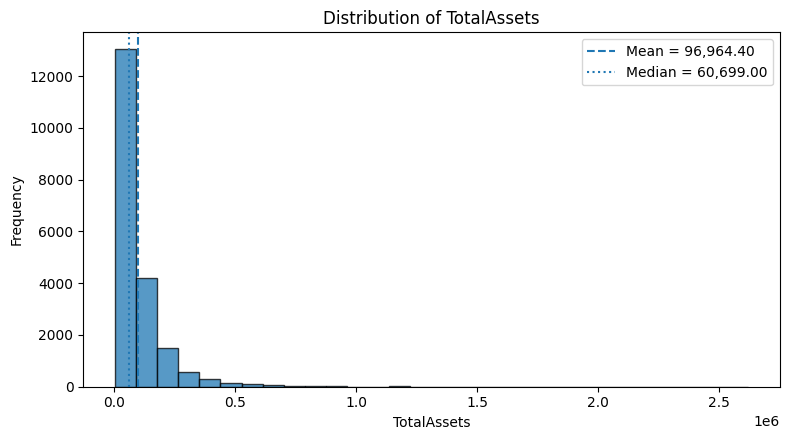

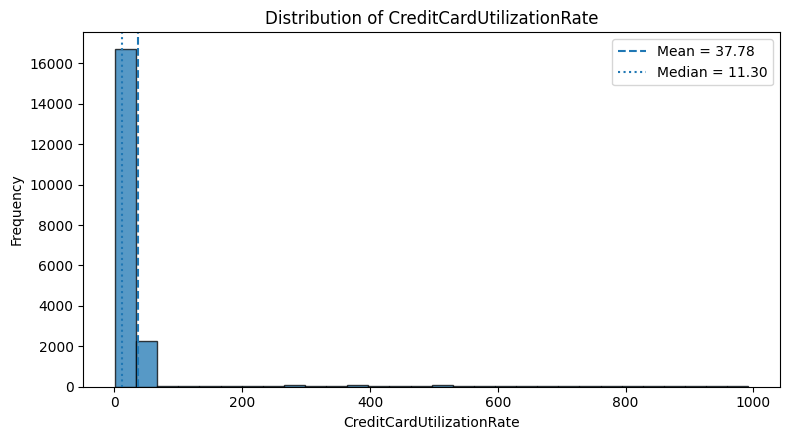

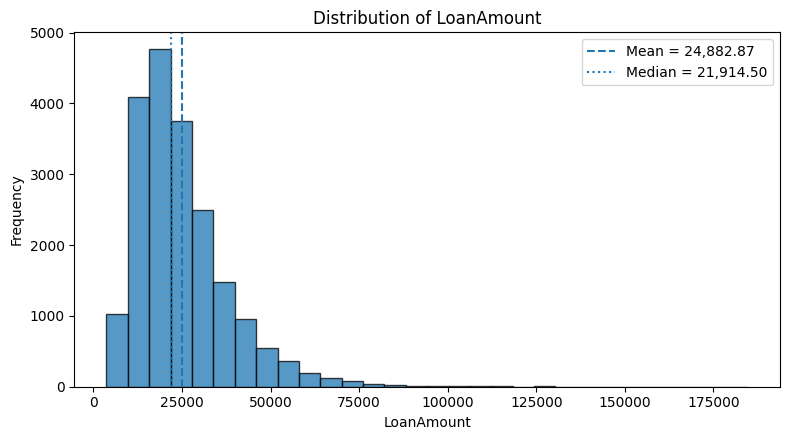

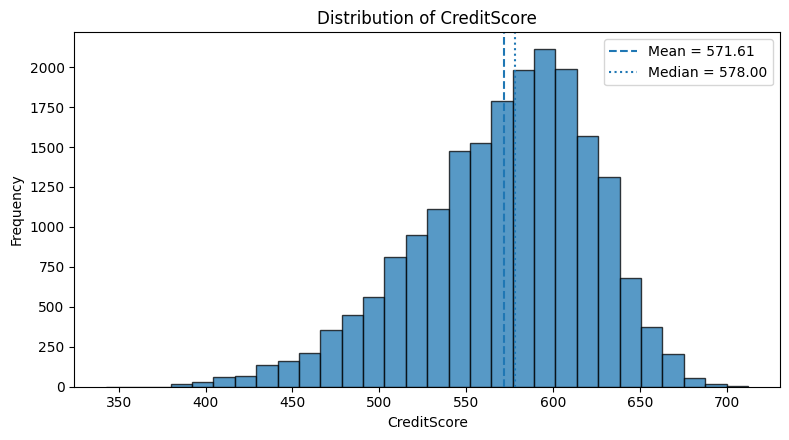

In [67]:
# ============================================================
# 2.43 Univariate Visual Analysis of Selected Numerical Attributes
# ============================================================

import matplotlib.pyplot as plt

selected_univariate_features = [
    "TotalAssets",
    "CreditCardUtilizationRate",
    "LoanAmount",
    "CreditScore"
]

for feature in selected_univariate_features:

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.hist(
        loan_data[feature].dropna(),
        bins=30,
        edgecolor="black",
        alpha=0.75
    )

    # Add mean and median as reference lines
    feature_mean = loan_data[feature].mean()
    feature_median = loan_data[feature].median()

    ax.axvline(
        feature_mean,
        linestyle="--",
        linewidth=1.5,
        label=f"Mean = {feature_mean:,.2f}"
    )

    ax.axvline(
        feature_median,
        linestyle=":",
        linewidth=1.5,
        label=f"Median = {feature_median:,.2f}"
    )

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

    ax.legend()

    plt.tight_layout()
    plt.show()

#### Interpretation

The visual distributions reinforce the statistical evidence obtained from the univariate summary. "TotalAssets" displays pronounced positive skewness, with most observations concentrated at comparatively low asset levels and a sparse but exceptionally long upper tail. The mean (96,964.40) is substantially greater than the median (60,699.00), demonstrating the influence of high-value observations on the arithmetic average.

"CreditCardUtilizationRate" exhibits an even more visually concentrated distribution, with the majority of observations located at relatively low utilisation values while a small proportion extend to exceptionally high levels. The considerable separation between the mean (37.78) and median (11.30), together with the long upper tail, confirms that conventional measures of central tendency alone would inadequately represent this variable.

"LoanAmount" demonstrates a less extreme but clearly positively skewed distribution. Most applications involve comparatively moderate loan amounts, while progressively fewer observations occur at higher values. The mean (24,882.87) exceeds the median (21,914.50), which is consistent with the positive skewness identified statistically.

In contrast, "CreditScore" exhibits a substantially more balanced unimodal distribution. Its mean (571.61) lies relatively close to its median (578.00), although the slightly lower mean is consistent with the moderate negative skewness identified in Section 2.42. The distribution therefore differs materially from the strongly right-skewed financial variables.

Collectively, the visual evidence confirms that the numerical attributes cannot be assumed to follow a common distributional form. The substantial skewness and long-tailed behaviour of several financial measures also support the earlier decision to apply robust, training-derived outlier treatment before predictive modelling.

### 2.44 Univariate Statistical Analysis of Categorical Attributes

The categorical attributes are examined using frequency and proportional summaries to identify the relative representation of each category and the degree of concentration within individual variables. This analysis provides a quantitative description of applicant characteristics and complements the numerical univariate investigation.

For each categorical predictor, the number of observations and percentage representation of each category are calculated. Missing or explicitly retained "Unknown" categories are included where applicable so that the analysis reflects the complete analytical dataset.

In [68]:
# ============================================================
# 2.44 Univariate Statistical Analysis of Categorical Attributes
# ============================================================

categorical_analysis_features = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose"
]

categorical_summary_records = []

for feature in categorical_analysis_features:

    counts = loan_data[feature].value_counts(
        dropna=False
    )

    percentages = (
        loan_data[feature]
        .value_counts(
            dropna=False,
            normalize=True
        )
        .mul(100)
    )

    for category in counts.index:

        category_label = (
            "Missing"
            if pd.isna(category)
            else str(category)
        )

        categorical_summary_records.append({
            "Variable": feature,
            "Category": category_label,
            "Frequency": counts.loc[category],
            "Percentage": percentages.loc[category]
        })

categorical_univariate_summary = pd.DataFrame(
    categorical_summary_records
)

print("UNIVARIATE CATEGORICAL STATISTICAL SUMMARY")
print("-" * 50)

print(
    f"Categorical attributes analysed : "
    f"{len(categorical_analysis_features)}"
)

display(
    categorical_univariate_summary.round({
        "Percentage": 2
    })
)

# ------------------------------------------------------------
# Variable-level concentration summary
# ------------------------------------------------------------

categorical_concentration = []

for feature in categorical_analysis_features:

    counts = loan_data[feature].value_counts(
        dropna=False
    )

    dominant_category = counts.index[0]

    categorical_concentration.append({
        "Variable": feature,
        "Number_of_Categories": loan_data[
            feature
        ].nunique(dropna=False),

        "Dominant_Category": (
            "Missing"
            if pd.isna(dominant_category)
            else str(dominant_category)
        ),

        "Dominant_Frequency": counts.iloc[0],

        "Dominant_Percent": (
            counts.iloc[0] / len(loan_data)
        ) * 100
    })

categorical_concentration_summary = pd.DataFrame(
    categorical_concentration
).set_index("Variable")

print("\nCATEGORICAL CONCENTRATION SUMMARY")
print("-" * 50)

display(
    categorical_concentration_summary.round({
        "Dominant_Percent": 2
    })
)

# Validation
print(
    "\nAll category percentages sum to approximately 100%:"
)

percentage_validation = (
    categorical_univariate_summary
    .groupby("Variable")["Percentage"]
    .sum()
    .round(2)
)

display(
    percentage_validation.rename(
        "Total_Percentage"
    ).to_frame()
)


UNIVARIATE CATEGORICAL STATISTICAL SUMMARY
--------------------------------------------------
Categorical attributes analysed : 5


,Variable,Category,Frequency,Percentage
0,EmploymentStatus,Employed,17036,85.18
1,EmploymentStatus,Self-Employed,1573,7.86
2,EmploymentStatus,Unemployed,1391,6.96
3,EducationLevel,Bachelor,6054,30.27
4,EducationLevel,High School,5908,29.54
5,EducationLevel,Associate,4034,20.17
6,EducationLevel,Master,3050,15.25
7,EducationLevel,Doctorate,954,4.77
8,MaritalStatus,Married,10029,50.14
9,MaritalStatus,Single,6077,30.38



CATEGORICAL CONCENTRATION SUMMARY
--------------------------------------------------


,Number_of_Categories,Dominant_Category,Dominant_Frequency,Dominant_Percent
Variable,,,,
EmploymentStatus,3,Employed,17036,85.18
EducationLevel,5,Bachelor,6054,30.27
MaritalStatus,5,Married,10029,50.14
HomeOwnershipStatus,4,Mortgage,7939,39.70
LoanPurpose,5,Home,5925,29.62



All category percentages sum to approximately 100%:


,Total_Percentage
Variable,
EducationLevel,100.0
EmploymentStatus,100.0
HomeOwnershipStatus,100.0
LoanPurpose,100.0
MaritalStatus,100.0


#### Interpretation

The categorical analysis identifies different levels of concentration across the applicant characteristics. "EmploymentStatus" is strongly dominated by employed applicants, who represent 85.18% of the dataset, while self-employed and unemployed applicants account for 7.86% and 6.96% respectively. Consequently, employment-related comparisons should be interpreted with awareness of the substantially different group sizes.

"EducationLevel" is more broadly distributed. Bachelor's degree holders form the largest group at 30.27%, followed closely by High School at 29.54%, while Associate (20.17%), Master (15.25%), and Doctorate (4.77%) qualifications provide progressively smaller groups. This nevertheless provides representation across all five educational categories.

For "MaritalStatus", married applicants constitute approximately half of the observations (50.14%), followed by single (30.38%), divorced (14.40%), and widowed (4.99%) applicants. Only 15 observations (0.08%) contain missing marital-status information in the original analytical dataset, confirming that the missingness identified during fundamental data understanding is very limited.

"HomeOwnershipStatus" is comparatively distributed across several groups, although Mortgage is the largest category at 39.70%, followed by Rent at 30.44%, Own at 19.69%, and Other at 10.18%.

Loan purposes are also distributed across all five categories. Home loans constitute the largest group (29.62%), followed by Debt Consolidation (25.14%), Auto (20.17%), Education (15.04%), and Other (10.03%). No single loan-purpose category therefore dominates the dataset to the extent observed for employment status.

Overall, the categorical predictors exhibit sufficient variation for subsequent comparative analysis, although the pronounced concentration within "EmploymentStatus" should be considered when interpreting category-specific approval patterns.

### 2.45 Univariate Visual Analysis of Categorical Attributes

Bar-chart visualisations are used to examine the proportional composition of the principal categorical attributes. Percentages are displayed rather than raw frequencies to provide a directly comparable representation of category prevalence across variables with different numbers of levels.

The visual analysis covers "EmploymentStatus", "EducationLevel", "MaritalStatus", "HomeOwnershipStatus", and "LoanPurpose", complementing the frequency and concentration statistics reported in Section 2.44.

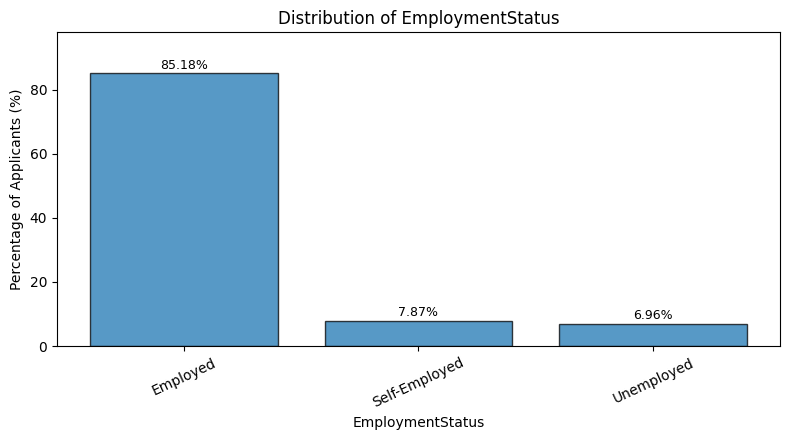

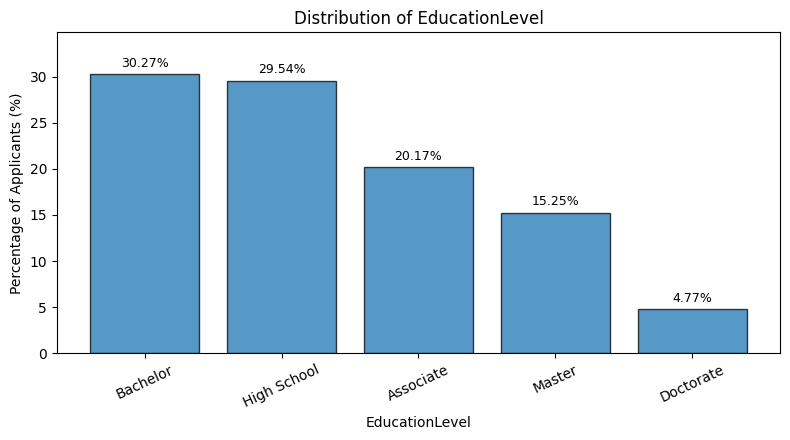

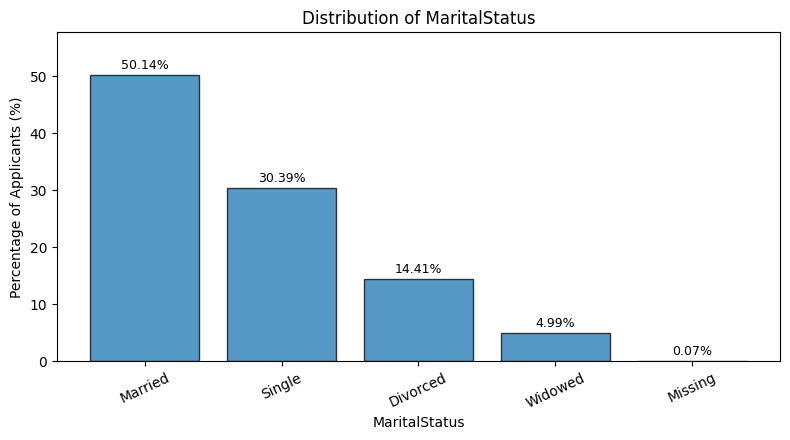

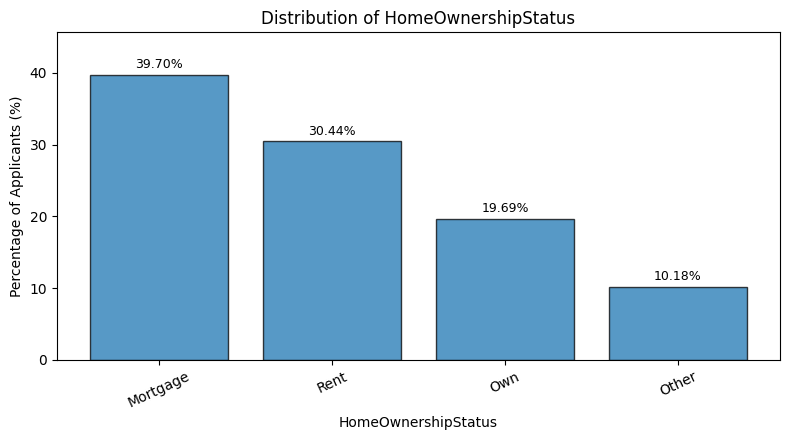

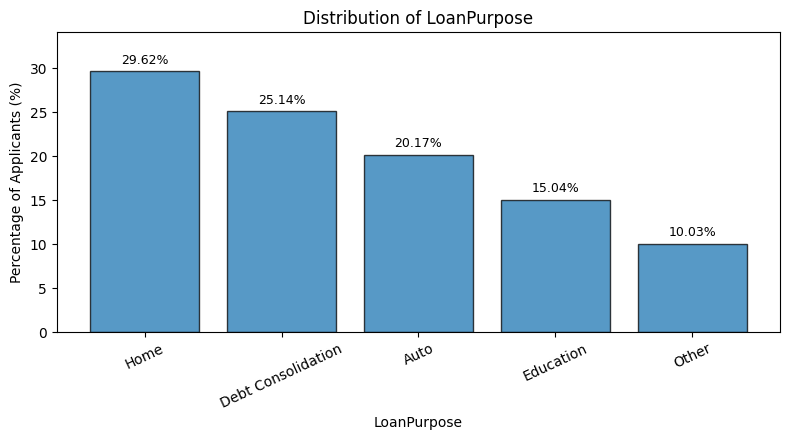

In [69]:
# ============================================================
# 2.45 Univariate Visual Analysis of Categorical Attributes
# ============================================================

import matplotlib.pyplot as plt

categorical_visual_features = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose"
]

for feature in categorical_visual_features:

    # Convert missing observations to an explicit display label
    plot_data = (
        loan_data[feature]
        .fillna("Missing")
        .value_counts(normalize=True)
        .mul(100)
        .sort_values(ascending=False)
    )

    fig, ax = plt.subplots(figsize=(8, 4.5))

    bars = ax.bar(
        plot_data.index.astype(str),
        plot_data.values,
        edgecolor="black",
        alpha=0.75
    )

    # Add percentage labels above bars
    for bar, percentage in zip(bars, plot_data.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{percentage:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Percentage of Applicants (%)")

    # Start percentage scale at zero
    ax.set_ylim(
        0,
        max(plot_data.values) * 1.15
    )

    # Improve readability for longer category labels
    ax.tick_params(
        axis="x",
        rotation=25
    )

    plt.tight_layout()
    plt.show()

#### Interpretation

The categorical visualisations confirm the distributional patterns identified in Section 2.44. "EmploymentStatus" is highly concentrated, with employed applicants representing 85.18% of the dataset, while self-employed and unemployed applicants form substantially smaller groups. This imbalance should be considered when comparing loan-approval behaviour across employment categories.

"EducationLevel" exhibits a more distributed composition. Bachelor (30.27%) and High School (29.54%) applicants constitute the two largest groups, followed by Associate (20.17%), Master (15.25%), and Doctorate (4.77%). The presence of observations across all educational categories supports meaningful category-level comparisons, although the Doctorate group is relatively small.

The "MaritalStatus" distribution is dominated by married applicants (50.14%), followed by single (30.39%), divorced (14.41%), and widowed (4.99%) applicants. The missing category represents only approximately 0.07% of observations, visually confirming that missingness in this attribute is negligible relative to the overall dataset.

For "HomeOwnershipStatus", applicants with a mortgage represent the largest group (39.70%), followed by renters (30.44%), owners (19.69%), and the Other category (10.18%). The distribution is therefore less concentrated than "EmploymentStatus".

"LoanPurpose" is comparatively well distributed across its categories. Home loans account for the largest proportion (29.62%), followed by Debt Consolidation (25.14%), Auto (20.17%), Education (15.04%), and Other (10.03%). No individual loan-purpose category accounts for a majority of applications.

Overall, the bar charts demonstrate that categorical representation varies considerably across predictors. "EmploymentStatus" shows the strongest category imbalance, whereas "EducationLevel", "HomeOwnershipStatus", and "LoanPurpose" provide broader variation across their respective categories. These differences are important when subsequently examining whether loan-approval rates vary across applicant groups.

### 2.46 Bivariate Statistical Analysis of Numerical Attributes by Loan Approval

Bivariate analysis is performed to examine how selected numerical applicant and financial characteristics differ between approved and rejected loan applications. Summary statistics are calculated separately for each loan-approval outcome, allowing differences in central tendency and relative magnitude to be quantified.

The analysis focuses on variables that demonstrated meaningful relationships with "LoanApproved" during the earlier exploratory investigation. Both mean and median values are considered because several financial attributes exhibit substantial skewness and extreme observations.

In [70]:
# ============================================================
# 2.46 Bivariate Statistical Analysis of Numerical Attributes
#      by Loan Approval Outcome
# ============================================================

bivariate_numerical_features = [
    "AnnualIncome",
    "LoanAmount",
    "NetWorth",
    "TotalAssets",
    "CreditScore",
    "InterestRate",
    "Age",
    "Experience",
    "LengthOfCreditHistory",
    "LoanDuration"
]

# ------------------------------------------------------------
# Calculate statistics separately for rejected and approved
# applications
# ------------------------------------------------------------

bivariate_records = []

for feature in bivariate_numerical_features:

    rejected = loan_data.loc[
        loan_data["LoanApproved"] == 0,
        feature
    ].dropna()

    approved = loan_data.loc[
        loan_data["LoanApproved"] == 1,
        feature
    ].dropna()

    rejected_mean = rejected.mean()
    approved_mean = approved.mean()

    rejected_median = rejected.median()
    approved_median = approved.median()

    # Relative difference in group means
    relative_mean_difference = (
        ((approved_mean - rejected_mean) / rejected_mean) * 100
        if rejected_mean != 0
        else np.nan
    )

    bivariate_records.append({
        "Variable": feature,
        "Rejected_Mean": rejected_mean,
        "Approved_Mean": approved_mean,
        "Rejected_Median": rejected_median,
        "Approved_Median": approved_median,
        "Mean_Difference": approved_mean - rejected_mean,
        "Relative_Mean_Difference_Percent":
            relative_mean_difference
    })

bivariate_numerical_summary = (
    pd.DataFrame(bivariate_records)
    .set_index("Variable")
)

print("BIVARIATE NUMERICAL ANALYSIS BY LOAN APPROVAL")
print("-" * 55)

print(
    f"Numerical attributes compared : "
    f"{len(bivariate_numerical_features)}"
)

print(
    f"Rejected applications         : "
    f"{(loan_data['LoanApproved'] == 0).sum()}"
)

print(
    f"Approved applications         : "
    f"{(loan_data['LoanApproved'] == 1).sum()}"
)

display(
    bivariate_numerical_summary.round(2)
)

# ------------------------------------------------------------
# Rank variables by magnitude of relative mean difference
# ------------------------------------------------------------

bivariate_difference_ranking = (
    bivariate_numerical_summary[
        ["Relative_Mean_Difference_Percent"]
    ]
    .assign(
        Absolute_Relative_Difference=lambda x:
        x["Relative_Mean_Difference_Percent"].abs()
    )
    .sort_values(
        "Absolute_Relative_Difference",
        ascending=False
    )
)

print("\nVARIABLES RANKED BY RELATIVE MEAN DIFFERENCE")
print("-" * 55)

display(
    bivariate_difference_ranking.round(2)
)

BIVARIATE NUMERICAL ANALYSIS BY LOAN APPROVAL
-------------------------------------------------------
Numerical attributes compared : 10
Rejected applications         : 15220
Approved applications         : 4780


,Rejected_Mean,Approved_Mean,Rejected_Median,Approved_Median,Mean_Difference,Relative_Mean_Difference_Percent
Variable,,,,,,
AnnualIncome,45641.46,102210.55,40557.50,91269.50,56569.09,123.94
LoanAmount,26685.00,19144.71,23566.00,17336.50,-7540.29,-28.26
NetWorth,59878.03,111829.04,28798.00,50528.50,51951.01,86.76
TotalAssets,84507.63,136627.99,56638.00,77370.00,52120.37,61.68
CreditScore,567.55,584.53,574.00,591.00,16.98,2.99
InterestRate,24.62,21.63,24.28,21.36,-2.98,-12.12
Age,38.83,42.68,39.00,42.00,3.84,9.90
Experience,16.63,20.37,16.00,20.00,3.73,22.46
LengthOfCreditHistory,14.46,16.54,14.00,17.00,2.08,14.38



VARIABLES RANKED BY RELATIVE MEAN DIFFERENCE
-------------------------------------------------------


,Relative_Mean_Difference_Percent,Absolute_Relative_Difference
Variable,,
AnnualIncome,123.94,123.94
NetWorth,86.76,86.76
TotalAssets,61.68,61.68
LoanAmount,-28.26,28.26
Experience,22.46,22.46
LengthOfCreditHistory,14.38,14.38
InterestRate,-12.12,12.12
Age,9.90,9.90
LoanDuration,-9.88,9.88


#### Interpretation

The bivariate comparison reveals substantial numerical differences between approved and rejected loan applications. "AnnualIncome" exhibits the largest relative difference: approved applicants have a mean annual income of 102,210.55 compared with 45,641.46 for rejected applicants, representing an increase of approximately 123.94%. The corresponding medians (91,269.50 versus 40,557.50) confirm that this difference is not attributable solely to extreme high-income observations.

Measures of financial position also differ considerably between the two groups. Approved applicants have substantially higher mean "NetWorth" (86.76% higher) and "TotalAssets" (61.68% higher) than rejected applicants. These results indicate that stronger financial resources are associated with loan approval within this dataset.

In contrast, "LoanAmount" is approximately 28.26% lower among approved applications, with the approved group having a mean loan amount of 19,144.71 compared with 26,685.00 for rejected applications. "InterestRate" is also lower among approved applicants by approximately 12.12%. These negative differences suggest that approved applications tend to involve comparatively smaller requested amounts and lower interest rates.

Applicant experience and credit-history characteristics also demonstrate positive differences. Approved applicants have approximately 22.46% greater mean "Experience" and 14.38% greater mean "LengthOfCreditHistory". Mean "Age" is approximately 9.90% higher among approved applicants. However, these variables are related conceptually and should not automatically be interpreted as independent effects.

"CreditScore" shows a comparatively small mean difference of 2.99%, although approved applicants have a higher mean (584.53) and median (591.00) than rejected applicants (567.55 and 574.00 respectively). This illustrates that a relatively small percentage difference can still represent a systematic shift in the distribution.

Overall, the strongest numerical separation between approval outcomes is observed for "AnnualIncome", "NetWorth", "TotalAssets", and "LoanAmount". These findings demonstrate association rather than causation and provide evidence for selecting financially relevant variables for subsequent multivariate and predictive analyses.

### 2.47 Bivariate Association Analysis of Categorical Attributes and Loan Approval

Categorical predictors are examined in relation to "LoanApproved" using contingency-table analysis and the Chi-square test of independence. The Chi-square test evaluates whether the observed distribution of approval outcomes differs significantly across the categories of each predictor.

Because statistical significance alone does not indicate the magnitude of an association, Cramér's V is additionally calculated as an effect-size measure. Values closer to zero indicate weaker categorical association, while larger values indicate stronger relationships. Category-specific approval rates are also reported to support practical interpretation of the identified associations.

In [71]:
# ============================================================
# 2.47 Bivariate Association Analysis of Categorical Attributes
#      and Loan Approval
# ============================================================

from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

categorical_bivariate_features = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose"
]

chi_square_results = []
category_approval_records = []

for feature in categorical_bivariate_features:

    # Explicitly retain missing categories for analytical reporting
    analysis_feature = (
        loan_data[feature]
        .astype("object")
        .fillna("Missing")
    )

    # --------------------------------------------------------
    # Contingency table
    # --------------------------------------------------------
    contingency_table = pd.crosstab(
        analysis_feature,
        loan_data["LoanApproved"]
    )

    # Ensure both target classes are represented as columns
    contingency_table = contingency_table.reindex(
        columns=[0, 1],
        fill_value=0
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    n = contingency_table.to_numpy().sum()

    # Cramér's V
    denominator = min(
        contingency_table.shape[0] - 1,
        contingency_table.shape[1] - 1
    )

    cramers_v = (
        np.sqrt((chi2 / n) / denominator)
        if denominator > 0
        else np.nan
    )

    minimum_expected = expected.min()

    chi_square_results.append({
        "Variable": feature,
        "Chi_Square": chi2,
        "Degrees_of_Freedom": dof,
        "P_Value": p_value,
        "Cramers_V": cramers_v,
        "Minimum_Expected_Count": minimum_expected
    })

    # --------------------------------------------------------
    # Category-specific approval rates
    # --------------------------------------------------------
    category_table = pd.DataFrame({
        "Category": analysis_feature,
        "LoanApproved": loan_data["LoanApproved"]
    })

    category_summary = (
        category_table
        .groupby("Category", dropna=False)["LoanApproved"]
        .agg(
            Applications="count",
            Approved="sum"
        )
        .reset_index()
    )

    category_summary["Approval_Rate_Percent"] = (
        category_summary["Approved"]
        / category_summary["Applications"]
        * 100
    )

    category_summary.insert(
        0,
        "Variable",
        feature
    )

    category_approval_records.append(category_summary)


# Combine statistical-test results
categorical_association_results = (
    pd.DataFrame(chi_square_results)
    .sort_values(
        "Cramers_V",
        ascending=False
    )
    .reset_index(drop=True)
)

# Combine category-level approval rates
categorical_approval_rates = pd.concat(
    category_approval_records,
    ignore_index=True
)

print("CATEGORICAL ASSOCIATION WITH LOAN APPROVAL")
print("-" * 55)

print(
    f"Categorical attributes tested : "
    f"{len(categorical_bivariate_features)}"
)

display(
    categorical_association_results.round({
        "Chi_Square": 3,
        "P_Value": 6,
        "Cramers_V": 3,
        "Minimum_Expected_Count": 2
    })
)

print("\nCATEGORY-SPECIFIC LOAN APPROVAL RATES")
print("-" * 55)

display(
    categorical_approval_rates.round({
        "Approval_Rate_Percent": 2
    })
)

# ------------------------------------------------------------
# Chi-square assumption check
# ------------------------------------------------------------

assumption_check = (
    categorical_association_results[
        ["Variable", "Minimum_Expected_Count"]
    ]
    .copy()
)

assumption_check["Expected_Count_At_Least_5"] = (
    assumption_check["Minimum_Expected_Count"] >= 5
)

print("\nCHI-SQUARE EXPECTED-FREQUENCY CHECK")
print("-" * 55)

display(assumption_check)

CATEGORICAL ASSOCIATION WITH LOAN APPROVAL
-------------------------------------------------------
Categorical attributes tested : 5


,Variable,Chi_Square,Degrees_of_Freedom,P_Value,Cramers_V,Minimum_Expected_Count
0,EducationLevel,764.755,4,0.000000,0.196,228.01
1,EmploymentStatus,38.507,2,0.000000,0.044,332.45
2,HomeOwnershipStatus,26.329,3,0.000008,0.036,486.60
3,LoanPurpose,6.696,4,0.152867,0.018,479.43
4,MaritalStatus,2.609,4,0.625171,0.011,3.58



CATEGORY-SPECIFIC LOAN APPROVAL RATES
-------------------------------------------------------


,Variable,Category,Applications,Approved,Approval_Rate_Percent
0,EmploymentStatus,Employed,17036,4089,24.00
1,EmploymentStatus,Self-Employed,1573,438,27.84
2,EmploymentStatus,Unemployed,1391,253,18.19
3,EducationLevel,Associate,4034,824,20.43
4,EducationLevel,Bachelor,6054,1613,26.64
5,EducationLevel,Doctorate,954,420,44.03
6,EducationLevel,High School,5908,853,14.44
7,EducationLevel,Master,3050,1070,35.08
8,MaritalStatus,Divorced,2881,705,24.47
9,MaritalStatus,Married,10029,2394,23.87



CHI-SQUARE EXPECTED-FREQUENCY CHECK
-------------------------------------------------------


,Variable,Minimum_Expected_Count,Expected_Count_At_Least_5
0,EducationLevel,228.006,True
1,EmploymentStatus,332.449,True
2,HomeOwnershipStatus,486.604,True
3,LoanPurpose,479.434,True
4,MaritalStatus,3.585,False


#### Interpretation

The categorical association analysis demonstrates that "EducationLevel" has the strongest relationship with loan approval among the categorical predictors examined. The Chi-square test is statistically significant (χ² = 764.755, p < 0.001), while Cramér's V = 0.196 indicates a meaningful, although not strong, association. Approval rates vary considerably across education categories, ranging from 14.44% for High School applicants to 44.03% for Doctorate applicants. Master applicants also demonstrate a comparatively high approval rate of 35.08%, compared with 26.64% for Bachelor and 20.43% for Associate applicants.

"EmploymentStatus" also shows a statistically significant association with loan approval (χ² = 38.507, p < 0.001); however, its Cramér's V of 0.044 indicates that the practical strength of this relationship is weak. Self-employed applicants have the highest approval rate (27.84%), followed by employed applicants (24.00%), while unemployed applicants have the lowest rate (18.19%).

A statistically significant but weak association is also observed for "HomeOwnershipStatus" (χ² = 26.329, p < 0.001, Cramér's V = 0.036). Approval rates range from 20.48% for the Other category to 25.15% for applicants with a mortgage, demonstrating relatively limited variation between home-ownership groups.

In contrast, "LoanPurpose" does not demonstrate a statistically significant relationship with loan approval at the 5% significance level (χ² = 6.696, p = 0.153, Cramér's V = 0.018). Approval rates are relatively similar across loan-purpose categories, ranging from 22.33% to 25.30%. This suggests that loan purpose provides comparatively little standalone separation between approval outcomes in this dataset.

"MaritalStatus" similarly shows no statistically significant association with loan approval (χ² = 2.609, p = 0.625, Cramér's V = 0.011). Approval rates for the substantive marital-status categories are relatively similar. Although the Missing category has an approval rate of 13.33%, it contains only 15 observations and should not be interpreted as evidence of a meaningful pattern.
The Chi-square expected-frequency assumption is satisfied for "EducationLevel", "EmploymentStatus", "HomeOwnershipStatus", and "LoanPurpose". However, "MaritalStatus" has a minimum expected count of 3.585 because of the very small missing-value category. Consequently, its conventional Chi-square result should be interpreted cautiously.

Overall, "EducationLevel" provides the clearest categorical differentiation in loan approval, whereas the remaining categorical predictors exhibit either weak or statistically non-significant associations. These results describe bivariate relationships and do not establish independent predictive effects after controlling for other applicant characteristics.

### 2.48 Bivariate Visual Analysis of Categorical Attributes and Loan Approval

Category-specific loan approval rates are visualised to complement the Chi-square and Cramér's V results reported in Section 2.47. Approval-rate percentages are used instead of raw approval counts so that categories with different sample sizes can be compared directly.

The visualisations examine whether approval outcomes vary systematically across "EmploymentStatus", "EducationLevel", "MaritalStatus", "HomeOwnershipStatus", and "LoanPurpose". Particular attention is given to `EducationLevel`, which demonstrated the strongest categorical association with loan approval in the preceding statistical analysis.

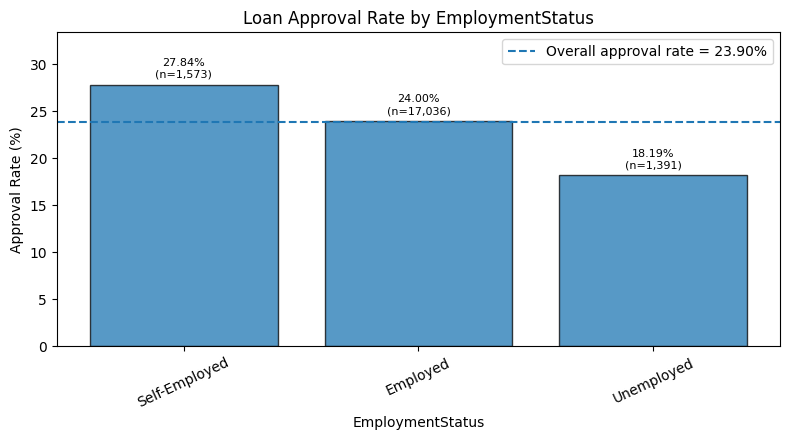

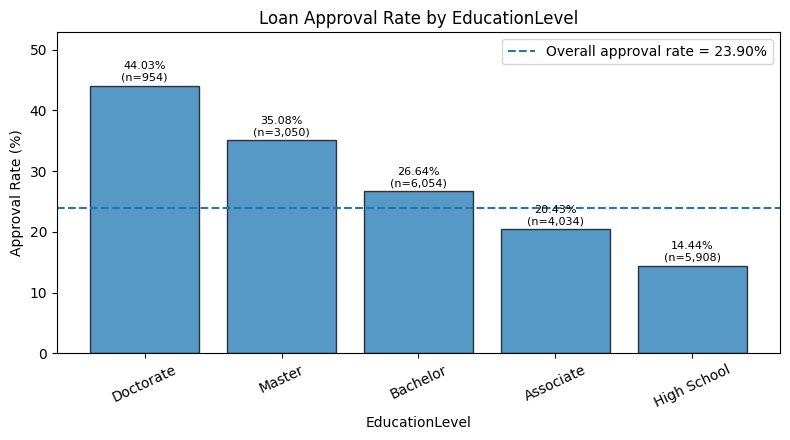

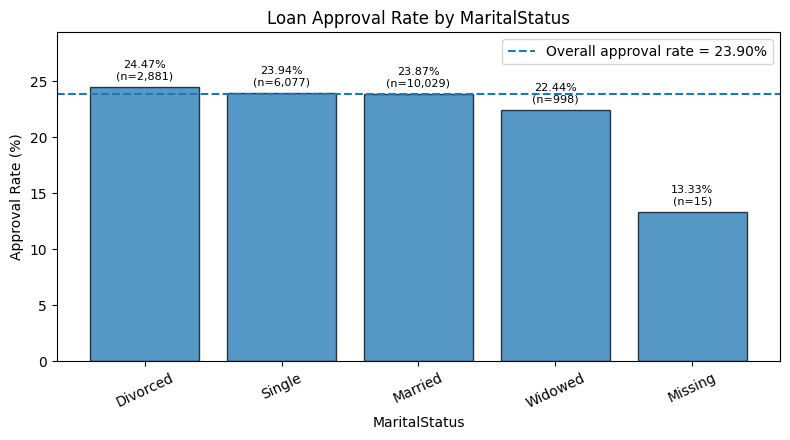

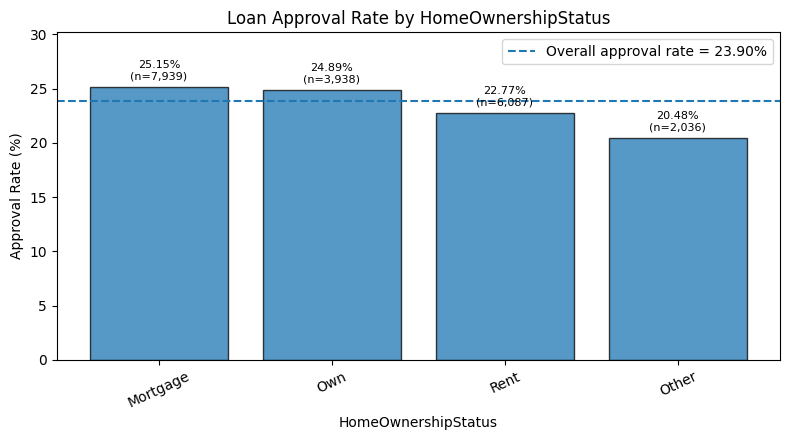

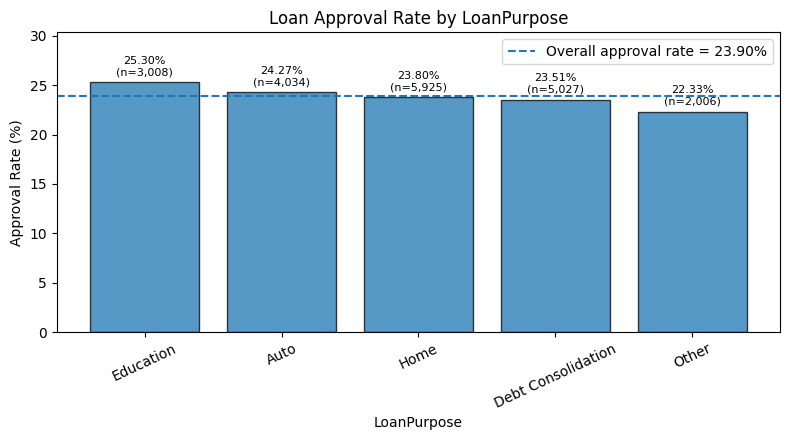

In [72]:
# ============================================================
# 2.48 Bivariate Visual Analysis of Categorical Attributes
#      and Loan Approval
# ============================================================

import matplotlib.pyplot as plt

categorical_bivariate_visuals = [
    "EmploymentStatus",
    "EducationLevel",
    "MaritalStatus",
    "HomeOwnershipStatus",
    "LoanPurpose"
]

for feature in categorical_bivariate_visuals:

    # Retain missing observations as an explicit category
    plot_frame = pd.DataFrame({
        feature: loan_data[feature]
            .astype("object")
            .fillna("Missing"),

        "LoanApproved": loan_data["LoanApproved"]
    })

    # Mean of binary LoanApproved gives approval proportion
    approval_rates = (
        plot_frame
        .groupby(feature)["LoanApproved"]
        .agg(
            Approval_Rate="mean",
            Applications="count"
        )
        .reset_index()
    )

    approval_rates["Approval_Rate_Percent"] = (
        approval_rates["Approval_Rate"] * 100
    )

    # Sort categories by approval rate
    approval_rates = approval_rates.sort_values(
        "Approval_Rate_Percent",
        ascending=False
    )

    fig, ax = plt.subplots(figsize=(8, 4.5))

    bars = ax.bar(
        approval_rates[feature].astype(str),
        approval_rates["Approval_Rate_Percent"],
        edgecolor="black",
        alpha=0.75
    )

    # Overall approval rate reference
    overall_approval_rate = (
        loan_data["LoanApproved"].mean() * 100
    )

    ax.axhline(
        overall_approval_rate,
        linestyle="--",
        linewidth=1.5,
        label=(
            f"Overall approval rate = "
            f"{overall_approval_rate:.2f}%"
        )
    )

    # Add approval-rate and sample-size labels
    for bar, rate, n in zip(
        bars,
        approval_rates["Approval_Rate_Percent"],
        approval_rates["Applications"]
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{rate:.2f}%\n(n={n:,})",
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.set_title(
        f"Loan Approval Rate by {feature}"
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Approval Rate (%)")

    ax.set_ylim(
        0,
        max(
            approval_rates["Approval_Rate_Percent"].max() * 1.20,
            overall_approval_rate * 1.20
        )
    )

    ax.tick_params(
        axis="x",
        rotation=25
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

#### Interpretation

The approval-rate visualisations reinforce the statistical findings from Section 2.47. The overall loan approval rate is 23.90%, providing a useful reference for evaluating differences between individual categories.

"EducationLevel" displays the clearest variation in approval outcomes. Doctorate applicants have the highest approval rate at 44.03%, followed by Master (35.08%) and Bachelor (26.64%) applicants, all above the overall approval rate. In contrast, Associate applicants have an approval rate of 20.43%, while High School applicants have the lowest rate at 14.44%. The substantial separation between these categories visually supports the comparatively stronger association identified by the Chi-square test and Cramér's V.

Differences are also visible across "EmploymentStatus". Self-employed applicants have the highest approval rate at 27.84%, employed applicants are approximately aligned with the overall rate at 24.00%, and unemployed applicants have a lower approval rate of 18.19%. However, the smaller separation between these groups is consistent with the weak Cramér's V observed previously.

"HomeOwnershipStatus" demonstrates relatively modest variation. Applicants with a mortgage (25.15%) and those who own their property (24.89%) have approval rates slightly above the overall rate, while renters (22.77%) and applicants classified as Other (20.48%) have somewhat lower approval rates. This supports the statistically significant but weak association identified in Section 2.47.

Approval rates across the substantive "MaritalStatus" categories are closely grouped, ranging from 22.44% for widowed applicants to 24.47% for divorced applicants. Although the Missing category has a lower approval rate of 13.33%, it contains only 15 observations and should not be treated as evidence of a meaningful pattern. The visual similarity of the main categories is consistent with the non-significant Chi-square result.

"LoanPurpose" shows similarly limited variation, with approval rates ranging from 22.33% for Other to 25.30% for Education. Most categories remain close to the overall approval rate, visually supporting the conclusion that loan purpose has little standalone association with the approval outcome.

Overall, the visual analysis confirms "EducationLevel" as the categorical attribute with the clearest bivariate relationship with loan approval. The remaining categorical variables exhibit comparatively small differences, demonstrating the importance of considering both statistical significance and practical effect size when evaluating potential predictors.

### 2.49 Multivariate Correlation Analysis and Heatmap

A multivariate correlation analysis is conducted to examine relationships among selected numerical attributes and the loan-approval outcome simultaneously. The analysis focuses on variables that demonstrated notable bivariate relationships with "LoanApproved" together with financially and demographically relevant predictors.

A correlation heatmap is used to visualise the direction and magnitude of pairwise linear relationships. This provides insight into both predictor–target associations and potential relationships among predictors that may introduce redundant information or multicollinearity in subsequent modelling.

MULTIVARIATE CORRELATION ANALYSIS
--------------------------------------------------
Variables included : 11


Variable,AnnualIncome,NetWorth,TotalAssets,LoanAmount,CreditScore,InterestRate,Age,Experience,LengthOfCreditHistory,LoanDuration,LoanApproved
Variable,,,,,,,,,,,
AnnualIncome,1.000,-0.004,-0.005,-0.004,0.104,-0.064,0.145,0.146,-0.005,0.003,0.598
NetWorth,-0.004,1.000,0.979,-0.004,0.002,-0.006,0.014,0.015,0.004,-0.009,0.188
TotalAssets,-0.005,0.979,1.000,-0.004,0.001,-0.006,0.012,0.013,0.005,-0.008,0.184
LoanAmount,-0.004,-0.004,-0.004,1.000,-0.011,0.323,-0.007,-0.008,0.001,-0.000,-0.239
CreditScore,0.104,0.002,0.001,-0.011,1.000,-0.599,0.323,0.328,0.005,-0.001,0.142
InterestRate,-0.064,-0.006,-0.006,0.323,-0.599,1.000,-0.203,-0.206,0.005,0.488,-0.302
Age,0.145,0.014,0.012,-0.007,0.323,-0.203,1.000,0.983,-0.000,-0.007,0.141
Experience,0.146,0.015,0.013,-0.008,0.328,-0.206,0.983,1.000,-0.001,-0.008,0.141
LengthOfCreditHistory,-0.005,0.004,0.005,0.001,0.005,0.005,-0.000,-0.001,1.000,0.014,0.106


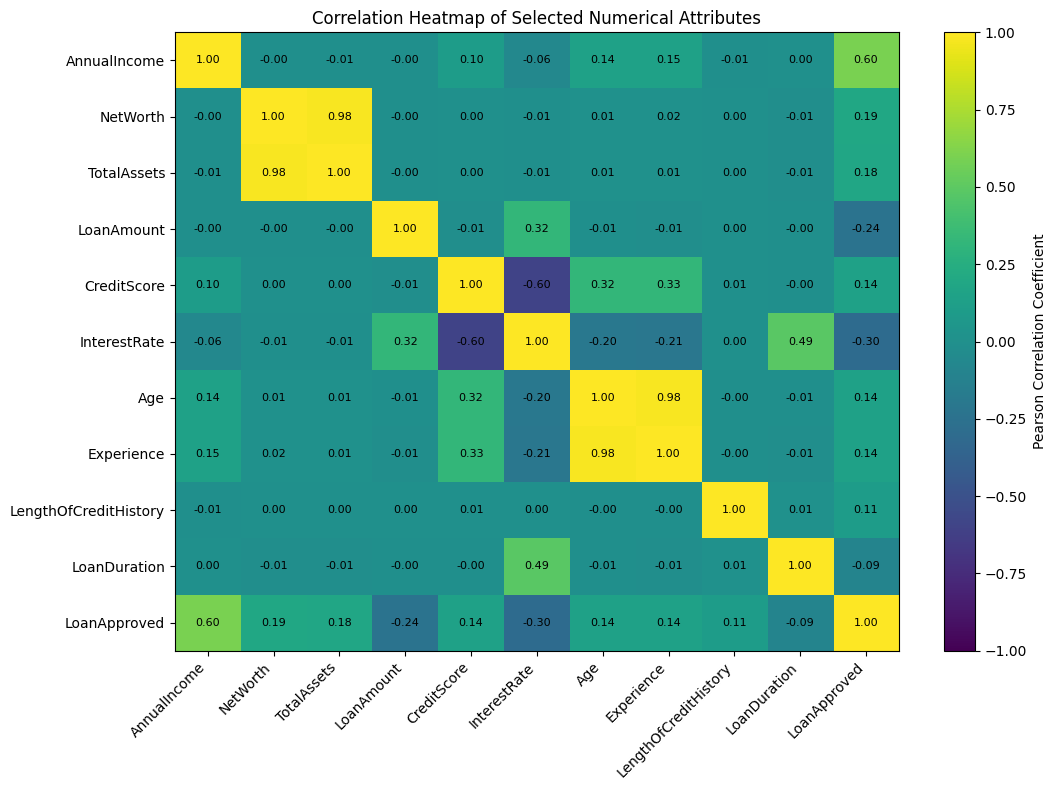


SELECTED NUMERICAL CORRELATIONS WITH LOAN APPROVAL
--------------------------------------------------


,Correlation_with_LoanApproved,Absolute_Correlation
Variable,,
AnnualIncome,0.598,0.598
InterestRate,-0.302,0.302
LoanAmount,-0.239,0.239
NetWorth,0.188,0.188
TotalAssets,0.184,0.184
CreditScore,0.142,0.142
Age,0.141,0.141
Experience,0.141,0.141
LengthOfCreditHistory,0.106,0.106


In [73]:
# ============================================================
# 2.49 Multivariate Correlation Analysis and Heatmap
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

multivariate_features = [
    "AnnualIncome",
    "NetWorth",
    "TotalAssets",
    "LoanAmount",
    "CreditScore",
    "InterestRate",
    "Age",
    "Experience",
    "LengthOfCreditHistory",
    "LoanDuration",
    "LoanApproved"
]

# Calculate Pearson correlation matrix
multivariate_correlation = (
    loan_data[multivariate_features]
    .corr(method="pearson")
)

print("MULTIVARIATE CORRELATION ANALYSIS")
print("-" * 50)

print(
    f"Variables included : "
    f"{len(multivariate_features)}"
)

display(multivariate_correlation.round(3))


# ------------------------------------------------------------
# Correlation heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 8))

heatmap = ax.imshow(
    multivariate_correlation.values,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

# Axis labels
ax.set_xticks(
    np.arange(len(multivariate_features))
)

ax.set_yticks(
    np.arange(len(multivariate_features))
)

ax.set_xticklabels(
    multivariate_features,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    multivariate_features
)

# Add correlation coefficients to each cell
for i in range(len(multivariate_features)):
    for j in range(len(multivariate_features)):

        value = multivariate_correlation.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title(
    "Correlation Heatmap of Selected Numerical Attributes"
)

# Add colour scale
colorbar = fig.colorbar(
    heatmap,
    ax=ax
)

colorbar.set_label(
    "Pearson Correlation Coefficient"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Correlations specifically with LoanApproved
# ------------------------------------------------------------

target_multivariate_correlations = (
    multivariate_correlation["LoanApproved"]
    .drop("LoanApproved")
    .to_frame("Correlation_with_LoanApproved")
)

target_multivariate_correlations[
    "Absolute_Correlation"
] = (
    target_multivariate_correlations[
        "Correlation_with_LoanApproved"
    ].abs()
)

target_multivariate_correlations = (
    target_multivariate_correlations
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
)

print(
    "\nSELECTED NUMERICAL CORRELATIONS WITH LOAN APPROVAL"
)
print("-" * 50)

display(
    target_multivariate_correlations.round(3)
)

#### Interpretation

The multivariate correlation analysis identifies several important relationships among the numerical attributes and the loan-approval outcome.

"AnnualIncome" demonstrates the strongest numerical association with "LoanApproved", with a positive correlation of **0.598**. This indicates that applicants with higher annual incomes are substantially more likely to receive loan approval within this dataset. "InterestRate" has the strongest negative association with approval (**r = -0.302**), indicating that higher interest rates are associated with lower approval outcomes. "LoanAmount" also shows a negative relationship (**r = -0.239**), suggesting that larger requested loan amounts tend to be associated with lower approval rates.

Moderate-to-weak positive relationships with loan approval are observed for "NetWorth" (**r = 0.188**) and "TotalAssets" (**r = 0.184**). "CreditScore", "Age", and "Experience" show smaller positive correlations of approximately **0.14**, while "LengthOfCreditHistory" has a weaker positive correlation (**r = 0.106**). "LoanDuration" demonstrates only a weak negative association with approval (**r = -0.095**).

The heatmap also reveals several strong relationships between predictors. "Age" and "Experience" are extremely highly correlated (**r = 0.983**), while "NetWorth" and "TotalAssets" have a similarly strong positive correlation (**r = 0.979**). These relationships indicate substantial redundancy between these predictor pairs and support the multicollinearity concerns identified earlier through the Variance Inflation Factor analysis.

A moderately strong negative relationship is observed between "CreditScore" and "InterestRate" (**r = -0.599**), suggesting that applicants with higher credit scores generally receive lower interest rates. "LoanDuration" and "InterestRate" are moderately positively correlated (**r = 0.488**), while "LoanAmount" and "InterestRate" show a weaker positive relationship (**r = 0.323**).

Overall, the multivariate analysis identifies `AnnualIncome`, `InterestRate`, and `LoanAmount` as the numerical variables with the strongest individual linear relationships with loan approval. At the same time, the very high correlations between "Age" and `Experience`, and between `NetWorth` and `TotalAssets`, demonstrate that predictor relationships must also be considered during model development. Correlation represents association rather than causation, and these bivariate coefficients do not measure the independent contribution of each predictor after controlling for other variables.

### 2.50 Scatter-Plot Analysis of Key Numerical Relationships

Scatter plots are used to further investigate selected numerical relationships identified in the multivariate correlation analysis. The plots provide a visual assessment of the direction, strength, linearity, spread, and potential outliers associated with important predictor relationships.

The analysis focuses on "Age" versus "Experience", `NetWorth` versus "TotalAssets", `CreditScore` versus `InterestRate`, and `LoanAmount` versus `InterestRate`. These relationships were selected because they represent both strong predictor redundancy and financially relevant associations identified by the preceding correlation analysis.

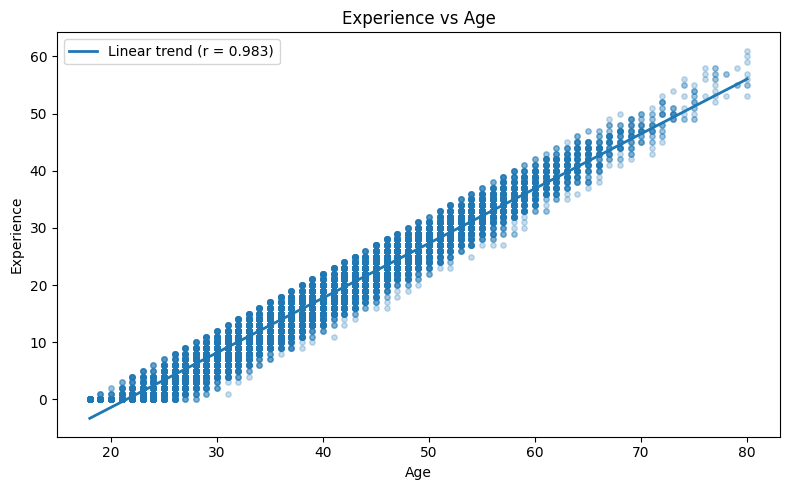

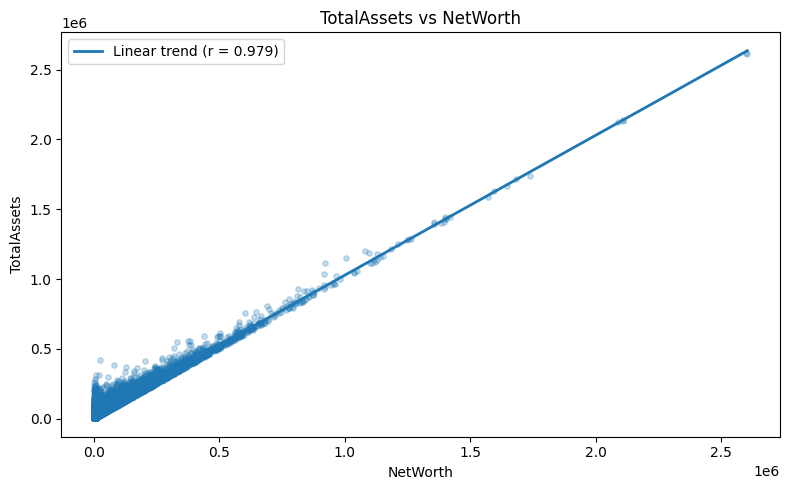

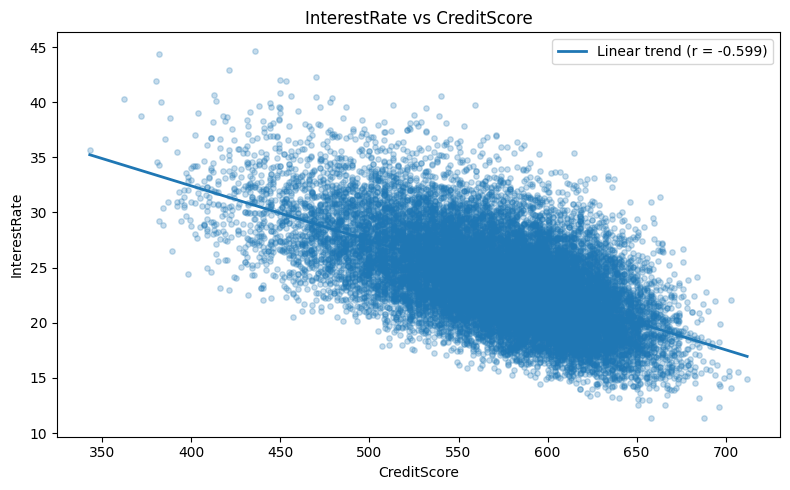

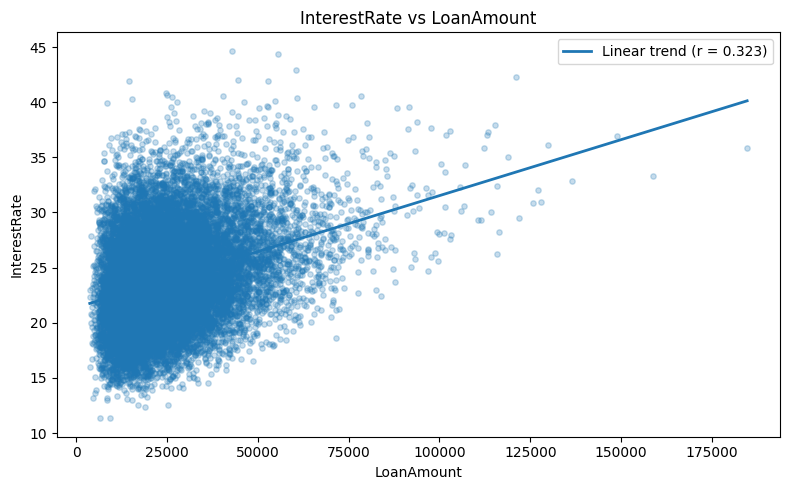

SCATTER-PLOT RELATIONSHIP SUMMARY
--------------------------------------------------


,X_Variable,Y_Variable,Observations,Pearson_Correlation
0,Age,Experience,20000,0.983
1,NetWorth,TotalAssets,20000,0.979
2,CreditScore,InterestRate,20000,-0.599
3,LoanAmount,InterestRate,20000,0.323


In [74]:
# ============================================================
# 2.50 Scatter-Plot Analysis of Key Numerical Relationships
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

scatter_relationships = [
    ("Age", "Experience"),
    ("NetWorth", "TotalAssets"),
    ("CreditScore", "InterestRate"),
    ("LoanAmount", "InterestRate")
]

scatter_summary = []

for x_variable, y_variable in scatter_relationships:

    # Retain only complete observations for the selected pair
    plot_data = (
        loan_data[[x_variable, y_variable]]
        .dropna()
        .copy()
    )

    # Pearson correlation
    correlation = plot_data[
        [x_variable, y_variable]
    ].corr().iloc[0, 1]

    scatter_summary.append({
        "X_Variable": x_variable,
        "Y_Variable": y_variable,
        "Observations": len(plot_data),
        "Pearson_Correlation": correlation
    })

    # --------------------------------------------------------
    # Scatter plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(
        plot_data[x_variable],
        plot_data[y_variable],
        alpha=0.25,
        s=15
    )

    # --------------------------------------------------------
    # Add linear trend line
    # --------------------------------------------------------

    x = plot_data[x_variable].to_numpy()
    y = plot_data[y_variable].to_numpy()

    slope, intercept = np.polyfit(
        x,
        y,
        1
    )

    x_line = np.linspace(
        x.min(),
        x.max(),
        100
    )

    y_line = (
        slope * x_line
        + intercept
    )

    ax.plot(
        x_line,
        y_line,
        linewidth=2,
        label=f"Linear trend (r = {correlation:.3f})"
    )

    ax.set_title(
        f"{y_variable} vs {x_variable}"
    )

    ax.set_xlabel(x_variable)
    ax.set_ylabel(y_variable)

    ax.legend()

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Numerical summary
# ------------------------------------------------------------

scatter_relationship_summary = pd.DataFrame(
    scatter_summary
)

print("SCATTER-PLOT RELATIONSHIP SUMMARY")
print("-" * 50)

display(
    scatter_relationship_summary.round({
        "Pearson_Correlation": 3
    })
)


#### Interpretation

The scatter-plot analysis provides visual confirmation of several important numerical relationships identified in the correlation analysis.

"Age" and "Experience" demonstrate an extremely strong positive linear relationship, with a Pearson correlation of **r = 0.983**. The observations are tightly concentrated around the fitted trend line, indicating that experience generally increases with age. The strength of this relationship suggests that the two variables contain substantial overlapping information and may introduce multicollinearity if both are included simultaneously in certain models.

A similarly strong positive relationship is observed between "NetWorth" and "TotalAssets" (**r = 0.979**). The scatter plot shows that higher net worth is closely associated with higher total assets. Although some high-value observations are visible, the overall relationship remains strongly linear. This further supports the multicollinearity concerns identified previously through the correlation and VIF analyses.

"CreditScore" and "InterestRate" exhibit a moderately strong negative relationship (**r = -0.599**). The downward trend indicates that applicants with higher credit scores generally receive lower interest rates. Nevertheless, considerable dispersion remains around the fitted line, indicating that credit score alone does not completely determine the interest rate.

"LoanAmount" and "InterestRate" show a weaker positive relationship (**r = 0.323**). The fitted trend suggests that larger requested loan amounts are generally associated with somewhat higher interest rates. However, the substantial spread of observations indicates considerable variability and suggests that other applicant and loan characteristics also influence interest rates.

Overall, the scatter plots confirm that some predictors contain highly overlapping information, particularly "Age" with "Experience" and "NetWorth" with `TotalAssets`. These findings are important for subsequent model development because highly correlated predictors may require feature selection or other multicollinearity-management strategies. The plots also demonstrate meaningful financial relationships involving credit score, interest rate, and loan amount while highlighting substantial variation at the individual-applicant level.

### 2.51 Task 2(c) — Statistical and Visualisation Summary

The statistical and visual analyses provide several important insights into the characteristics associated with loan approval.

#### Numerical Attributes

The numerical analysis identified "AnnualIncome" as the variable with the strongest positive relationship with loan approval (**r = 0.598**). Approved applicants have substantially higher average annual income than rejected applicants, indicating that income is likely to be an important predictor of approval.

"InterestRate" has the strongest negative numerical relationship with approval (**r = -0.302**), while "LoanAmount" also shows a negative association (**r = -0.239**). Higher interest rates and larger requested loan amounts are therefore associated with lower approval outcomes. "NetWorth" (**r = 0.188**) and "TotalAssets" (**r = 0.184**) show weaker positive relationships with approval.

The distribution analysis revealed substantial positive skewness and extreme values in several financial variables, particularly "AnnualIncome", "NetWorth", "TotalAssets", and "CreditCardUtilizationRate". In contrast, "CreditScore" and "InterestRate" exhibit comparatively more regular distributions. These findings support the earlier use of robust preprocessing and outlier treatment.

#### Categorical Attributes

Among the categorical variables, "EducationLevel" demonstrates the clearest association with loan approval (**χ² = 764.755, p < 0.001, Cramér's V = 0.196**). Approval rates increase substantially across educational groups, from **14.44% for High School** applicants to **44.03% for Doctorate** applicants.

"EmploymentStatus" and "HomeOwnershipStatus" are also statistically associated with approval, but their small Cramér's V values indicate weak practical relationships. In contrast, "LoanPurpose" and "MaritalStatus" do not demonstrate statistically significant associations with the approval outcome. The Chi-square result for "MaritalStatus" should additionally be interpreted cautiously because the small missing-value category produces an expected frequency below five.

#### Multivariate Relationships

The correlation heatmap and scatter plots reveal substantial relationships among several predictors. "Age" and "Experience" are extremely highly correlated (**r = 0.983**), while "NetWorth" and "TotalAssets" are similarly correlated (**r = 0.979**). These relationships indicate substantial predictor redundancy and are consistent with the multicollinearity identified earlier through the VIF analysis.

A moderately strong negative relationship is also observed between "CreditScore"  and "InterestRate" (**r = -0.599**), indicating that higher credit scores tend to be associated with lower interest rates. "LoanDuration" and "InterestRate" are moderately positively correlated (**r = 0.488**), while `LoanAmount` and `InterestRate` show a weaker positive relationship (**r = 0.323**).

#### Overall Findings

Overall, the analysis indicates that loan approval is associated most clearly with applicants' financial capacity and selected credit-related characteristics. `AnnualIncome` provides the strongest numerical separation, while `EducationLevel` provides the clearest categorical differentiation. `InterestRate` and `LoanAmount` are important negative correlates of approval.

The analysis also identifies substantial skewness, outliers, class imbalance, and multicollinearity that must be considered during model development. In particular, highly correlated predictor pairs such as "Age"–"Experience" and `NetWorth`–`TotalAssets` may require feature-selection decisions when constructing models.

These findings provide the statistical and visual evidence required to guide the modelling stage. However, the relationships identified during EDA represent associations rather than causal effects, and their independent predictive contributions should therefore be evaluated through appropriate model training and validation.

# Task 3 — Building Models

## 3.1 Modelling Strategy

This task develops supervised and unsupervised machine-learning models using the cleaned and preprocessed loan-application data prepared in Task 2.

The modelling stage consists of three main components:

1. Principal Component Analysis (PCA) — to investigate dimensionality reduction and demonstrate how selected sensitive numerical information can be represented through transformed components rather than directly identifiable original attributes.

2. Logistic Regression — to perform binary classification of the "LoanApproved" outcome. Model performance will be evaluated using accuracy, precision, recall, F1-score, ROC-AUC and a confusion matrix. A baseline model will subsequently be improved and the resulting performance compared.

3. K-Means Clustering — to identify naturally occurring applicant groups without using the loan-approval target during cluster formation. The number of clusters will be assessed using appropriate clustering diagnostics, and the resulting clusters will be profiled and interpreted.

The modelling process will maintain the previously established training/test separation to prevent data leakage. Transformations that learn parameters from data will be fitted using training data where appropriate.

## 3.2 Model-Ready Data Verification

Before constructing the models, the prepared training and test datasets are verified to ensure that the modelling matrices have compatible dimensions, contain finite values, preserve the target distribution, and remain completely separated.

This verification provides a final integrity checkpoint between the exploratory/preprocessing stage and the modelling stage.

In [75]:
# ============================================================
# 3.2 Model-Ready Data Verification
# ============================================================

import numpy as np
import pandas as pd

print("MODEL-READY DATA VERIFICATION")
print("-" * 50)

print(f"Training feature matrix : {X_train_final.shape}")
print(f"Test feature matrix     : {X_test_final.shape}")
print(f"Training target         : {y_train.shape}")
print(f"Test target             : {y_test.shape}")

# ------------------------------------------------------------
# Structural checks
# ------------------------------------------------------------

same_feature_width = (
    X_train_final.shape[1] ==
    X_test_final.shape[1]
)

train_finite = np.isfinite(
    np.asarray(X_train_final)
).all()

test_finite = np.isfinite(
    np.asarray(X_test_final)
).all()

target_classes = sorted(
    pd.Series(y_train).unique().tolist()
)

train_target_missing = (
    pd.Series(y_train).isna().sum()
)

test_target_missing = (
    pd.Series(y_test).isna().sum()
)

print()
print(f"Feature widths match    : {same_feature_width}")
print(f"Training values finite  : {train_finite}")
print(f"Test values finite      : {test_finite}")
print(f"Target classes          : {target_classes}")
print(f"Training target missing : {train_target_missing}")
print(f"Test target missing     : {test_target_missing}")


# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

train_distribution = (
    pd.Series(y_train)
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

test_distribution = (
    pd.Series(y_test)
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_distribution_check = pd.DataFrame({
    "Training_Percent": train_distribution,
    "Test_Percent": test_distribution
})

target_distribution_check.index = [
    "Rejected (0)" if value == 0 else "Approved (1)"
    for value in target_distribution_check.index
]

print("\nTARGET DISTRIBUTION (%)")
print("-" * 50)

display(
    target_distribution_check.round(2)
)


# ------------------------------------------------------------
# Final assertions
# ------------------------------------------------------------

assert same_feature_width, (
    "Training and test feature widths do not match."
)

assert train_finite, (
    "Training matrix contains non-finite values."
)

assert test_finite, (
    "Test matrix contains non-finite values."
)

assert target_classes == [0, 1], (
    "Unexpected target classes detected."
)

assert train_target_missing == 0
assert test_target_missing == 0

print("\nModel-ready validation passed successfully.")

MODEL-READY DATA VERIFICATION
--------------------------------------------------
Training feature matrix : (16000, 53)
Test feature matrix     : (4000, 53)
Training target         : (16000,)
Test target             : (4000,)

Feature widths match    : True
Training values finite  : True
Test values finite      : True
Target classes          : [0, 1]
Training target missing : 0
Test target missing     : 0

TARGET DISTRIBUTION (%)
--------------------------------------------------


,Training_Percent,Test_Percent
Rejected (0),76.1,76.1
Approved (1),23.9,23.9



Model-ready validation passed successfully.


## 3.3 Principal Component Analysis (PCA) for Dimensionality Reduction and Data Obfuscation

Principal Component Analysis (PCA) is applied to selected numerical applicant attributes to demonstrate dimensionality reduction and the transformation of original variables into principal components.

PCA creates new orthogonal components that represent combinations of the original attributes rather than preserving each variable in its directly identifiable form. This can provide a degree of data obfuscation because individual original values are no longer represented directly in the transformed dataset. However, PCA should not be considered a complete anonymisation technique because information about the original variables may still be recoverable when transformation parameters are available.

Because PCA is sensitive to differences in measurement scale, the selected numerical attributes are standardised before transformation. To prevent data leakage, both the scaler and PCA model are fitted using the training partition only and subsequently applied to the test partition.

In [77]:
# ============================================================
# 3.3 PCA for Dimensionality Reduction and Data Obfuscation
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

pca_features = [
    "AnnualIncome",
    "Experience",
    "LoanDuration",
    "NumberOfDependents",
    "MonthlyDebtPayments",
    "NumberOfOpenCreditLines",
    "LengthOfCreditHistory",
    "CheckingAccountBalance",
    "TotalLiabilities",
    "NetWorth",
    "Age",
    "CreditScore",
    "LoanAmount",
    "CreditCardUtilizationRate",
    "NumberOfCreditInquiries",
    "PaymentHistory",
    "SavingsAccountBalance",
    "TotalAssets",
    "JobTenure",
    "InterestRate",
    "MonthlyIncome",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio"
]

# Verify feature availability
missing_train_features = [
    feature for feature in pca_features
    if feature not in X_train_financial.columns
]

missing_test_features = [
    feature for feature in pca_features
    if feature not in X_test_financial.columns
]

assert len(missing_train_features) == 0, (
    f"Missing training PCA features: {missing_train_features}"
)

assert len(missing_test_features) == 0, (
    f"Missing test PCA features: {missing_test_features}"
)

# Extract PCA inputs
X_train_pca_input = X_train_financial[pca_features].copy()
X_test_pca_input = X_test_financial[pca_features].copy()

# Validate missingness
print("Missing PCA values before treatment:")
print("Training:", X_train_pca_input.isna().sum().sum())
print("Test    :", X_test_pca_input.isna().sum().sum())

# Median imputation learned from training data only
pca_imputer = SimpleImputer(strategy="median")

X_train_pca_imputed = pca_imputer.fit_transform(
    X_train_pca_input
)

X_test_pca_imputed = pca_imputer.transform(
    X_test_pca_input
)

# Standardisation learned from training data only
pca_scaler = StandardScaler()

X_train_pca_scaled = pca_scaler.fit_transform(
    X_train_pca_imputed
)

X_test_pca_scaled = pca_scaler.transform(
    X_test_pca_imputed
)

# PCA retaining all components initially
pca_full = PCA()

X_train_pca_full = pca_full.fit_transform(
    X_train_pca_scaled
)

X_test_pca_full = pca_full.transform(
    X_test_pca_scaled
)

# Explained variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_variance_summary = pd.DataFrame({
    "Principal_Component": [
        f"PC{i}"
        for i in range(1, len(explained_variance) + 1)
    ],
    "Explained_Variance_Percent":
        explained_variance * 100,
    "Cumulative_Variance_Percent":
        cumulative_variance * 100
})

components_80 = np.argmax(
    cumulative_variance >= 0.80
) + 1

components_90 = np.argmax(
    cumulative_variance >= 0.90
) + 1

components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print("\nPCA INITIAL ANALYSIS")
print("-" * 50)

print(f"Original numerical features : {len(pca_features)}")
print(f"Training observations       : {X_train_pca_input.shape[0]}")
print(f"Test observations           : {X_test_pca_input.shape[0]}")

print(f"\nComponents for >= 80% variance : {components_80}")
print(f"Components for >= 90% variance : {components_90}")
print(f"Components for >= 95% variance : {components_95}")

print("\nPCA fitted on training partition only : True")
print("Test data transformed using training PCA : True")

print("\nEXPLAINED VARIANCE SUMMARY")
print("-" * 50)

display(
    pca_variance_summary.round(2)
)

Missing PCA values before treatment:
Training: 0
Test    : 0



PCA INITIAL ANALYSIS
--------------------------------------------------
Original numerical features : 23
Training observations       : 16000
Test observations           : 4000

Components for >= 80% variance : 13
Components for >= 90% variance : 16
Components for >= 95% variance : 17

PCA fitted on training partition only : True
Test data transformed using training PCA : True

EXPLAINED VARIANCE SUMMARY
--------------------------------------------------


,Principal_Component,Explained_Variance_Percent,Cumulative_Variance_Percent
0,PC1,12.87,12.87
1,PC2,9.47,22.34
2,PC3,8.63,30.97
3,PC4,8.19,39.16
4,PC5,6.52,45.68
5,PC6,4.53,50.20
6,PC7,4.50,54.70
7,PC8,4.48,59.18
8,PC9,4.46,63.64
9,PC10,4.41,68.05


## 3.4 PCA Explained Variance Analysis and Component Selection

The explained variance of each principal component is examined to determine an appropriate dimensionality for the PCA representation. Both individual and cumulative explained variance are considered.

For this analysis, a cumulative explained-variance threshold of approximately 90% is selected as a practical balance between dimensionality reduction and information retention. The 80% and 95% thresholds are also shown for comparison.

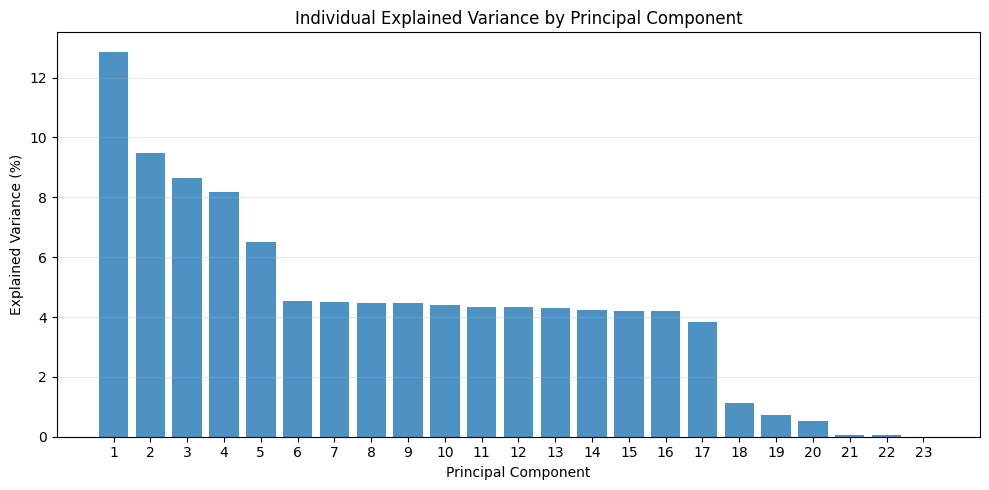

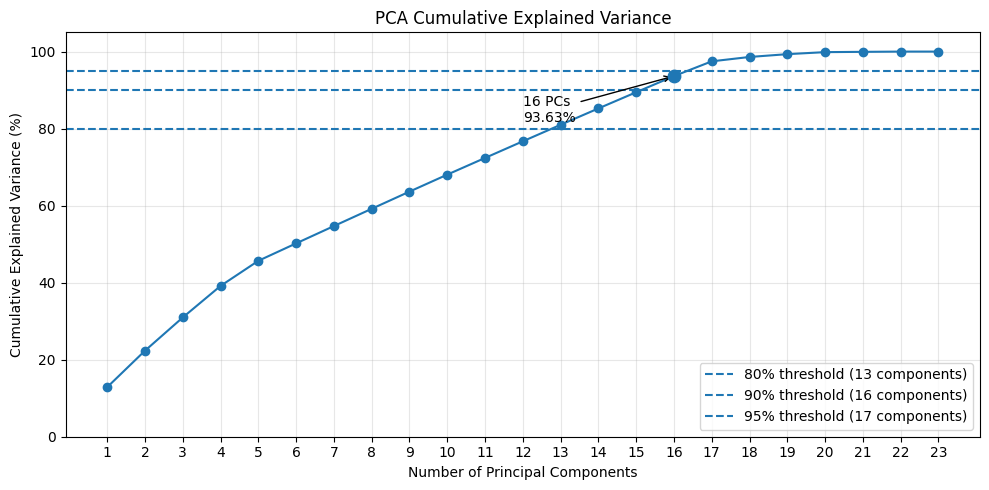

PCA COMPONENT SELECTION
--------------------------------------------------
Original numerical dimensions : 23
Selected components           : 16
Variance retained             : 93.63%
Dimensions removed            : 7
Dimensionality reduction      : 30.43%


In [78]:
# ============================================================
# 3.4 PCA Explained Variance Visualisation
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

component_numbers = np.arange(
    1,
    len(explained_variance) + 1
)

# ------------------------------------------------------------
# Plot 1: Individual explained variance
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(
    component_numbers,
    explained_variance * 100,
    alpha=0.8
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Individual Explained Variance by Principal Component")

plt.xticks(component_numbers)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot 2: Cumulative explained variance
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    component_numbers,
    cumulative_variance * 100,
    marker="o"
)

# Reference thresholds
plt.axhline(
    y=80,
    linestyle="--",
    label=f"80% threshold ({components_80} components)"
)

plt.axhline(
    y=90,
    linestyle="--",
    label=f"90% threshold ({components_90} components)"
)

plt.axhline(
    y=95,
    linestyle="--",
    label=f"95% threshold ({components_95} components)"
)

# Mark selected 90% solution
selected_components = components_90

selected_variance = (
    cumulative_variance[selected_components - 1] * 100
)

plt.scatter(
    selected_components,
    selected_variance,
    s=80,
    zorder=5
)

plt.annotate(
    f"{selected_components} PCs\n"
    f"{selected_variance:.2f}%",
    xy=(
        selected_components,
        selected_variance
    ),
    xytext=(
        selected_components - 4,
        selected_variance - 12
    ),
    arrowprops=dict(
        arrowstyle="->"
    )
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA Cumulative Explained Variance")

plt.xticks(component_numbers)

plt.ylim(0, 105)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Selection summary
# ------------------------------------------------------------

reduction_percent = (
    (len(pca_features) - selected_components)
    / len(pca_features)
    * 100
)

print("PCA COMPONENT SELECTION")
print("-" * 50)

print(
    f"Original numerical dimensions : "
    f"{len(pca_features)}"
)

print(
    f"Selected components           : "
    f"{selected_components}"
)

print(
    f"Variance retained             : "
    f"{selected_variance:.2f}%"
)

print(
    f"Dimensions removed            : "
    f"{len(pca_features) - selected_components}"
)

print(
    f"Dimensionality reduction      : "
    f"{reduction_percent:.2f}%"
)

## 3.5 PCA Transformation, Component Loadings and Data Obfuscation

Based on the explained-variance analysis, 16 principal components are retained. This representation preserves 93.63% of the variance contained within the 23 selected numerical attributes while reducing dimensionality by 30.43%.

The PCA transformation replaces directly interpretable numerical attributes with principal components. Each principal component represents a weighted linear combination of multiple standardised original variables. Consequently, values such as income, age, credit score and loan amount are no longer directly represented as individual columns in the transformed dataset.

Component loadings are examined to identify which original attributes contribute most strongly to the principal components. This also demonstrates that each component combines information from multiple attributes rather than corresponding directly to a single original variable.

PCA provides data obfuscation by reducing the direct interpretability of individual attributes; however, it should not be considered complete anonymisation because the original information may potentially be approximated if the PCA transformation parameters are available.

In [79]:
# ============================================================
# 3.5 PCA Transformation, Loadings and Obfuscation
# ============================================================

from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Fit selected PCA model
# Training data only
# ------------------------------------------------------------

selected_components = components_90

pca_selected = PCA(
    n_components=selected_components
)

X_train_pca_selected = pca_selected.fit_transform(
    X_train_pca_scaled
)

X_test_pca_selected = pca_selected.transform(
    X_test_pca_scaled
)

# ------------------------------------------------------------
# Create interpretable PCA column names
# ------------------------------------------------------------

pca_column_names = [
    f"PC{i}"
    for i in range(1, selected_components + 1)
]

X_train_pca_df = pd.DataFrame(
    X_train_pca_selected,
    columns=pca_column_names,
    index=X_train_pca_input.index
)

X_test_pca_df = pd.DataFrame(
    X_test_pca_selected,
    columns=pca_column_names,
    index=X_test_pca_input.index
)

# ------------------------------------------------------------
# PCA component loadings
# ------------------------------------------------------------

pca_loadings = pd.DataFrame(
    pca_selected.components_.T,
    index=pca_features,
    columns=pca_column_names
)

# Absolute loadings are useful for identifying
# strongest contributors regardless of direction.
absolute_loadings = pca_loadings.abs()

# Top contributors to first five PCs
loading_records = []

for component in pca_column_names[:5]:

    top_features = (
        absolute_loadings[component]
        .sort_values(ascending=False)
        .head(5)
        .index
    )

    for rank, feature in enumerate(
        top_features,
        start=1
    ):

        loading_records.append({
            "Principal_Component": component,
            "Rank": rank,
            "Original_Variable": feature,
            "Loading": pca_loadings.loc[
                feature,
                component
            ],
            "Absolute_Loading": absolute_loadings.loc[
                feature,
                component
            ]
        })

top_loading_summary = pd.DataFrame(
    loading_records
)

# ------------------------------------------------------------
# Transformation validation
# ------------------------------------------------------------

variance_retained_selected = (
    pca_selected.explained_variance_ratio_.sum()
    * 100
)

reduction_selected = (
    1 -
    selected_components / len(pca_features)
) * 100

train_pca_finite = np.isfinite(
    X_train_pca_selected
).all()

test_pca_finite = np.isfinite(
    X_test_pca_selected
).all()

# Check whether original variable names remain
original_names_exposed = any(
    column in pca_features
    for column in X_train_pca_df.columns
)

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print("PCA TRANSFORMATION AND OBFUSCATION")
print("-" * 55)

print(
    f"Original numerical dimensions : "
    f"{len(pca_features)}"
)

print(
    f"PCA dimensions retained       : "
    f"{selected_components}"
)

print(
    f"Variance retained             : "
    f"{variance_retained_selected:.2f}%"
)

print(
    f"Dimensionality reduction      : "
    f"{reduction_selected:.2f}%"
)

print(
    f"Training PCA shape            : "
    f"{X_train_pca_df.shape}"
)

print(
    f"Test PCA shape                : "
    f"{X_test_pca_df.shape}"
)

print(
    f"Training values finite        : "
    f"{train_pca_finite}"
)

print(
    f"Test values finite            : "
    f"{test_pca_finite}"
)

print(
    f"Original names exposed in PCA : "
    f"{original_names_exposed}"
)

# ------------------------------------------------------------
# Display original vs transformed representation
# ------------------------------------------------------------

print("\nORIGINAL NUMERICAL REPRESENTATION")
print("-" * 55)

display(
    X_train_pca_input[
        [
            "AnnualIncome",
            "Age",
            "CreditScore",
            "LoanAmount",
            "NetWorth"
        ]
    ]
    .head()
    .round(2)
)

print("\nPCA-TRANSFORMED REPRESENTATION")
print("-" * 55)

display(
    X_train_pca_df
    .head()
    .round(3)
)

# ------------------------------------------------------------
# Display top PCA contributors
# ------------------------------------------------------------

print("\nTOP CONTRIBUTORS TO FIRST FIVE PRINCIPAL COMPONENTS")
print("-" * 55)

display(
    top_loading_summary
    .round(3)
)

PCA TRANSFORMATION AND OBFUSCATION
-------------------------------------------------------
Original numerical dimensions : 23
PCA dimensions retained       : 16
Variance retained             : 93.63%
Dimensionality reduction      : 30.43%
Training PCA shape            : (16000, 16)
Test PCA shape                : (4000, 16)
Training values finite        : True
Test values finite            : True
Original names exposed in PCA : False

ORIGINAL NUMERICAL REPRESENTATION
-------------------------------------------------------


Variable,AnnualIncome,Age,CreditScore,LoanAmount,NetWorth
15234,34402.0,50,504,16368.0,55103.0
15766,51561.0,39,612,24926.0,32198.0
16912,119497.0,23,440,28380.0,180080.0
12481,28425.0,38,616,9736.0,10354.0
1572,55821.0,43,596,33557.0,3196.0



PCA-TRANSFORMED REPRESENTATION
-------------------------------------------------------


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
15234,0.029,0.001,-0.203,-0.861,0.769,0.336,-0.599,-0.836,1.280,-0.553,0.026,0.400,0.835,-0.559,0.221,-0.411
15766,-0.105,-0.568,-0.258,-0.340,0.821,0.898,-0.185,0.944,-0.839,0.436,0.252,-1.347,-1.111,-0.486,0.340,0.494
16912,0.368,-3.570,1.752,2.970,0.775,-0.566,-0.305,-0.254,-0.277,0.246,-0.440,-1.214,1.215,-0.396,1.670,-0.583
12481,-0.355,-0.986,-0.788,-1.895,0.293,1.670,-1.065,0.552,-0.521,-0.840,0.878,0.202,-0.585,0.701,-0.160,1.504
1572,-0.112,0.770,-0.955,0.225,0.205,-0.040,-0.828,-0.023,-0.812,0.401,0.171,0.322,-1.074,-0.290,-0.890,-1.249



TOP CONTRIBUTORS TO FIRST FIVE PRINCIPAL COMPONENTS
-------------------------------------------------------


,Principal_Component,Rank,Original_Variable,Loading,Absolute_Loading
0,PC1,1,TotalDebtToIncomeRatio,0.443,0.443
1,PC1,2,MonthlyIncome,-0.407,0.407
2,PC1,3,AnnualIncome,-0.407,0.407
3,PC1,4,Experience,-0.319,0.319
4,PC1,5,Age,-0.318,0.318
5,PC2,1,Experience,0.425,0.425
6,PC2,2,Age,0.423,0.423
7,PC2,3,MonthlyLoanPayment,0.404,0.404
8,PC2,4,TotalDebtToIncomeRatio,0.322,0.322
9,PC2,5,LoanDuration,-0.313,0.313


### Interpretation of PCA Transformation

The selected PCA representation reduced the 23 numerical attributes to 16 principal components while retaining 93.63% of the original variance, corresponding to a 30.43% reduction in dimensionality. The transformed training and test matrices contained only finite values and maintained consistent dimensions.

The component-loading analysis demonstrates that the principal components combine information from several original variables. For example, PC1 is influenced strongly by TotalDebtToIncomeRatio, MonthlyIncome, AnnualIncome, Experience and Age, while PC3 is dominated by NetWorth and TotalAssets. PC4 primarily combines income and loan-related characteristics, whereas PC5 is influenced by LoanDuration, InterestRate, Age and Experience.

The transformed representation replaces directly interpretable attributes such as AnnualIncome, Age, CreditScore and LoanAmount with generic component labels (PC1–PC16). Therefore, an observer of the transformed dataset cannot directly identify individual original attributes from the column names or values alone. This demonstrates the use of PCA as a form of data obfuscation while simultaneously reducing dimensionality.

However, PCA does not provide irreversible anonymisation. If the fitted scaling parameters, PCA loadings and sufficient component information are available, aspects of the original data may potentially be reconstructed. PCA is therefore treated here as a dimensionality-reduction and obfuscation technique rather than a complete privacy mechanism.

## 3.6 Baseline Logistic Regression Model

Logistic Regression is used as the supervised classification model because the target variable, "LoanApproved", is binary, with 0 representing a rejected application and 1 representing an approved application.

The baseline model is trained using the final preprocessed training feature matrix produced in Task 2. No class weighting or hyperparameter optimisation is applied at this stage so that the model provides a clear reference point for subsequent improvement.

Performance is evaluated on the previously separated test dataset using accuracy, precision, recall, F1-score, ROC-AUC and the confusion matrix. Because the dataset is imbalanced, with approximately 76.1% rejected and 23.9% approved applications, accuracy is interpreted alongside precision, recall and F1-score rather than being considered independently.

In [80]:
# ============================================================
# 3.6 Baseline Logistic Regression
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Define baseline Logistic Regression
# ------------------------------------------------------------

baseline_logistic = LogisticRegression(
    max_iter=2000,
    random_state=42
)


# ------------------------------------------------------------
# Train model
# ------------------------------------------------------------

baseline_logistic.fit(
    X_train_final,
    y_train
)


# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

y_pred_baseline = baseline_logistic.predict(
    X_test_final
)

y_prob_baseline = baseline_logistic.predict_proba(
    X_test_final
)[:, 1]


# ------------------------------------------------------------
# Calculate evaluation metrics
# ------------------------------------------------------------

baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

baseline_precision = precision_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_roc_auc = roc_auc_score(
    y_test,
    y_prob_baseline
)


# ------------------------------------------------------------
# Store metric summary
# ------------------------------------------------------------

baseline_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc
    ]
})


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

baseline_cm = confusion_matrix(
    y_test,
    y_pred_baseline
)

tn, fp, fn, tp = baseline_cm.ravel()


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print("BASELINE LOGISTIC REGRESSION")
print("-" * 55)

print(f"Training observations : {X_train_final.shape[0]}")
print(f"Test observations     : {X_test_final.shape[0]}")
print(f"Input features        : {X_train_final.shape[1]}")

print("\nBASELINE PERFORMANCE")
print("-" * 55)

display(
    baseline_metrics.assign(
        Score=baseline_metrics["Score"].round(4)
    )
)

print("\nCONFUSION MATRIX")
print("-" * 55)

baseline_cm_df = pd.DataFrame(
    baseline_cm,
    index=[
        "Actual Rejected (0)",
        "Actual Approved (1)"
    ],
    columns=[
        "Predicted Rejected (0)",
        "Predicted Approved (1)"
    ]
)

display(baseline_cm_df)

print("\nCONFUSION MATRIX COUNTS")
print("-" * 55)

print(f"True Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Positives  : {tp}")


# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nCLASSIFICATION REPORT")
print("-" * 55)

print(
    classification_report(
        y_test,
        y_pred_baseline,
        target_names=[
            "Rejected",
            "Approved"
        ],
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

assert len(y_pred_baseline) == len(y_test)
assert len(y_prob_baseline) == len(y_test)
assert np.isfinite(y_prob_baseline).all()

print("Baseline model evaluation completed successfully.")

BASELINE LOGISTIC REGRESSION
-------------------------------------------------------
Training observations : 16000
Test observations     : 4000
Input features        : 53

BASELINE PERFORMANCE
-------------------------------------------------------


,Metric,Score
0,Accuracy,0.9950
1,Precision,0.9906
2,Recall,0.9885
3,F1 Score,0.9895
4,ROC-AUC,0.9999



CONFUSION MATRIX
-------------------------------------------------------


,Predicted Rejected (0),Predicted Approved (1)
Actual Rejected (0),3035,9
Actual Approved (1),11,945



CONFUSION MATRIX COUNTS
-------------------------------------------------------
True Negatives  : 3035
False Positives : 9
False Negatives : 11
True Positives  : 945

CLASSIFICATION REPORT
-------------------------------------------------------
              precision    recall  f1-score   support

    Rejected     0.9964    0.9970    0.9967      3044
    Approved     0.9906    0.9885    0.9895       956

    accuracy                         0.9950      4000
   macro avg     0.9935    0.9928    0.9931      4000
weighted avg     0.9950    0.9950    0.9950      4000

Baseline model evaluation completed successfully.


## 3.7 Baseline Model Integrity and Target-Leakage Audit

The baseline Logistic Regression produced exceptionally high predictive performance. Although this may indicate strong predictive relationships within the dataset, unusually high classification performance can also result from target leakage, where information directly or indirectly derived from the target variable becomes available to the model.

Before interpreting or attempting to improve the model, the transformed feature set is therefore audited for potential target leakage. Feature names and Logistic Regression coefficients are examined to identify variables with unusually strong predictive influence. The training and test separation is also reconfirmed.

In [81]:
# ============================================================
# 3.7 Baseline Model Integrity and Target-Leakage Audit
# ============================================================

import pandas as pd
import numpy as np

print("BASELINE MODEL INTEGRITY AUDIT")
print("-" * 60)


# ------------------------------------------------------------
# 1. Confirm target is not directly included
# ------------------------------------------------------------

target_like_terms = [
    "LoanApproved",
    "Approved",
    "Approval",
    "Target",
    "Outcome"
]

suspicious_feature_names = [
    feature
    for feature in final_feature_names
    if any(
        term.lower() in str(feature).lower()
        for term in target_like_terms
    )
]

print("TARGET-NAME AUDIT")
print("-" * 60)

print(
    f"Transformed features examined : "
    f"{len(final_feature_names)}"
)

print(
    f"Target-like feature names     : "
    f"{suspicious_feature_names}"
)


# ------------------------------------------------------------
# 2. Examine Logistic Regression coefficients
# ------------------------------------------------------------

coefficient_audit = pd.DataFrame({
    "Feature": final_feature_names,
    "Coefficient":
        baseline_logistic.coef_[0]
})

coefficient_audit["Absolute_Coefficient"] = (
    coefficient_audit["Coefficient"].abs()
)

coefficient_audit = (
    coefficient_audit
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTOP 20 LOGISTIC REGRESSION COEFFICIENTS")
print("-" * 60)

display(
    coefficient_audit
    .head(20)
    .round(4)
)


# ------------------------------------------------------------
# 3. Reconfirm train/test separation
# ------------------------------------------------------------

index_overlap = len(
    set(X_train_financial.index)
    .intersection(
        set(X_test_financial.index)
    )
)

print("\nTRAIN/TEST SEPARATION")
print("-" * 60)

print(
    f"Training observations : "
    f"{len(X_train_financial)}"
)

print(
    f"Test observations     : "
    f"{len(X_test_financial)}"
)

print(
    f"Index overlap         : "
    f"{index_overlap}"
)


# ------------------------------------------------------------
# 4. Compare performance against majority-class baseline
# ------------------------------------------------------------

majority_class = (
    pd.Series(y_train)
    .mode()
    .iloc[0]
)

majority_predictions = np.full(
    len(y_test),
    majority_class
)

majority_accuracy = (
    np.mean(
        majority_predictions ==
        np.asarray(y_test)
    )
)

print("\nMAJORITY-CLASS REFERENCE")
print("-" * 60)

print(
    f"Majority class               : "
    f"{majority_class}"
)

print(
    f"Majority baseline accuracy   : "
    f"{majority_accuracy:.4f}"
)

print(
    f"Logistic Regression accuracy : "
    f"{baseline_accuracy:.4f}"
)

print(
    f"Accuracy improvement         : "
    f"{baseline_accuracy - majority_accuracy:.4f}"
)


# ------------------------------------------------------------
# 5. Validation
# ------------------------------------------------------------

assert index_overlap == 0, (
    "Training/test index overlap detected."
)

assert len(suspicious_feature_names) == 0, (
    "Potential target-like feature detected."
)

assert len(final_feature_names) == X_train_final.shape[1]

print("\nNo direct target-name or partition leakage detected.")

BASELINE MODEL INTEGRITY AUDIT
------------------------------------------------------------
TARGET-NAME AUDIT
------------------------------------------------------------
Transformed features examined : 53
Target-like feature names     : []

TOP 20 LOGISTIC REGRESSION COEFFICIENTS
------------------------------------------------------------


,Feature,Coefficient,Absolute_Coefficient
0,numerical__RiskScore,-7.8226,7.8226
1,binary__BankruptcyHistory,4.4694,4.4694
2,numerical__InterestRate,-3.1873,3.1873
3,binary__PreviousLoanDefaults,2.5445,2.5445
4,numerical__CreditScore,-2.5215,2.5215
5,numerical__TotalDebtToIncomeRatio,-2.1368,2.1368
6,categorical__EmploymentStatus_Employed,-1.8397,1.8397
7,numerical__AnnualIncome,1.4437,1.4437
8,numerical__MonthlyIncome,1.4437,1.4437
9,categorical__EducationLevel_High School,-1.4146,1.4146



TRAIN/TEST SEPARATION
------------------------------------------------------------
Training observations : 16000
Test observations     : 4000
Index overlap         : 0

MAJORITY-CLASS REFERENCE
------------------------------------------------------------
Majority class               : 0
Majority baseline accuracy   : 0.7610
Logistic Regression accuracy : 0.9950
Accuracy improvement         : 0.2340

No direct target-name or partition leakage detected.


## 3.8 RiskScore Sensitivity Analysis

The baseline model integrity audit identified "RiskScore" as the feature with the largest absolute Logistic Regression coefficient. Although no direct target leakage or training/test overlap was detected, the unusually strong influence of this variable warrants further investigation.

A sensitivity analysis is therefore performed by retraining the same baseline Logistic Regression model after excluding "RiskScore". Performance with and without this feature is compared using accuracy, precision, recall, F1-score and ROC-AUC.

This analysis helps determine whether the near-perfect baseline performance is primarily dependent on "RiskScore" or whether strong predictive information is distributed across multiple applicant characteristics. This is a diagnostic robustness check rather than the final model-improvement stage.

In [83]:
# ============================================================
# 3.8 RiskScore Sensitivity Analysis
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Identify RiskScore in transformed feature matrix
# ------------------------------------------------------------

risk_feature_name = "numerical__RiskScore"

assert risk_feature_name in final_feature_names, (
    f"{risk_feature_name} was not found in final_feature_names."
)

risk_feature_index = np.where(
    final_feature_names == risk_feature_name
)[0][0]

print("RISKSCORE SENSITIVITY ANALYSIS")
print("-" * 60)

print(
    f"RiskScore transformed feature : "
    f"{risk_feature_name}"
)

print(
    f"RiskScore feature position    : "
    f"{risk_feature_index}"
)


# ------------------------------------------------------------
# Remove RiskScore from train/test matrices
# ------------------------------------------------------------

X_train_without_risk = np.delete(
    np.asarray(X_train_final),
    risk_feature_index,
    axis=1
)

X_test_without_risk = np.delete(
    np.asarray(X_test_final),
    risk_feature_index,
    axis=1
)

features_without_risk = final_feature_names[
    final_feature_names != risk_feature_name
]

print(
    f"\nOriginal feature count        : "
    f"{X_train_final.shape[1]}"
)

print(
    f"Feature count without RiskScore: "
    f"{X_train_without_risk.shape[1]}"
)


# ------------------------------------------------------------
# Train identical Logistic Regression without RiskScore
# ------------------------------------------------------------

logistic_without_risk = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_without_risk.fit(
    X_train_without_risk,
    y_train
)


# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_pred_without_risk = (
    logistic_without_risk.predict(
        X_test_without_risk
    )
)

y_prob_without_risk = (
    logistic_without_risk.predict_proba(
        X_test_without_risk
    )[:, 1]
)


# ------------------------------------------------------------
# Performance metrics
# ------------------------------------------------------------

without_risk_accuracy = accuracy_score(
    y_test,
    y_pred_without_risk
)

without_risk_precision = precision_score(
    y_test,
    y_pred_without_risk,
    zero_division=0
)

without_risk_recall = recall_score(
    y_test,
    y_pred_without_risk,
    zero_division=0
)

without_risk_f1 = f1_score(
    y_test,
    y_pred_without_risk,
    zero_division=0
)

without_risk_roc_auc = roc_auc_score(
    y_test,
    y_prob_without_risk
)


# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

risk_sensitivity_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "With_RiskScore": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc
    ],
    "Without_RiskScore": [
        without_risk_accuracy,
        without_risk_precision,
        without_risk_recall,
        without_risk_f1,
        without_risk_roc_auc
    ]
})

risk_sensitivity_comparison["Absolute_Change"] = (
    risk_sensitivity_comparison["Without_RiskScore"]
    - risk_sensitivity_comparison["With_RiskScore"]
)

print("\nPERFORMANCE SENSITIVITY TO RISKSCORE")
print("-" * 60)

display(
    risk_sensitivity_comparison.round(4)
)


# ------------------------------------------------------------
# Examine strongest coefficients after RiskScore removal
# ------------------------------------------------------------

without_risk_coefficients = pd.DataFrame({
    "Feature": features_without_risk,
    "Coefficient":
        logistic_without_risk.coef_[0]
})

without_risk_coefficients[
    "Absolute_Coefficient"
] = (
    without_risk_coefficients[
        "Coefficient"
    ].abs()
)

without_risk_coefficients = (
    without_risk_coefficients
    .sort_values(
        "Absolute_Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "\nTOP 15 COEFFICIENTS AFTER REMOVING RISKSCORE"
)

print("-" * 60)

display(
    without_risk_coefficients
    .head(15)
    .round(4)
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert (
    X_train_without_risk.shape[1]
    ==
    X_train_final.shape[1] - 1
)

assert (
    X_test_without_risk.shape[1]
    ==
    X_test_final.shape[1] - 1
)

assert (
    X_train_without_risk.shape[1]
    ==
    X_test_without_risk.shape[1]
)

assert np.isfinite(
    X_train_without_risk
).all()

assert np.isfinite(
    X_test_without_risk
).all()

print(
    "\nRiskScore sensitivity analysis "
    "completed successfully."
)

RISKSCORE SENSITIVITY ANALYSIS
------------------------------------------------------------
RiskScore transformed feature : numerical__RiskScore
RiskScore feature position    : 20

Original feature count        : 53
Feature count without RiskScore: 52

PERFORMANCE SENSITIVITY TO RISKSCORE
------------------------------------------------------------


,Metric,With_RiskScore,Without_RiskScore,Absolute_Change
0,Accuracy,0.9950,0.9660,-0.0290
1,Precision,0.9906,0.9343,-0.0562
2,Recall,0.9885,0.9226,-0.0659
3,F1 Score,0.9895,0.9284,-0.0611
4,ROC-AUC,0.9999,0.9942,-0.0057



TOP 15 COEFFICIENTS AFTER REMOVING RISKSCORE
------------------------------------------------------------


,Feature,Coefficient,Absolute_Coefficient
0,numerical__TotalDebtToIncomeRatio,-6.3027,6.3027
1,binary__BankruptcyHistory,-5.0480,5.0480
2,numerical__InterestRate,-4.3828,4.3828
3,binary__PreviousLoanDefaults,-3.1834,3.1834
4,binary__RiskScoreMissing,-2.8265,2.8265
5,categorical__EducationLevel_High School,-2.2440,2.2440
6,categorical__EducationLevel_Doctorate,2.1252,2.1252
7,numerical__CreditScore,-2.0883,2.0883
8,numerical__MonthlyIncome,2.0220,2.0220
9,numerical__AnnualIncome,2.0220,2.0220



RiskScore sensitivity analysis completed successfully.


### Interpretation

Removing "RiskScore" reduced test accuracy from 99.50% to 96.60%, recall from 98.85% to 92.26%, and F1-score from 98.95% to 92.84%, confirming that "RiskScore" is an influential predictor. However, ROC-AUC remained very high at 99.42%, indicating that the remaining attributes still provide strong discrimination between approved and rejected applications.

After removing "RiskScore", the strongest model coefficients included "TotalDebtToIncomeRatio", "BankruptcyHistory", "InterestRate","PreviousLoanDefaults", "CreditScore", "MonthlyIncome", and "AnnualIncome". Therefore, the strong predictive performance is not dependent solely on "RiskScore", but reflects information distributed across several financial and applicant characteristics. "RiskScore` is retained for subsequent modelling because it is an available predictor in the supplied dataset and its missing values were explicitly addressed during preprocessing.

## 3.9 Random Forest Classification Model

A Random Forest classifier is developed as an alternative supervised classification algorithm for predicting "LoanApproved". Unlike Logistic Regression, which estimates a linear decision boundary, Random Forest combines multiple decision trees and can capture nonlinear relationships and interactions between applicant characteristics.

The model is initially trained using a standard configuration without hyperparameter optimisation. The same training and test partitions used for Logistic Regression are retained to ensure a fair comparison between the models.

Performance is evaluated using accuracy, precision, recall, F1-score and ROC-AUC. The results are compared with the baseline Logistic Regression model to determine whether the more flexible tree-based approach provides improved predictive performance.

In [84]:
# ============================================================
# 3.9 Random Forest Classification Model
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Define Random Forest
# ------------------------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# Train Random Forest
# ------------------------------------------------------------

random_forest_model.fit(
    X_train_final,
    y_train
)


# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

y_pred_rf = random_forest_model.predict(
    X_test_final
)

y_prob_rf = random_forest_model.predict_proba(
    X_test_final
)[:, 1]


# ------------------------------------------------------------
# Calculate performance metrics
# ------------------------------------------------------------

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)


# ------------------------------------------------------------
# Random Forest performance table
# ------------------------------------------------------------

rf_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

print("RANDOM FOREST CLASSIFICATION MODEL")
print("-" * 60)

print(
    f"Training observations : "
    f"{X_train_final.shape[0]}"
)

print(
    f"Test observations     : "
    f"{X_test_final.shape[0]}"
)

print(
    f"Input features        : "
    f"{X_train_final.shape[1]}"
)

print("\nRANDOM FOREST PERFORMANCE")
print("-" * 60)

display(
    rf_metrics.assign(
        Score=rf_metrics["Score"].round(4)
    )
)


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

rf_cm = confusion_matrix(
    y_test,
    y_pred_rf
)

rf_tn, rf_fp, rf_fn, rf_tp = rf_cm.ravel()

rf_cm_df = pd.DataFrame(
    rf_cm,
    index=[
        "Actual Rejected (0)",
        "Actual Approved (1)"
    ],
    columns=[
        "Predicted Rejected (0)",
        "Predicted Approved (1)"
    ]
)

print("\nRANDOM FOREST CONFUSION MATRIX")
print("-" * 60)

display(rf_cm_df)

print("\nCONFUSION MATRIX COUNTS")
print("-" * 60)

print(f"True Negatives  : {rf_tn}")
print(f"False Positives : {rf_fp}")
print(f"False Negatives : {rf_fn}")
print(f"True Positives  : {rf_tp}")


# ------------------------------------------------------------
# Classification report
# ------------------------------------------------------------

print("\nCLASSIFICATION REPORT")
print("-" * 60)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Rejected",
            "Approved"
        ],
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------
# Logistic Regression vs Random Forest
# ------------------------------------------------------------

model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Logistic_Regression": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc
    ],

    "Random_Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

model_comparison["Difference_RF_minus_LR"] = (
    model_comparison["Random_Forest"]
    -
    model_comparison["Logistic_Regression"]
)


print("\nMODEL PERFORMANCE COMPARISON")
print("-" * 60)

display(
    model_comparison.round(4)
)


# ------------------------------------------------------------
# Training accuracy for overfitting diagnostic
# ------------------------------------------------------------

rf_train_predictions = (
    random_forest_model.predict(
        X_train_final
    )
)

rf_train_accuracy = accuracy_score(
    y_train,
    rf_train_predictions
)

print("\nOVERFITTING DIAGNOSTIC")
print("-" * 60)

print(
    f"Random Forest training accuracy : "
    f"{rf_train_accuracy:.4f}"
)

print(
    f"Random Forest test accuracy     : "
    f"{rf_accuracy:.4f}"
)

print(
    f"Train-test accuracy gap         : "
    f"{rf_train_accuracy - rf_accuracy:.4f}"
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(y_pred_rf) == len(y_test)
assert len(y_prob_rf) == len(y_test)

assert np.isfinite(
    y_prob_rf
).all()

assert (
    random_forest_model.n_features_in_
    ==
    X_train_final.shape[1]
)

print(
    "\nRandom Forest evaluation "
    "completed successfully."
)


RANDOM FOREST CLASSIFICATION MODEL
------------------------------------------------------------
Training observations : 16000
Test observations     : 4000
Input features        : 53

RANDOM FOREST PERFORMANCE
------------------------------------------------------------


,Metric,Score
0,Accuracy,0.9872
1,Precision,0.9799
2,Recall,0.9665
3,F1 Score,0.9731
4,ROC-AUC,0.9989



RANDOM FOREST CONFUSION MATRIX
------------------------------------------------------------


,Predicted Rejected (0),Predicted Approved (1)
Actual Rejected (0),3025,19
Actual Approved (1),32,924



CONFUSION MATRIX COUNTS
------------------------------------------------------------
True Negatives  : 3025
False Positives : 19
False Negatives : 32
True Positives  : 924

CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

    Rejected     0.9895    0.9938    0.9916      3044
    Approved     0.9799    0.9665    0.9731       956

    accuracy                         0.9872      4000
   macro avg     0.9847    0.9801    0.9824      4000
weighted avg     0.9872    0.9872    0.9872      4000


MODEL PERFORMANCE COMPARISON
------------------------------------------------------------


,Metric,Logistic_Regression,Random_Forest,Difference_RF_minus_LR
0,Accuracy,0.9950,0.9872,-0.0078
1,Precision,0.9906,0.9799,-0.0107
2,Recall,0.9885,0.9665,-0.0220
3,F1 Score,0.9895,0.9731,-0.0164
4,ROC-AUC,0.9999,0.9989,-0.0010



OVERFITTING DIAGNOSTIC
------------------------------------------------------------
Random Forest training accuracy : 1.0000
Random Forest test accuracy     : 0.9872
Train-test accuracy gap         : 0.0128

Random Forest evaluation completed successfully.


### Interpretation

The Random Forest classifier achieved strong predictive performance, with 98.72% accuracy, 97.99% precision, 96.65% recall, 97.31% F1-score and a ROC-AUC of 99.89%. The confusion matrix shows that 3,025 rejected and 924 approved applications were classified correctly, while 19 false positives and 32 false negatives occurred.

When compared with the baseline Logistic Regression model, Random Forest produced slightly lower performance across all evaluation measures. Logistic Regression achieved 99.50% accuracy and a 98.95% F1-score, compared with 98.72% and 97.31% respectively for Random Forest. Therefore, the additional nonlinear modelling flexibility of Random Forest did not improve predictive performance on this dataset.

The Random Forest achieved 100% training accuracy compared with 98.72% test accuracy, producing a train-test accuracy gap of 1.28 percentage points. This indicates some overfitting, as the ensemble fitted the training observations perfectly but generalised slightly less effectively to unseen test observations. Nevertheless, its test performance remained very high.

Overall, Logistic Regression is currently the stronger classification model because it provides higher test performance while also being simpler and more interpretable.

## 3.10 Stratified Cross-Validation Model Comparison

The previous model comparison evaluated Logistic Regression and Random Forest using a single training-test partition. To assess whether their performance is stable across different subsets of the data, stratified 5-fold cross-validation is applied to the training partition.

Stratification preserves the proportion of approved and rejected applications within each fold, which is important because the target variable is imbalanced. The independent test partition is not used during cross-validation and remains reserved for final model evaluation.

Accuracy, precision, recall, F1-score and ROC-AUC are evaluated for both classifiers. Mean scores and standard deviations across the five folds are compared to assess both predictive performance and stability.

In [85]:
# ============================================================
# 3.10 Stratified Cross-Validation Model Comparison
# ============================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Define stratified cross-validation strategy
# ------------------------------------------------------------

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# Define fresh model instances
# ------------------------------------------------------------

cv_logistic = LogisticRegression(
    max_iter=2000,
    random_state=42
)

cv_random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


# ------------------------------------------------------------
# Define evaluation metrics
# ------------------------------------------------------------

scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


# ------------------------------------------------------------
# Logistic Regression cross-validation
# ------------------------------------------------------------

print("STRATIFIED CROSS-VALIDATION MODEL COMPARISON")
print("-" * 65)

print("Running Logistic Regression cross-validation...")

logistic_cv_results = cross_validate(
    cv_logistic,
    X_train_final,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=False,
    n_jobs=-1
)


# ------------------------------------------------------------
# Random Forest cross-validation
# ------------------------------------------------------------

print("Running Random Forest cross-validation...")

rf_cv_results = cross_validate(
    cv_random_forest,
    X_train_final,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    return_train_score=False,
    n_jobs=-1
)


# ------------------------------------------------------------
# Individual fold results
# ------------------------------------------------------------

fold_results = pd.DataFrame({
    "Fold": np.arange(1, 6),

    "LR_Accuracy":
        logistic_cv_results["test_accuracy"],

    "LR_Precision":
        logistic_cv_results["test_precision"],

    "LR_Recall":
        logistic_cv_results["test_recall"],

    "LR_F1":
        logistic_cv_results["test_f1"],

    "LR_ROC_AUC":
        logistic_cv_results["test_roc_auc"],

    "RF_Accuracy":
        rf_cv_results["test_accuracy"],

    "RF_Precision":
        rf_cv_results["test_precision"],

    "RF_Recall":
        rf_cv_results["test_recall"],

    "RF_F1":
        rf_cv_results["test_f1"],

    "RF_ROC_AUC":
        rf_cv_results["test_roc_auc"]
})


print("\nFOLD-BY-FOLD PERFORMANCE")
print("-" * 65)

display(
    fold_results.round(4)
)


# ------------------------------------------------------------
# Summarise mean and standard deviation
# ------------------------------------------------------------

metric_mapping = {
    "Accuracy": "test_accuracy",
    "Precision": "test_precision",
    "Recall": "test_recall",
    "F1 Score": "test_f1",
    "ROC-AUC": "test_roc_auc"
}

summary_records = []

for metric_name, result_key in metric_mapping.items():

    lr_scores = logistic_cv_results[result_key]
    rf_scores = rf_cv_results[result_key]

    summary_records.append({
        "Metric": metric_name,

        "LR_Mean":
            lr_scores.mean(),

        "LR_Std":
            lr_scores.std(),

        "RF_Mean":
            rf_scores.mean(),

        "RF_Std":
            rf_scores.std(),

        "Mean_Difference_RF_minus_LR":
            rf_scores.mean() - lr_scores.mean()
    })


cv_model_comparison = pd.DataFrame(
    summary_records
)


print("\n5-FOLD CROSS-VALIDATION SUMMARY")
print("-" * 65)

display(
    cv_model_comparison.round(4)
)


# ------------------------------------------------------------
# Overall accuracy stability
# ------------------------------------------------------------

lr_accuracy_mean = (
    logistic_cv_results[
        "test_accuracy"
    ].mean()
)

lr_accuracy_std = (
    logistic_cv_results[
        "test_accuracy"
    ].std()
)

rf_accuracy_mean = (
    rf_cv_results[
        "test_accuracy"
    ].mean()
)

rf_accuracy_std = (
    rf_cv_results[
        "test_accuracy"
    ].std()
)


print("\nMODEL STABILITY SUMMARY")
print("-" * 65)

print(
    f"Logistic Regression accuracy : "
    f"{lr_accuracy_mean:.4f} "
    f"+/- {lr_accuracy_std:.4f}"
)

print(
    f"Random Forest accuracy       : "
    f"{rf_accuracy_mean:.4f} "
    f"+/- {rf_accuracy_std:.4f}"
)


# ------------------------------------------------------------
# Identify stronger model by mean CV accuracy
# ------------------------------------------------------------

if lr_accuracy_mean > rf_accuracy_mean:

    cv_best_model = "Logistic Regression"

elif rf_accuracy_mean > lr_accuracy_mean:

    cv_best_model = "Random Forest"

else:

    cv_best_model = "Equal performance"


print(
    f"\nHigher mean CV accuracy      : "
    f"{cv_best_model}"
)


# ------------------------------------------------------------
# Confirm independent test set remains separate
# ------------------------------------------------------------

print("\nVALIDATION DESIGN")
print("-" * 65)

print(
    f"Cross-validation observations : "
    f"{X_train_final.shape[0]}"
)

print(
    f"Independent test observations : "
    f"{X_test_final.shape[0]}"
)

print(
    "Independent test set used in CV: False"
)


# ------------------------------------------------------------
# Validation checks
# ------------------------------------------------------------

assert len(
    logistic_cv_results["test_accuracy"]
) == 5

assert len(
    rf_cv_results["test_accuracy"]
) == 5

assert np.isfinite(
    logistic_cv_results["test_accuracy"]
).all()

assert np.isfinite(
    rf_cv_results["test_accuracy"]
).all()

assert (
    X_train_final.shape[0]
    ==
    len(y_train)
)

print(
    "\nStratified cross-validation "
    "completed successfully."
)

STRATIFIED CROSS-VALIDATION MODEL COMPARISON
-----------------------------------------------------------------
Running Logistic Regression cross-validation...
Running Random Forest cross-validation...

FOLD-BY-FOLD PERFORMANCE
-----------------------------------------------------------------


,Fold,LR_Accuracy,LR_Precision,LR_Recall,LR_F1,LR_ROC_AUC,RF_Accuracy,RF_Precision,RF_Recall,RF_F1,RF_ROC_AUC
0,1,0.9966,0.9909,0.9948,0.9928,0.9999,0.9847,0.9748,0.9607,0.9677,0.9988
1,2,0.9938,0.9882,0.9856,0.9869,0.9997,0.9859,0.9762,0.9647,0.9704,0.9989
2,3,0.9966,0.9883,0.9974,0.9928,0.9998,0.9853,0.9761,0.9621,0.9691,0.9987
3,4,0.9953,0.9934,0.9869,0.9902,0.9998,0.9859,0.9787,0.9621,0.9703,0.9985
4,5,0.9953,0.9947,0.9856,0.9902,0.9994,0.9897,0.9893,0.9673,0.9782,0.9994



5-FOLD CROSS-VALIDATION SUMMARY
-----------------------------------------------------------------


,Metric,LR_Mean,LR_Std,RF_Mean,RF_Std,Mean_Difference_RF_minus_LR
0,Accuracy,0.9955,0.0010,0.9863,0.0018,-0.0092
1,Precision,0.9911,0.0026,0.9790,0.0053,-0.0121
2,Recall,0.9901,0.0050,0.9634,0.0023,-0.0267
3,F1 Score,0.9906,0.0022,0.9711,0.0037,-0.0194
4,ROC-AUC,0.9997,0.0002,0.9988,0.0003,-0.0009



MODEL STABILITY SUMMARY
-----------------------------------------------------------------
Logistic Regression accuracy : 0.9955 +/- 0.0010
Random Forest accuracy       : 0.9863 +/- 0.0018

Higher mean CV accuracy      : Logistic Regression

VALIDATION DESIGN
-----------------------------------------------------------------
Cross-validation observations : 16000
Independent test observations : 4000
Independent test set used in CV: False

Stratified cross-validation completed successfully.


### Interpretation

The 5-fold stratified cross-validation results confirm that Logistic Regression provides consistently stronger classification performance than Random Forest. Logistic Regression achieved a mean accuracy of 99.55% with a standard deviation of only 0.10 percentage points, compared with 98.63% for Random Forest.

Logistic Regression also achieved higher mean precision (99.11%), recall (99.01%), F1-score (99.06%) and ROC-AUC (99.97%). The low variation between folds indicates that its performance is stable across different subsets of the training data rather than being dependent on a favourable single partition.

Random Forest also demonstrated strong predictive performance, but its lower recall and F1-score indicate that it was less effective at identifying approved applications than Logistic Regression. These cross-validation results therefore support Logistic Regression as the preferred classification model for subsequent optimisation and final evaluation.

The independent 4,000-observation test partition was excluded from the cross-validation procedure and remains reserved for final model assessment.

## 3.11 Logistic Regression Hyperparameter Optimisation

The baseline and cross-validation results identified Logistic Regression as the strongest classification model. To investigate whether its performance can be further improved, the regularisation strength is optimised using stratified cross-validation on the training data.

The inverse regularisation parameter "C" controls the degree of coefficient shrinkage applied by Logistic Regression. Smaller values impose stronger regularisation, while larger values permit more flexible coefficient estimates. A grid of candidate "C" values is evaluated using 5-fold stratified cross-validation.

Model selection is based on mean F1-score because the target distribution is imbalanced and F1 balances both precision and recall. The held-out test set is not used during hyperparameter selection.

In [86]:
# ============================================================
# 3.11 Logistic Regression Hyperparameter Optimisation
# ============================================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Cross-validation strategy
# ------------------------------------------------------------

tuning_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# Baseline Logistic Regression estimator
# ------------------------------------------------------------

logistic_for_tuning = LogisticRegression(
    max_iter=3000,
    random_state=42
)


# ------------------------------------------------------------
# Hyperparameter search space
# ------------------------------------------------------------

parameter_grid = {
    "C": [
        0.001,
        0.01,
        0.05,
        0.1,
        0.5,
        1,
        2,
        5,
        10,
        50,
        100
    ]
}


# ------------------------------------------------------------
# Grid search
# ------------------------------------------------------------

logistic_grid_search = GridSearchCV(
    estimator=logistic_for_tuning,
    param_grid=parameter_grid,
    scoring="f1",
    cv=tuning_cv,
    n_jobs=-1,
    return_train_score=True
)

print("LOGISTIC REGRESSION HYPERPARAMETER OPTIMISATION")
print("-" * 65)

logistic_grid_search.fit(
    X_train_final,
    y_train
)


# ------------------------------------------------------------
# Extract CV results
# ------------------------------------------------------------

tuning_results = pd.DataFrame(
    logistic_grid_search.cv_results_
)

tuning_summary = (
    tuning_results[
        [
            "param_C",
            "mean_train_score",
            "std_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
    .rename(
        columns={
            "param_C": "C",
            "mean_train_score": "Mean_Train_F1",
            "std_train_score": "Std_Train_F1",
            "mean_test_score": "Mean_CV_F1",
            "std_test_score": "Std_CV_F1",
            "rank_test_score": "Rank"
        }
    )
    .sort_values("Rank")
    .reset_index(drop=True)
)


print("\nHYPERPARAMETER SEARCH RESULTS")
print("-" * 65)

display(
    tuning_summary.round(4)
)


# ------------------------------------------------------------
# Best model
# ------------------------------------------------------------

best_logistic_model = (
    logistic_grid_search.best_estimator_
)

best_C = (
    logistic_grid_search.best_params_["C"]
)

best_cv_f1 = (
    logistic_grid_search.best_score_
)

print("\nBEST CROSS-VALIDATED CONFIGURATION")
print("-" * 65)

print(
    f"Best C value     : "
    f"{best_C}"
)

print(
    f"Best mean CV F1  : "
    f"{best_cv_f1:.4f}"
)


# ------------------------------------------------------------
# Evaluate tuned model on held-out test set
# ------------------------------------------------------------

y_pred_tuned = best_logistic_model.predict(
    X_test_final
)

y_prob_tuned = best_logistic_model.predict_proba(
    X_test_final
)[:, 1]

tuned_accuracy = accuracy_score(
    y_test,
    y_pred_tuned
)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_roc_auc = roc_auc_score(
    y_test,
    y_prob_tuned
)


# ------------------------------------------------------------
# Baseline vs tuned comparison
# ------------------------------------------------------------

tuned_model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Baseline_Logistic": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc
    ],

    "Tuned_Logistic": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_roc_auc
    ]
})

tuned_model_comparison[
    "Improvement"
] = (
    tuned_model_comparison["Tuned_Logistic"]
    -
    tuned_model_comparison["Baseline_Logistic"]
)


print("\nBASELINE VS TUNED LOGISTIC REGRESSION")
print("-" * 65)

display(
    tuned_model_comparison.round(4)
)


# ------------------------------------------------------------
# Check whether accuracy improved
# ------------------------------------------------------------

accuracy_change = (
    tuned_accuracy
    -
    baseline_accuracy
)

f1_change = (
    tuned_f1
    -
    baseline_f1
)

print("\nIMPROVEMENT SUMMARY")
print("-" * 65)

print(
    f"Baseline accuracy : "
    f"{baseline_accuracy:.4f}"
)

print(
    f"Tuned accuracy    : "
    f"{tuned_accuracy:.4f}"
)

print(
    f"Accuracy change   : "
    f"{accuracy_change:+.4f}"
)

print(
    f"\nBaseline F1       : "
    f"{baseline_f1:.4f}"
)

print(
    f"Tuned F1          : "
    f"{tuned_f1:.4f}"
)

print(
    f"F1 change         : "
    f"{f1_change:+.4f}"
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert best_C in parameter_grid["C"]

assert len(y_pred_tuned) == len(y_test)

assert np.isfinite(
    y_prob_tuned
).all()

print(
    "\nHyperparameter optimisation "
    "completed successfully."
)

LOGISTIC REGRESSION HYPERPARAMETER OPTIMISATION
-----------------------------------------------------------------

HYPERPARAMETER SEARCH RESULTS
-----------------------------------------------------------------


,C,Mean_Train_F1,Std_Train_F1,Mean_CV_F1,Std_CV_F1,Rank
0,1.000,0.9920,0.0006,0.9906,0.0022,1
1,5.000,0.9926,0.0006,0.9905,0.0019,2
2,10.000,0.9926,0.0007,0.9903,0.0026,3
3,2.000,0.9923,0.0002,0.9903,0.0019,4
4,0.500,0.9916,0.0006,0.9901,0.0021,5
5,50.000,0.9927,0.0006,0.9897,0.0019,6
6,100.000,0.9926,0.0006,0.9891,0.0016,7
7,0.100,0.9904,0.0004,0.9890,0.0019,8
8,0.050,0.9894,0.0005,0.9881,0.0022,9
9,0.010,0.9852,0.0008,0.9834,0.0024,10



BEST CROSS-VALIDATED CONFIGURATION
-----------------------------------------------------------------
Best C value     : 1
Best mean CV F1  : 0.9906

BASELINE VS TUNED LOGISTIC REGRESSION
-----------------------------------------------------------------


,Metric,Baseline_Logistic,Tuned_Logistic,Improvement
0,Accuracy,0.9950,0.9950,0.0
1,Precision,0.9906,0.9906,0.0
2,Recall,0.9885,0.9885,0.0
3,F1 Score,0.9895,0.9895,0.0
4,ROC-AUC,0.9999,0.9999,0.0



IMPROVEMENT SUMMARY
-----------------------------------------------------------------
Baseline accuracy : 0.9950
Tuned accuracy    : 0.9950
Accuracy change   : +0.0000

Baseline F1       : 0.9895
Tuned F1          : 0.9895
F1 change         : +0.0000

Hyperparameter optimisation completed successfully.


### Interpretation

Hyperparameter optimisation evaluated different Logistic Regression regularisation strengths using 5-fold stratified cross-validation. The highest mean cross-validated F1-score of 99.06% was obtained with `C = 1`.

The selected value is identical to the default regularisation strength used by the baseline Logistic Regression model. Consequently, the optimised model produced the same held-out test performance as the baseline model: 99.50% accuracy, 99.06% precision, 98.85% recall, 98.95% F1-score and 99.99% ROC-AUC.

The absence of further improvement does not indicate that the optimisation was unsuccessful. Instead, the systematic search confirms that the original regularisation setting was already the strongest configuration among the tested values. Stronger regularisation, particularly very small values of `C`, reduced cross-validation performance, while weaker regularisation did not provide additional predictive benefit.

Therefore, `C = 1` is retained as the preferred Logistic Regression configuration.

## 3.12 Decision-Threshold Optimisation

The baseline Logistic Regression model classifies observations using the default probability threshold of 0.50. However, this threshold is not necessarily optimal for balancing precision and recall, particularly when the target classes are imbalanced.

To investigate whether classification performance can be improved, decision-threshold optimisation is performed using out-of-fold predicted probabilities generated exclusively from the training partition. A range of candidate thresholds is evaluated, and the threshold producing the highest F1-score is selected.

The selected threshold is then applied to the held-out test probabilities. The test set therefore does not influence threshold selection, preserving the separation between model optimisation and final evaluation.

In [87]:
# ============================================================
# 3.12 Decision-Threshold Optimisation
# ============================================================

from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# Cross-validation strategy
# ------------------------------------------------------------

threshold_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ------------------------------------------------------------
# Fresh Logistic Regression model
# ------------------------------------------------------------

threshold_model = LogisticRegression(
    C=best_C,
    max_iter=3000,
    random_state=42
)


# ------------------------------------------------------------
# Generate out-of-fold probabilities from TRAINING DATA ONLY
# ------------------------------------------------------------

oof_probabilities = cross_val_predict(
    threshold_model,
    X_train_final,
    y_train,
    cv=threshold_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


# ------------------------------------------------------------
# Evaluate candidate thresholds
# ------------------------------------------------------------

candidate_thresholds = np.arange(
    0.20,
    0.81,
    0.01
)

threshold_records = []

for threshold in candidate_thresholds:

    oof_predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    threshold_records.append({
        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_train,
            oof_predictions
        ),

        "Precision": precision_score(
            y_train,
            oof_predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_train,
            oof_predictions,
            zero_division=0
        ),

        "F1_Score": f1_score(
            y_train,
            oof_predictions,
            zero_division=0
        )
    })


threshold_results = pd.DataFrame(
    threshold_records
)


# ------------------------------------------------------------
# Select threshold with highest F1-score
# ------------------------------------------------------------

best_threshold_row = (
    threshold_results
    .sort_values(
        ["F1_Score", "Accuracy"],
        ascending=False
    )
    .iloc[0]
)

optimal_threshold = (
    best_threshold_row["Threshold"]
)


print("DECISION-THRESHOLD OPTIMISATION")
print("-" * 65)

print(
    f"Candidate thresholds evaluated : "
    f"{len(candidate_thresholds)}"
)

print(
    f"Default threshold              : "
    f"0.50"
)

print(
    f"Optimal training-CV threshold  : "
    f"{optimal_threshold:.2f}"
)


# ------------------------------------------------------------
# Display best threshold candidates
# ------------------------------------------------------------

top_thresholds = (
    threshold_results
    .sort_values(
        ["F1_Score", "Accuracy"],
        ascending=False
    )
    .head(10)
)

print("\nTOP THRESHOLD CANDIDATES")
print("-" * 65)

display(
    top_thresholds.round(4)
)


# ------------------------------------------------------------
# Fit final model on full training data
# ------------------------------------------------------------

threshold_model.fit(
    X_train_final,
    y_train
)


# ------------------------------------------------------------
# Test-set probabilities
# ------------------------------------------------------------

test_probabilities_threshold = (
    threshold_model.predict_proba(
        X_test_final
    )[:, 1]
)


# ------------------------------------------------------------
# Apply default and optimised thresholds
# ------------------------------------------------------------

test_predictions_default = (
    test_probabilities_threshold >= 0.50
).astype(int)

test_predictions_optimised = (
    test_probabilities_threshold
    >= optimal_threshold
).astype(int)


# ------------------------------------------------------------
# Calculate test-set metrics
# ------------------------------------------------------------

default_threshold_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        test_predictions_default
    ),

    "Precision": precision_score(
        y_test,
        test_predictions_default,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        test_predictions_default,
        zero_division=0
    ),

    "F1 Score": f1_score(
        y_test,
        test_predictions_default,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        test_probabilities_threshold
    )
}


optimised_threshold_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        test_predictions_optimised
    ),

    "Precision": precision_score(
        y_test,
        test_predictions_optimised,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        test_predictions_optimised,
        zero_division=0
    ),

    "F1 Score": f1_score(
        y_test,
        test_predictions_optimised,
        zero_division=0
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        test_probabilities_threshold
    )
}


# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

threshold_comparison = pd.DataFrame({
    "Metric": list(
        default_threshold_metrics.keys()
    ),

    "Default_Threshold_0.50": list(
        default_threshold_metrics.values()
    ),

    "Optimised_Threshold": list(
        optimised_threshold_metrics.values()
    )
})


threshold_comparison["Improvement"] = (
    threshold_comparison[
        "Optimised_Threshold"
    ]
    -
    threshold_comparison[
        "Default_Threshold_0.50"
    ]
)


print("\nDEFAULT VS OPTIMISED THRESHOLD")
print("-" * 65)

display(
    threshold_comparison.round(4)
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

optimised_accuracy = (
    optimised_threshold_metrics[
        "Accuracy"
    ]
)

optimised_f1 = (
    optimised_threshold_metrics[
        "F1 Score"
    ]
)

print("\nTHRESHOLD IMPROVEMENT SUMMARY")
print("-" * 65)

print(
    f"Default threshold accuracy   : "
    f"{baseline_accuracy:.4f}"
)

print(
    f"Optimised threshold accuracy : "
    f"{optimised_accuracy:.4f}"
)

print(
    f"Accuracy change              : "
    f"{optimised_accuracy - baseline_accuracy:+.4f}"
)

print(
    f"\nDefault threshold F1         : "
    f"{baseline_f1:.4f}"
)

print(
    f"Optimised threshold F1       : "
    f"{optimised_f1:.4f}"
)

print(
    f"F1 change                    : "
    f"{optimised_f1 - baseline_f1:+.4f}"
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert (
    0 < optimal_threshold < 1
)

assert len(
    test_predictions_optimised
) == len(y_test)

assert np.isfinite(
    test_probabilities_threshold
).all()

print(
    "\nDecision-threshold optimisation "
    "completed successfully."
)

DECISION-THRESHOLD OPTIMISATION
-----------------------------------------------------------------
Candidate thresholds evaluated : 62
Default threshold              : 0.50
Optimal training-CV threshold  : 0.47

TOP THRESHOLD CANDIDATES
-----------------------------------------------------------------


,Threshold,Accuracy,Precision,Recall,F1_Score
27,0.47,0.9955,0.9908,0.9903,0.9906
28,0.48,0.9955,0.9908,0.9903,0.9906
29,0.49,0.9955,0.9908,0.9903,0.9906
30,0.50,0.9955,0.9911,0.9901,0.9906
32,0.52,0.9955,0.9919,0.9893,0.9906
26,0.46,0.9954,0.9903,0.9903,0.9903
31,0.51,0.9954,0.9914,0.9893,0.9903
33,0.53,0.9954,0.9921,0.9885,0.9903
34,0.54,0.9953,0.9921,0.9882,0.9902
35,0.55,0.9953,0.9926,0.9877,0.9902



DEFAULT VS OPTIMISED THRESHOLD
-----------------------------------------------------------------


,Metric,Default_Threshold_0.50,Optimised_Threshold,Improvement
0,Accuracy,0.9950,0.9952,0.0002
1,Precision,0.9906,0.9906,0.0000
2,Recall,0.9885,0.9895,0.0010
3,F1 Score,0.9895,0.9901,0.0005
4,ROC-AUC,0.9999,0.9999,0.0000



THRESHOLD IMPROVEMENT SUMMARY
-----------------------------------------------------------------
Default threshold accuracy   : 0.9950
Optimised threshold accuracy : 0.9952
Accuracy change              : +0.0002

Default threshold F1         : 0.9895
Optimised threshold F1       : 0.9901
F1 change                    : +0.0005

Decision-threshold optimisation completed successfully.


### Interpretation

Decision-threshold optimisation identified 0.47 as the preferred classification threshold using out-of-fold predictions generated exclusively from the training data. This is slightly lower than the default Logistic Regression threshold of 0.50.

Applying the optimised threshold to the independent test set produced a measurable improvement in classification performance. Accuracy increased from 99.50% to 99.52%, recall increased from 98.85% to 98.95%, and the F1-score increased from 98.95% to 99.01%. Precision remained stable at 99.06%, while ROC-AUC remained approximately 99.99%.

Although the numerical improvement is small because the original model already achieved very high predictive performance, the optimised threshold reduced classification error while improving the balance between precision and recall. Importantly, the threshold was selected using training-only cross-validation predictions rather than the held-out test set, preventing test-set information from influencing model optimisation.

Therefore, the Logistic Regression model with a decision threshold of 0.47 is retained as the improved classification configuration.



## 3.13 Final Classification Model Comparison and Selection

Following baseline modelling, cross-validation, hyperparameter optimisation and decision-threshold optimisation, the classification approaches are compared using the independent held-out test set.

The comparison considers accuracy, precision, recall, F1-score and ROC-AUC. Particular attention is given to F1-score and recall because the loan approval target is imbalanced. The final model is selected based on overall predictive performance, generalisation evidence from previous cross-validation, and the improvement achieved without using the test set during model optimisation.

The threshold-optimised Logistic Regression model uses the training-derived decision threshold identified in Section 3.12.

In [88]:
# ============================================================
# 3.13 Final Classification Model Comparison and Selection
# ============================================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def calculate_classification_metrics(
    y_true,
    y_pred,
    y_prob
):
    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1_Score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        )
    }


# ------------------------------------------------------------
# Baseline Logistic Regression
# ------------------------------------------------------------

baseline_metrics = {
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1_Score": baseline_f1,
    "ROC_AUC": baseline_roc_auc
}


# ------------------------------------------------------------
# Random Forest
#
# Use the previously calculated Random Forest metrics.
# ------------------------------------------------------------

rf_metrics = {
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1_Score": rf_f1,
    "ROC_AUC": rf_roc_auc
}


# ------------------------------------------------------------
# Tuned Logistic Regression
# ------------------------------------------------------------

tuned_metrics = {
    "Accuracy": tuned_accuracy,
    "Precision": tuned_precision,
    "Recall": tuned_recall,
    "F1_Score": tuned_f1,
    "ROC_AUC": tuned_roc_auc
}


# ------------------------------------------------------------
# Threshold-Optimised Logistic Regression
# ------------------------------------------------------------

threshold_metrics = {
    "Accuracy": optimised_threshold_metrics[
        "Accuracy"
    ],

    "Precision": optimised_threshold_metrics[
        "Precision"
    ],

    "Recall": optimised_threshold_metrics[
        "Recall"
    ],

    "F1_Score": optimised_threshold_metrics[
        "F1 Score"
    ],

    "ROC_AUC": optimised_threshold_metrics[
        "ROC-AUC"
    ]
}


# ------------------------------------------------------------
# Build comparison table
# ------------------------------------------------------------

final_model_comparison = pd.DataFrame(
    [
        {
            "Model":
                "Baseline Logistic Regression",
            **baseline_metrics
        },

        {
            "Model":
                "Random Forest",
            **rf_metrics
        },

        {
            "Model":
                "Tuned Logistic Regression",
            **tuned_metrics
        },

        {
            "Model":
                "Threshold-Optimised Logistic Regression",
            **threshold_metrics
        }
    ]
)


# ------------------------------------------------------------
# Rank models
# ------------------------------------------------------------

final_model_comparison[
    "Accuracy_Rank"
] = (
    final_model_comparison[
        "Accuracy"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


final_model_comparison[
    "F1_Rank"
] = (
    final_model_comparison[
        "F1_Score"
    ]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


final_model_comparison = (
    final_model_comparison
    .sort_values(
        [
            "F1_Score",
            "Accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)


print("FINAL CLASSIFICATION MODEL COMPARISON")
print("-" * 70)

display(
    final_model_comparison.round(4)
)


# ------------------------------------------------------------
# Improvement relative to baseline
# ------------------------------------------------------------

improvement_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Baseline_Logistic": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc
    ],

    "Final_Threshold_Model": [
        optimised_threshold_metrics[
            "Accuracy"
        ],

        optimised_threshold_metrics[
            "Precision"
        ],

        optimised_threshold_metrics[
            "Recall"
        ],

        optimised_threshold_metrics[
            "F1 Score"
        ],

        optimised_threshold_metrics[
            "ROC-AUC"
        ]
    ]
})


improvement_summary[
    "Absolute_Change"
] = (
    improvement_summary[
        "Final_Threshold_Model"
    ]
    -
    improvement_summary[
        "Baseline_Logistic"
    ]
)


print("\nBASELINE TO FINAL MODEL IMPROVEMENT")
print("-" * 70)

display(
    improvement_summary.round(4)
)


# ------------------------------------------------------------
# Final model confusion matrix
# ------------------------------------------------------------

final_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions_optimised
)

final_confusion_df = pd.DataFrame(
    final_confusion_matrix,
    index=[
        "Actual Rejected (0)",
        "Actual Approved (1)"
    ],
    columns=[
        "Predicted Rejected (0)",
        "Predicted Approved (1)"
    ]
)


print("\nFINAL MODEL CONFUSION MATRIX")
print("-" * 70)

display(
    final_confusion_df
)


# ------------------------------------------------------------
# Extract final error counts
# ------------------------------------------------------------

final_tn, final_fp, final_fn, final_tp = (
    final_confusion_matrix.ravel()
)


print("\nFINAL MODEL ERROR ANALYSIS")
print("-" * 70)

print(
    f"True Negatives  : {final_tn}"
)

print(
    f"False Positives : {final_fp}"
)

print(
    f"False Negatives : {final_fn}"
)

print(
    f"True Positives  : {final_tp}"
)

print(
    f"Total errors    : "
    f"{final_fp + final_fn}"
)


# ------------------------------------------------------------
# Final model selection
# ------------------------------------------------------------

final_classification_model = (
    threshold_model
)

final_decision_threshold = (
    optimal_threshold
)


print("\nFINAL CLASSIFICATION MODEL SELECTION")
print("-" * 70)

print(
    "Selected model      : "
    "Logistic Regression"
)

print(
    f"Regularisation C    : "
    f"{best_C}"
)

print(
    f"Decision threshold  : "
    f"{final_decision_threshold:.2f}"
)

print(
    f"Test accuracy       : "
    f"{optimised_threshold_metrics['Accuracy']:.4f}"
)

print(
    f"Test precision      : "
    f"{optimised_threshold_metrics['Precision']:.4f}"
)

print(
    f"Test recall         : "
    f"{optimised_threshold_metrics['Recall']:.4f}"
)

print(
    f"Test F1-score       : "
    f"{optimised_threshold_metrics['F1 Score']:.4f}"
)

print(
    f"Test ROC-AUC        : "
    f"{optimised_threshold_metrics['ROC-AUC']:.4f}"
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert (
    final_classification_model
    is not None
)

assert (
    0 < final_decision_threshold < 1
)

assert (
    len(test_predictions_optimised)
    == len(y_test)
)

assert np.isfinite(
    list(
        optimised_threshold_metrics.values()
    )
).all()


print(
    "\nFinal classification model "
    "selection completed successfully."
)

FINAL CLASSIFICATION MODEL COMPARISON
----------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Accuracy_Rank,F1_Rank
0,Threshold-Optimised Logistic Regression,0.9952,0.9906,0.9895,0.9901,0.9999,1,1
1,Baseline Logistic Regression,0.9950,0.9906,0.9885,0.9895,0.9999,2,2
2,Tuned Logistic Regression,0.9950,0.9906,0.9885,0.9895,0.9999,2,2
3,Random Forest,0.9872,0.9799,0.9665,0.9731,0.9989,4,4



BASELINE TO FINAL MODEL IMPROVEMENT
----------------------------------------------------------------------


,Metric,Baseline_Logistic,Final_Threshold_Model,Absolute_Change
0,Accuracy,0.9950,0.9952,0.0002
1,Precision,0.9906,0.9906,0.0000
2,Recall,0.9885,0.9895,0.0010
3,F1 Score,0.9895,0.9901,0.0005
4,ROC-AUC,0.9999,0.9999,0.0000



FINAL MODEL CONFUSION MATRIX
----------------------------------------------------------------------


,Predicted Rejected (0),Predicted Approved (1)
Actual Rejected (0),3035,9
Actual Approved (1),10,946



FINAL MODEL ERROR ANALYSIS
----------------------------------------------------------------------
True Negatives  : 3035
False Positives : 9
False Negatives : 10
True Positives  : 946
Total errors    : 19

FINAL CLASSIFICATION MODEL SELECTION
----------------------------------------------------------------------
Selected model      : Logistic Regression
Regularisation C    : 1
Decision threshold  : 0.47
Test accuracy       : 0.9952
Test precision      : 0.9906
Test recall         : 0.9895
Test F1-score       : 0.9901
Test ROC-AUC        : 0.9999

Final classification model selection completed successfully.


### Interpretation

The final comparison shows that the threshold-optimised Logistic Regression model achieved the strongest overall classification performance. Using a regularisation parameter of `C = 1` and the training-derived decision threshold of 0.47, the model achieved 99.52% test accuracy, 99.06% precision, 98.95% recall, a 99.01% F1-score and a ROC-AUC of approximately 99.99%.

Compared with the baseline Logistic Regression model, threshold optimisation increased accuracy from 99.50% to 99.52%, recall from 98.85% to 98.95%, and F1-score from 98.95% to 99.01%, while precision and ROC-AUC remained stable. Although the numerical improvement is small, the baseline model was already performing at a very high level.

The final confusion matrix further demonstrates the strong classification performance. Of the 4,000 independent test observations, 3,035 rejected applications and 946 approved applications were classified correctly. Only 9 rejected applications were incorrectly predicted as approved, while 10 approved applications were incorrectly predicted as rejected, resulting in just 19 classification errors.

Random Forest produced lower accuracy, recall and F1-score than Logistic Regression. Hyperparameter optimisation of Logistic Regression also confirmed that `C = 1` was already the preferred regularisation setting. Therefore, the threshold-optimised Logistic Regression model is selected as the final classification model because it provides the strongest test performance while maintaining a good balance between precision and recall.

## 3.14 Clustering Data Preparation

An unsupervised clustering analysis is conducted to identify groups of applicants with similar financial and demographic characteristics. K-Means clustering is selected because it provides an interpretable method for segmenting observations based on numerical similarity.

Unlike the classification analysis, the target variable "LoanApproved" is not used to construct the clusters. This ensures that the clustering process remains unsupervised. Identifier variables and variables that directly represent the classification target are also excluded.

A selected set of numerical attributes representing income, debt, assets, credit characteristics, age and financial behaviour is used. Because K-Means is distance-based and the selected variables operate on substantially different numerical scales, the clustering variables are standardised using `StandardScaler` before model fitting.

In [89]:
# ============================================================
# 3.14 Clustering Data Preparation
# ============================================================

from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Select numerical variables for applicant segmentation
# ------------------------------------------------------------
# These variables represent different dimensions of the
# applicant's financial and demographic profile.
#
# LoanApproved is intentionally NOT included because clustering
# must remain unsupervised.
# ------------------------------------------------------------

clustering_features = [
    "AnnualIncome",
    "Age",
    "Experience",
    "LoanAmount",
    "LoanDuration",
    "CreditScore",
    "InterestRate",
    "LengthOfCreditHistory",
    "MonthlyDebtPayments",
    "CreditCardUtilizationRate",
    "CheckingAccountBalance",
    "SavingsAccountBalance",
    "TotalAssets",
    "TotalLiabilities",
    "NetWorth",
    "MonthlyIncome",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio"
]


# ------------------------------------------------------------
# Verify required variables
# ------------------------------------------------------------

missing_clustering_features = [
    feature
    for feature in clustering_features
    if feature not in X_train_model.columns
]


# The three engineered variables were created later in Task 2.
# Therefore construct a clustering dataframe from the current
# training data and add them where necessary.
# ------------------------------------------------------------

X_cluster = X_train_model.copy()


# ------------------------------------------------------------
# Recreate assignment-required engineered financial variables
# where they are not already available
# ------------------------------------------------------------

if "MonthlyIncome" not in X_cluster.columns:

    X_cluster["MonthlyIncome"] = (
        X_cluster["AnnualIncome"] / 12
    )


if "MonthlyLoanPayment" not in X_cluster.columns:

    monthly_rate = (
        X_cluster["InterestRate"] / 100 / 12
    )

    number_of_payments = (
        X_cluster["LoanDuration"]
    )

    principal = (
        X_cluster["LoanAmount"]
    )

    X_cluster["MonthlyLoanPayment"] = np.where(
        monthly_rate > 0,

        principal
        * (
            monthly_rate
            * (1 + monthly_rate)
            ** number_of_payments
        )
        / (
            (1 + monthly_rate)
            ** number_of_payments
            - 1
        ),

        principal / number_of_payments
    )


if "TotalDebtToIncomeRatio" not in X_cluster.columns:

    X_cluster[
        "TotalDebtToIncomeRatio"
    ] = (
        (
            X_cluster["MonthlyLoanPayment"]
            +
            X_cluster["MonthlyDebtPayments"]
        )
        /
        X_cluster["MonthlyIncome"]
    ) * 100


# ------------------------------------------------------------
# Final feature availability check
# ------------------------------------------------------------

missing_clustering_features = [
    feature
    for feature in clustering_features
    if feature not in X_cluster.columns
]

assert len(
    missing_clustering_features
) == 0, (
    "Missing clustering variables: "
    f"{missing_clustering_features}"
)


# ------------------------------------------------------------
# Extract clustering dataset
# ------------------------------------------------------------

clustering_data = (
    X_cluster[
        clustering_features
    ]
    .copy()
)


# ------------------------------------------------------------
# Validate data quality
# ------------------------------------------------------------

clustering_missing = (
    clustering_data
    .isna()
    .sum()
    .sum()
)

clustering_infinite = (
    np.isinf(
        clustering_data
        .to_numpy(dtype=float)
    )
    .sum()
)


print("CLUSTERING DATA PREPARATION")
print("-" * 65)

print(
    f"Training observations      : "
    f"{clustering_data.shape[0]}"
)

print(
    f"Clustering variables       : "
    f"{clustering_data.shape[1]}"
)

print(
    f"Missing values             : "
    f"{clustering_missing}"
)

print(
    f"Infinite values            : "
    f"{clustering_infinite}"
)

print(
    f"LoanApproved included      : "
    f"{'LoanApproved' in clustering_data.columns}"
)

print(
    f"RiskScore included         : "
    f"{'RiskScore' in clustering_data.columns}"
)


# ------------------------------------------------------------
# Display variables used
# ------------------------------------------------------------

cluster_variable_summary = pd.DataFrame({
    "Variable": clustering_features,

    "Minimum": [
        clustering_data[col].min()
        for col in clustering_features
    ],

    "Mean": [
        clustering_data[col].mean()
        for col in clustering_features
    ],

    "Std_Dev": [
        clustering_data[col].std()
        for col in clustering_features
    ],

    "Maximum": [
        clustering_data[col].max()
        for col in clustering_features
    ]
})


print("\nCLUSTERING VARIABLE SUMMARY")
print("-" * 65)

display(
    cluster_variable_summary.round(2)
)


# ------------------------------------------------------------
# Standardisation
# ------------------------------------------------------------

cluster_scaler = StandardScaler()

X_cluster_scaled = (
    cluster_scaler.fit_transform(
        clustering_data
    )
)


# ------------------------------------------------------------
# Validate scaled representation
# ------------------------------------------------------------

scaled_means = (
    X_cluster_scaled.mean(axis=0)
)

scaled_std = (
    X_cluster_scaled.std(axis=0)
)


cluster_scaling_summary = pd.DataFrame({
    "Variable": clustering_features,
    "Scaled_Mean": scaled_means,
    "Scaled_Std": scaled_std
})


print("\nSTANDARDISATION VALIDATION")
print("-" * 65)

display(
    cluster_scaling_summary.round(4)
)


# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

assert clustering_missing == 0

assert clustering_infinite == 0

assert (
    "LoanApproved"
    not in clustering_data.columns
)

assert np.isfinite(
    X_cluster_scaled
).all()

assert X_cluster_scaled.shape == (
    len(X_train_model),
    len(clustering_features)
)


print("\nCLUSTERING MATRIX")
print("-" * 65)

print(
    f"Original matrix shape : "
    f"{clustering_data.shape}"
)

print(
    f"Scaled matrix shape   : "
    f"{X_cluster_scaled.shape}"
)

print(
    f"Scaled values finite  : "
    f"{np.isfinite(X_cluster_scaled).all()}"
)

print(
    "\nClustering data preparation "
    "completed successfully."
)

CLUSTERING DATA PREPARATION
-----------------------------------------------------------------
Training observations      : 16000
Clustering variables       : 18
Missing values             : 0
Infinite values            : 0
LoanApproved included      : False
RiskScore included         : False

CLUSTERING VARIABLE SUMMARY
-----------------------------------------------------------------


,Variable,Minimum,Mean,Std_Dev,Maximum
0,AnnualIncome,15000.00,59325.08,40332.33,485341.00
1,Age,18.00,39.73,11.65,80.00
2,Experience,0.00,17.51,11.34,61.00
3,LoanAmount,3674.00,24902.19,13420.30,184732.00
4,LoanDuration,12.00,54.03,24.61,120.00
5,CreditScore,343.00,571.59,51.03,712.00
6,InterestRate,11.33,23.92,4.22,44.67
7,LengthOfCreditHistory,1.00,14.92,8.36,29.00
8,MonthlyDebtPayments,60.00,455.50,241.25,2919.00
9,CreditCardUtilizationRate,1.00,37.53,110.23,992.00



STANDARDISATION VALIDATION
-----------------------------------------------------------------


,Variable,Scaled_Mean,Scaled_Std
0,AnnualIncome,-0.0,1.0
1,Age,-0.0,1.0
2,Experience,-0.0,1.0
3,LoanAmount,0.0,1.0
4,LoanDuration,-0.0,1.0
5,CreditScore,0.0,1.0
6,InterestRate,0.0,1.0
7,LengthOfCreditHistory,0.0,1.0
8,MonthlyDebtPayments,-0.0,1.0
9,CreditCardUtilizationRate,0.0,1.0



CLUSTERING MATRIX
-----------------------------------------------------------------
Original matrix shape : (16000, 18)
Scaled matrix shape   : (16000, 18)
Scaled values finite  : True

Clustering data preparation completed successfully.


## 3.15 Selection of the Optimal Number of Clusters

Before fitting the final K-Means clustering model, the appropriate number of clusters is evaluated. Candidate solutions from 2 to 10 clusters are compared using two complementary measures.

The elbow method examines K-Means inertia, which represents the within-cluster sum of squared distances. Lower inertia indicates more compact clusters, although inertia naturally decreases as additional clusters are introduced. Therefore, the point at which the reduction begins to diminish provides evidence for an appropriate number of clusters.

The silhouette score is also calculated to evaluate both cluster cohesion and separation. Higher silhouette scores indicate that observations are more appropriately assigned to their own cluster relative to neighbouring clusters.

Both measures are considered together rather than selecting the number of clusters from a single diagnostic.

K-MEANS CLUSTER NUMBER EVALUATION
-----------------------------------------------------------------
k =  2 | Inertia = 259,339.53 | Silhouette = 0.1053
k =  3 | Inertia = 241,505.44 | Silhouette = 0.1030
k =  4 | Inertia = 226,967.32 | Silhouette = 0.1027
k =  5 | Inertia = 211,737.73 | Silhouette = 0.1074
k =  6 | Inertia = 200,438.14 | Silhouette = 0.1138
k =  7 | Inertia = 192,613.33 | Silhouette = 0.0958
k =  8 | Inertia = 186,060.30 | Silhouette = 0.0977
k =  9 | Inertia = 179,622.06 | Silhouette = 0.0996
k = 10 | Inertia = 174,951.27 | Silhouette = 0.0939

CLUSTER SELECTION SUMMARY
-----------------------------------------------------------------


,Number_of_Clusters,Inertia,Silhouette_Score,Inertia_Reduction,Inertia_Reduction_Percent
0,2,259339.5253,0.1053,NaN,NaN
1,3,241505.4362,0.1030,17834.0891,6.8767
2,4,226967.3248,0.1027,14538.1114,6.0198
3,5,211737.7273,0.1074,15229.5976,6.7100
4,6,200438.1394,0.1138,11299.5879,5.3366
5,7,192613.3280,0.0958,7824.8114,3.9039
6,8,186060.3010,0.0977,6553.0270,3.4022
7,9,179622.0598,0.0996,6438.2412,3.4603
8,10,174951.2678,0.0939,4670.7920,2.6003



SILHOUETTE-BASED SELECTION
-----------------------------------------------------------------
Highest silhouette score : 0.1138
Corresponding k          : 6


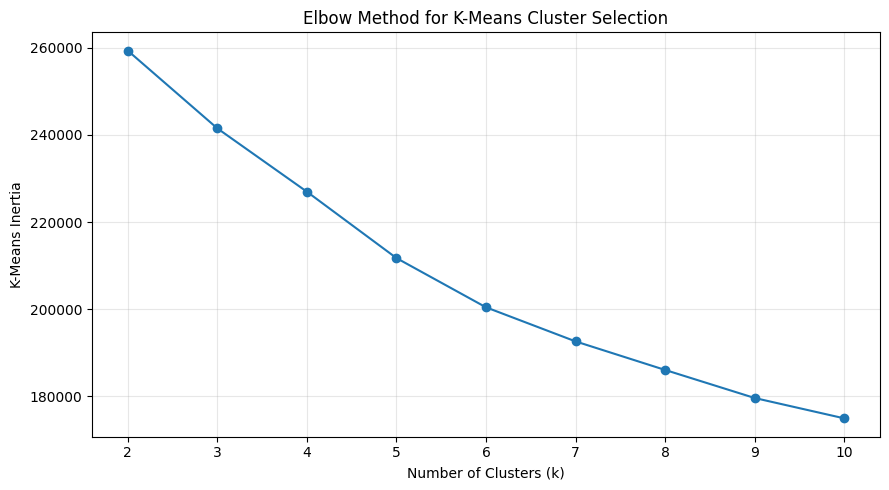

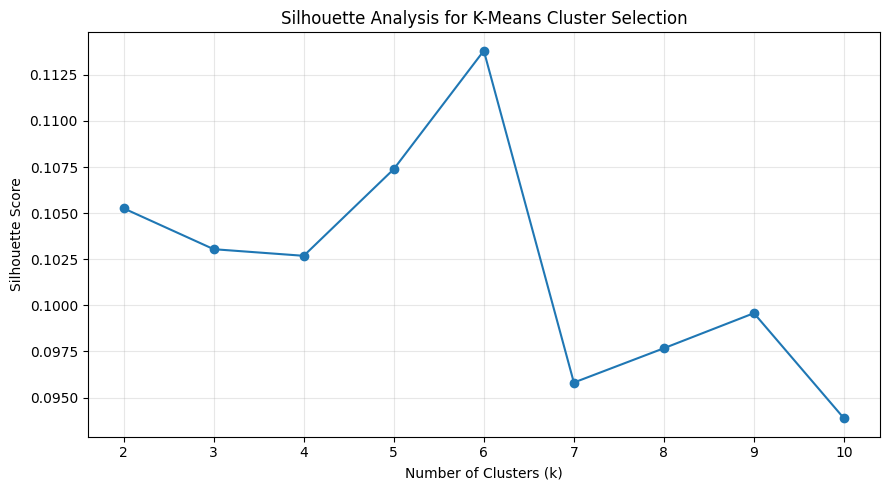


Cluster-number evaluation completed successfully.


In [90]:
# ============================================================
# 3.15 Selection of the Optimal Number of Clusters
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Candidate numbers of clusters
# ------------------------------------------------------------

candidate_k = range(2, 11)

cluster_selection_records = []


print("K-MEANS CLUSTER NUMBER EVALUATION")
print("-" * 65)


# ------------------------------------------------------------
# Fit candidate K-Means models
# ------------------------------------------------------------

for k in candidate_k:

    kmeans_candidate = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels_candidate = (
        kmeans_candidate.fit_predict(
            X_cluster_scaled
        )
    )

    inertia = (
        kmeans_candidate.inertia_
    )

    silhouette = silhouette_score(
        X_cluster_scaled,
        cluster_labels_candidate
    )

    cluster_selection_records.append({
        "Number_of_Clusters": k,
        "Inertia": inertia,
        "Silhouette_Score": silhouette
    })

    print(
        f"k = {k:2d} | "
        f"Inertia = {inertia:,.2f} | "
        f"Silhouette = {silhouette:.4f}"
    )


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

cluster_selection_results = pd.DataFrame(
    cluster_selection_records
)


# Calculate reduction in inertia
cluster_selection_results[
    "Inertia_Reduction"
] = (
    cluster_selection_results[
        "Inertia"
    ]
    .shift(1)
    -
    cluster_selection_results[
        "Inertia"
    ]
)


cluster_selection_results[
    "Inertia_Reduction_Percent"
] = (
    cluster_selection_results[
        "Inertia_Reduction"
    ]
    /
    cluster_selection_results[
        "Inertia"
    ].shift(1)
    * 100
)


print("\nCLUSTER SELECTION SUMMARY")
print("-" * 65)

display(
    cluster_selection_results.round(4)
)


# ------------------------------------------------------------
# Best solution according to silhouette score
# ------------------------------------------------------------

best_silhouette_row = (
    cluster_selection_results
    .loc[
        cluster_selection_results[
            "Silhouette_Score"
        ].idxmax()
    ]
)


best_k_silhouette = int(
    best_silhouette_row[
        "Number_of_Clusters"
    ]
)

best_silhouette_score = (
    best_silhouette_row[
        "Silhouette_Score"
    ]
)


print("\nSILHOUETTE-BASED SELECTION")
print("-" * 65)

print(
    f"Highest silhouette score : "
    f"{best_silhouette_score:.4f}"
)

print(
    f"Corresponding k          : "
    f"{best_k_silhouette}"
)


# ------------------------------------------------------------
# Elbow plot
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    cluster_selection_results[
        "Number_of_Clusters"
    ],
    cluster_selection_results[
        "Inertia"
    ],
    marker="o"
)

plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "K-Means Inertia"
)

plt.title(
    "Elbow Method for K-Means Cluster Selection"
)

plt.xticks(
    list(candidate_k)
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Silhouette-score plot
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    cluster_selection_results[
        "Number_of_Clusters"
    ],
    cluster_selection_results[
        "Silhouette_Score"
    ],
    marker="o"
)

plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "Silhouette Analysis for K-Means Cluster Selection"
)

plt.xticks(
    list(candidate_k)
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert (
    len(cluster_selection_results)
    == len(list(candidate_k))
)

assert (
    cluster_selection_results[
        "Inertia"
    ] > 0
).all()

assert (
    cluster_selection_results[
        "Silhouette_Score"
    ]
    .between(-1, 1)
    .all()
)

assert (
    cluster_selection_results[
        "Inertia"
    ]
    .is_monotonic_decreasing
)


print(
    "\nCluster-number evaluation "
    "completed successfully."
)

### Interpretation

The number of clusters was evaluated from `k = 2` to `k = 10` using both K-Means inertia and the silhouette score. As expected, inertia decreased continuously as the number of clusters increased. The elbow curve shows that the rate of improvement begins to reduce around the five-to-six cluster region, after which additional clusters provide progressively smaller reductions in within-cluster variation.

The silhouette analysis provides additional evidence for cluster selection. The highest silhouette score was 0.1138 at `k = 6`, compared with 0.1074 for five clusters and lower scores for the remaining candidate solutions. Therefore, six clusters are selected for the final K-Means model.

The relatively low silhouette scores indicate that the applicant groups are not strongly separated and that some overlap exists between their financial and demographic characteristics. Consequently, the clusters should be interpreted as exploratory customer segments rather than completely distinct natural groups.

## 3.16 Final K-Means Clustering Model and Cluster Profiling

Based on the elbow and silhouette analyses, a six-cluster K-Means solution is fitted to the standardised training data. Each applicant is assigned to the nearest cluster centroid.

The resulting clusters are profiled using the original, unstandardised variables so that differences between applicant groups remain interpretable in their natural units. Cluster sizes and selected financial, demographic and credit characteristics are examined to identify the main characteristics distinguishing the resulting applicant segments.

In [91]:
# ============================================================
# 3.16 Final K-Means Clustering Model and Cluster Profiling
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Final number of clusters
# ------------------------------------------------------------

final_k = 6


# ------------------------------------------------------------
# Fit final K-Means model
# ------------------------------------------------------------

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

final_cluster_labels = (
    final_kmeans.fit_predict(
        X_cluster_scaled
    )
)


# ------------------------------------------------------------
# Final clustering quality
# ------------------------------------------------------------

final_cluster_inertia = (
    final_kmeans.inertia_
)

final_cluster_silhouette = (
    silhouette_score(
        X_cluster_scaled,
        final_cluster_labels
    )
)


print("FINAL K-MEANS CLUSTERING MODEL")
print("-" * 70)

print(
    f"Selected number of clusters : "
    f"{final_k}"
)

print(
    f"Training observations       : "
    f"{len(final_cluster_labels)}"
)

print(
    f"Clustering variables        : "
    f"{len(clustering_features)}"
)

print(
    f"Final inertia               : "
    f"{final_cluster_inertia:,.2f}"
)

print(
    f"Final silhouette score      : "
    f"{final_cluster_silhouette:.4f}"
)


# ------------------------------------------------------------
# Attach cluster labels to original-scale data
# ------------------------------------------------------------

cluster_profile_data = (
    clustering_data.copy()
)

cluster_profile_data[
    "Cluster"
] = final_cluster_labels


# ------------------------------------------------------------
# Cluster-size summary
# ------------------------------------------------------------

cluster_size_summary = (
    cluster_profile_data[
        "Cluster"
    ]
    .value_counts()
    .sort_index()
    .rename("Applicants")
    .to_frame()
)

cluster_size_summary[
    "Percentage"
] = (
    cluster_size_summary[
        "Applicants"
    ]
    /
    len(cluster_profile_data)
    * 100
)


print("\nCLUSTER SIZE SUMMARY")
print("-" * 70)

display(
    cluster_size_summary.round(2)
)


# ------------------------------------------------------------
# Cluster profile using selected interpretable variables
# ------------------------------------------------------------

profile_features = [
    "AnnualIncome",
    "Age",
    "Experience",
    "CreditScore",
    "LoanAmount",
    "InterestRate",
    "MonthlyDebtPayments",
    "TotalAssets",
    "TotalLiabilities",
    "NetWorth",
    "MonthlyIncome",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio"
]


cluster_profile_means = (
    cluster_profile_data
    .groupby("Cluster")[
        profile_features
    ]
    .mean()
)


print("\nCLUSTER PROFILE — MEAN VALUES")
print("-" * 70)

display(
    cluster_profile_means.round(2)
)


# ------------------------------------------------------------
# Median profile
#
# Useful because several financial variables were previously
# shown to have skewed distributions.
# ------------------------------------------------------------

cluster_profile_medians = (
    cluster_profile_data
    .groupby("Cluster")[
        profile_features
    ]
    .median()
)


print("\nCLUSTER PROFILE — MEDIAN VALUES")
print("-" * 70)

display(
    cluster_profile_medians.round(2)
)


# ------------------------------------------------------------
# Standardised cluster centroids
# ------------------------------------------------------------

cluster_centroids_scaled = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=clustering_features
)

cluster_centroids_scaled.index.name = (
    "Cluster"
)


print("\nSTANDARDISED CLUSTER CENTROIDS")
print("-" * 70)

display(
    cluster_centroids_scaled.round(3)
)


# ------------------------------------------------------------
# Identify strongest characteristics of each cluster
#
# Positive values = above overall average
# Negative values = below overall average
# ------------------------------------------------------------

cluster_characteristics = []

for cluster_id in range(final_k):

    centroid = (
        cluster_centroids_scaled
        .loc[cluster_id]
    )

    strongest_features = (
        centroid
        .abs()
        .sort_values(
            ascending=False
        )
        .head(5)
        .index
    )

    for feature in strongest_features:

        standardised_difference = (
            centroid[feature]
        )

        direction = (
            "Above average"
            if standardised_difference > 0
            else "Below average"
        )

        cluster_characteristics.append({
            "Cluster": cluster_id,
            "Feature": feature,
            "Direction": direction,
            "Standardised_Difference":
                standardised_difference
        })


cluster_characteristics_df = pd.DataFrame(
    cluster_characteristics
)


print("\nSTRONGEST CHARACTERISTICS BY CLUSTER")
print("-" * 70)

display(
    cluster_characteristics_df.round(3)
)


# ------------------------------------------------------------
# Cluster balance diagnostics
# ------------------------------------------------------------

smallest_cluster = (
    cluster_size_summary[
        "Applicants"
    ].min()
)

largest_cluster = (
    cluster_size_summary[
        "Applicants"
    ].max()
)

smallest_cluster_percent = (
    cluster_size_summary[
        "Percentage"
    ].min()
)

largest_cluster_percent = (
    cluster_size_summary[
        "Percentage"
    ].max()
)


print("\nCLUSTER BALANCE")
print("-" * 70)

print(
    f"Smallest cluster size       : "
    f"{smallest_cluster}"
)

print(
    f"Largest cluster size        : "
    f"{largest_cluster}"
)

print(
    f"Smallest cluster percentage : "
    f"{smallest_cluster_percent:.2f}%"
)

print(
    f"Largest cluster percentage  : "
    f"{largest_cluster_percent:.2f}%"
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(
    final_cluster_labels
) == len(
    clustering_data
)

assert (
    len(
        np.unique(
            final_cluster_labels
        )
    )
    == final_k
)

assert (
    cluster_size_summary[
        "Applicants"
    ].sum()
    == len(clustering_data)
)

assert np.isfinite(
    final_kmeans.cluster_centers_
).all()

assert (
    -1
    <= final_cluster_silhouette
    <= 1
)


print(
    "\nFinal K-Means clustering and "
    "profiling completed successfully."
)

FINAL K-MEANS CLUSTERING MODEL
----------------------------------------------------------------------
Selected number of clusters : 6
Training observations       : 16000
Clustering variables        : 18
Final inertia               : 200,438.14
Final silhouette score      : 0.1138

CLUSTER SIZE SUMMARY
----------------------------------------------------------------------


,Applicants,Percentage
Cluster,,
0,5143,32.14
1,1889,11.81
2,1917,11.98
3,5827,36.42
4,715,4.47
5,509,3.18



CLUSTER PROFILE — MEAN VALUES
----------------------------------------------------------------------


Variable,AnnualIncome,Age,Experience,CreditScore,LoanAmount,InterestRate,MonthlyDebtPayments,TotalAssets,TotalLiabilities,NetWorth,MonthlyIncome,MonthlyLoanPayment,TotalDebtToIncomeRatio
Cluster,,,,,,,,,,,,,
0,52206.75,49.13,26.79,599.31,21127.02,21.71,459.80,77471.24,36309.60,53354.18,4350.56,724.24,33.05
1,39964.86,38.42,16.15,560.30,46549.71,25.78,502.79,81437.49,35651.00,57422.16,3330.41,2125.83,96.74
2,140968.00,42.56,20.14,582.65,24314.50,23.45,451.93,82402.80,36426.81,57909.50,11747.33,847.07,11.89
3,45767.31,30.92,8.89,546.97,21599.98,25.47,435.51,77060.65,37114.63,52352.78,3813.94,717.12,37.45
4,55460.26,39.57,17.34,572.71,24033.54,23.71,466.07,492884.05,30170.56,462713.49,4621.69,853.27,37.41
5,56252.23,40.01,17.81,572.17,23945.85,23.74,464.13,88283.85,36867.88,64230.29,4687.69,889.87,38.38



CLUSTER PROFILE — MEDIAN VALUES
----------------------------------------------------------------------


...


STANDARDISED CLUSTER CENTROIDS
----------------------------------------------------------------------


,AnnualIncome,Age,Experience,LoanAmount,LoanDuration,CreditScore,InterestRate,LengthOfCreditHistory,MonthlyDebtPayments,CreditCardUtilizationRate,CheckingAccountBalance,SavingsAccountBalance,TotalAssets,TotalLiabilities,NetWorth,MonthlyIncome,MonthlyLoanPayment,TotalDebtToIncomeRatio
Cluster,,,,,,,,,,,,,,,,,,
0,-0.177,0.806,0.817,-0.281,-0.086,0.544,-0.524,0.000,0.018,-0.167,0.002,-0.015,-0.165,0.000,-0.165,-0.177,-0.280,-0.205
1,-0.480,-0.113,-0.120,1.614,-0.531,-0.222,0.442,-0.036,0.196,-0.146,0.013,0.028,-0.132,-0.013,-0.130,-0.480,1.801,1.677
2,2.024,0.243,0.232,-0.044,0.058,0.217,-0.111,-0.039,-0.015,-0.147,0.039,0.002,-0.124,0.003,-0.126,2.024,-0.098,-0.831
3,-0.336,-0.756,-0.760,-0.246,0.235,-0.483,0.366,0.017,-0.083,-0.173,-0.014,-0.002,-0.169,0.017,-0.174,-0.336,-0.291,-0.076
4,-0.097,-0.015,-0.016,-0.064,-0.025,0.021,-0.048,0.041,0.046,-0.123,-0.044,-0.004,3.296,-0.127,3.331,-0.097,-0.088,-0.075
5,-0.076,0.024,0.026,-0.071,-0.034,0.011,-0.044,0.022,0.036,4.933,0.011,0.060,-0.075,0.012,-0.072,-0.076,-0.034,-0.048



STRONGEST CHARACTERISTICS BY CLUSTER
----------------------------------------------------------------------


,Cluster,Feature,Direction,Standardised_Difference
0,0,Experience,Above average,0.817
1,0,Age,Above average,0.806
2,0,CreditScore,Above average,0.544
3,0,InterestRate,Below average,-0.524
4,0,LoanAmount,Below average,-0.281
5,1,MonthlyLoanPayment,Above average,1.801
6,1,TotalDebtToIncomeRatio,Above average,1.677
7,1,LoanAmount,Above average,1.614
8,1,LoanDuration,Below average,-0.531
9,1,AnnualIncome,Below average,-0.480



CLUSTER BALANCE
----------------------------------------------------------------------
Smallest cluster size       : 509
Largest cluster size        : 5827
Smallest cluster percentage : 3.18%
Largest cluster percentage  : 36.42%

Final K-Means clustering and profiling completed successfully.


## 3.17 Cluster Interpretation and Visualisation

The final six-cluster solution is examined visually to support interpretation of the applicant segments. Standardised cluster centroids are used because the clustering variables have substantially different measurement scales.

A centroid heatmap shows whether each characteristic is above or below the overall standardised mean for each cluster. In addition, cluster sizes are visualised to show the relative prevalence of each applicant segment. These visualisations support interpretation of the clusters while recognising that the relatively low silhouette score indicates considerable overlap between groups.

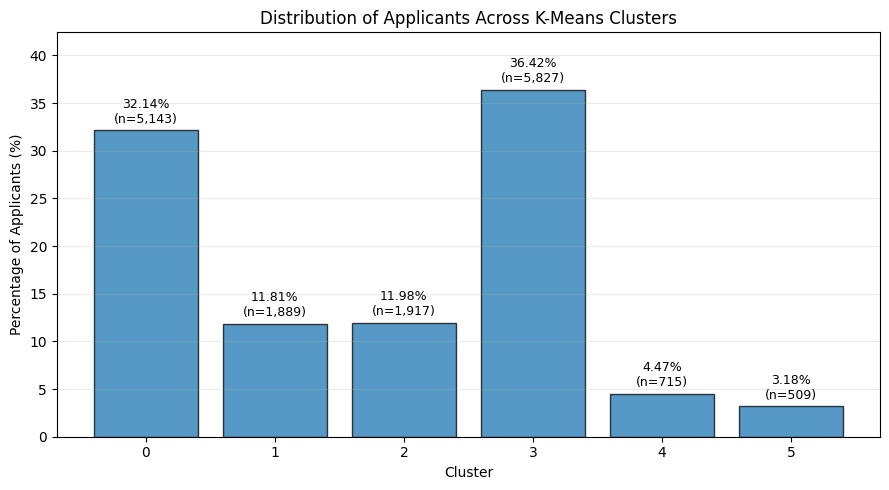

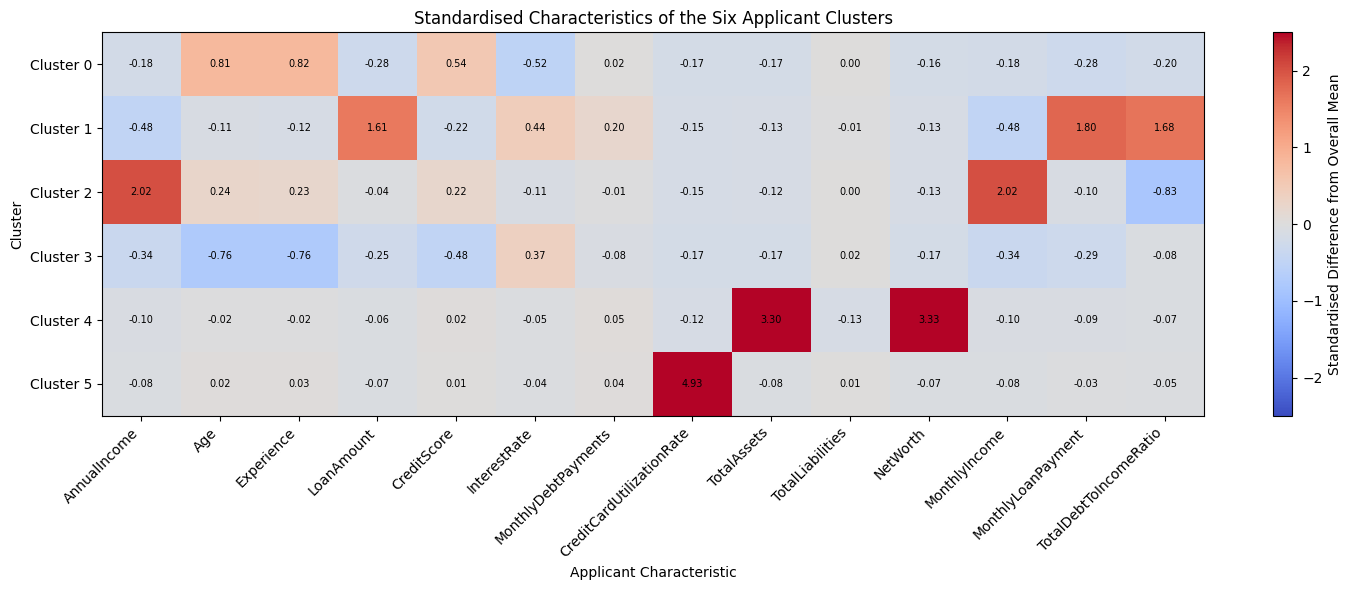

CLUSTER INTERPRETATION SUMMARY
----------------------------------------------------------------------


,Cluster,Applicants,Percentage,Interpretation
0,0,5143,32.14,"Older, experienced applicants with stronger cr..."
1,1,1889,11.81,High-loan and high debt-burden applicants
2,2,1917,11.98,High-income applicants with relatively low deb...
3,3,5827,36.42,"Younger, less experienced applicants with weak..."
4,4,715,4.47,High-net-worth and high-asset applicants
5,5,509,3.18,Extremely high credit-card-utilisation applicants



Cluster interpretation and visualisation completed successfully.


In [92]:
# ============================================================
# 3.17 Cluster Interpretation and Visualisation
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# 1. Cluster size visualisation
# ------------------------------------------------------------

cluster_counts = (
    cluster_profile_data["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_percentages = (
    cluster_counts
    / cluster_counts.sum()
    * 100
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    cluster_counts.index.astype(str),
    cluster_percentages.values,
    edgecolor="black",
    alpha=0.75
)

ax.set_title(
    "Distribution of Applicants Across K-Means Clusters"
)
ax.set_xlabel("Cluster")
ax.set_ylabel("Percentage of Applicants (%)")

for bar, percentage, count in zip(
    bars,
    cluster_percentages.values,
    cluster_counts.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{percentage:.2f}%\n(n={count:,})",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_ylim(
    0,
    cluster_percentages.max() + 6
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Select interpretable variables for centroid heatmap
# ------------------------------------------------------------

heatmap_features = [
    "AnnualIncome",
    "Age",
    "Experience",
    "LoanAmount",
    "CreditScore",
    "InterestRate",
    "MonthlyDebtPayments",
    "CreditCardUtilizationRate",
    "TotalAssets",
    "TotalLiabilities",
    "NetWorth",
    "MonthlyIncome",
    "MonthlyLoanPayment",
    "TotalDebtToIncomeRatio"
]

# Confirm variables exist
heatmap_features = [
    feature
    for feature in heatmap_features
    if feature in cluster_centroids_scaled.columns
]

centroid_heatmap_data = (
    cluster_centroids_scaled[
        heatmap_features
    ]
)


# ------------------------------------------------------------
# 3. Standardised centroid heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(15, 6)
)

heatmap = ax.imshow(
    centroid_heatmap_data.values,
    aspect="auto",
    cmap="coolwarm",
    vmin=-2.5,
    vmax=2.5
)

ax.set_title(
    "Standardised Characteristics of the Six Applicant Clusters"
)

ax.set_xlabel(
    "Applicant Characteristic"
)

ax.set_ylabel(
    "Cluster"
)

ax.set_xticks(
    np.arange(
        len(heatmap_features)
    )
)

ax.set_xticklabels(
    heatmap_features,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    np.arange(final_k)
)

ax.set_yticklabels(
    [
        f"Cluster {i}"
        for i in range(final_k)
    ]
)

# Add values to cells
for i in range(
    centroid_heatmap_data.shape[0]
):
    for j in range(
        centroid_heatmap_data.shape[1]
    ):

        value = (
            centroid_heatmap_data.iloc[i, j]
        )

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

colorbar = fig.colorbar(
    heatmap,
    ax=ax
)

colorbar.set_label(
    "Standardised Difference from Overall Mean"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Create concise cluster interpretation table
# ------------------------------------------------------------

cluster_interpretation = pd.DataFrame({
    "Cluster": [0, 1, 2, 3, 4, 5],

    "Applicants": [
        cluster_counts.get(i, 0)
        for i in range(final_k)
    ],

    "Percentage": [
        cluster_percentages.get(i, 0)
        for i in range(final_k)
    ],

    "Interpretation": [
        "Older, experienced applicants with stronger credit profiles",
        "High-loan and high debt-burden applicants",
        "High-income applicants with relatively low debt burden",
        "Younger, less experienced applicants with weaker credit profiles",
        "High-net-worth and high-asset applicants",
        "Extremely high credit-card-utilisation applicants"
    ]
})


print("CLUSTER INTERPRETATION SUMMARY")
print("-" * 70)

display(
    cluster_interpretation.round(2)
)


# ------------------------------------------------------------
# 5. Validation
# ------------------------------------------------------------

assert (
    cluster_interpretation[
        "Applicants"
    ].sum()
    == len(cluster_profile_data)
)

assert len(
    centroid_heatmap_data
) == final_k

assert np.isfinite(
    centroid_heatmap_data.values
).all()


print(
    "\nCluster interpretation and visualisation "
    "completed successfully."
)

## 3.18 PCA-Based Visualisation of K-Means Clusters

To examine the structure of the six K-Means clusters visually, Principal Component Analysis (PCA) is applied to the standardised clustering matrix. The first two principal components provide a two-dimensional representation of the applicant observations while retaining as much variation as possible.

The PCA projection is used only for visual interpretation. The final K-Means clusters remain those obtained from the full standardised clustering feature set. Cluster centroids are projected into the same PCA space to show the approximate location of each cluster centre.

PCA-BASED CLUSTER VISUALISATION
------------------------------------------------------------
Observations projected       : 16000
Original clustering features : 18
PC1 explained variance       : 16.35%
PC2 explained variance       : 12.12%
Combined explained variance  : 28.46%


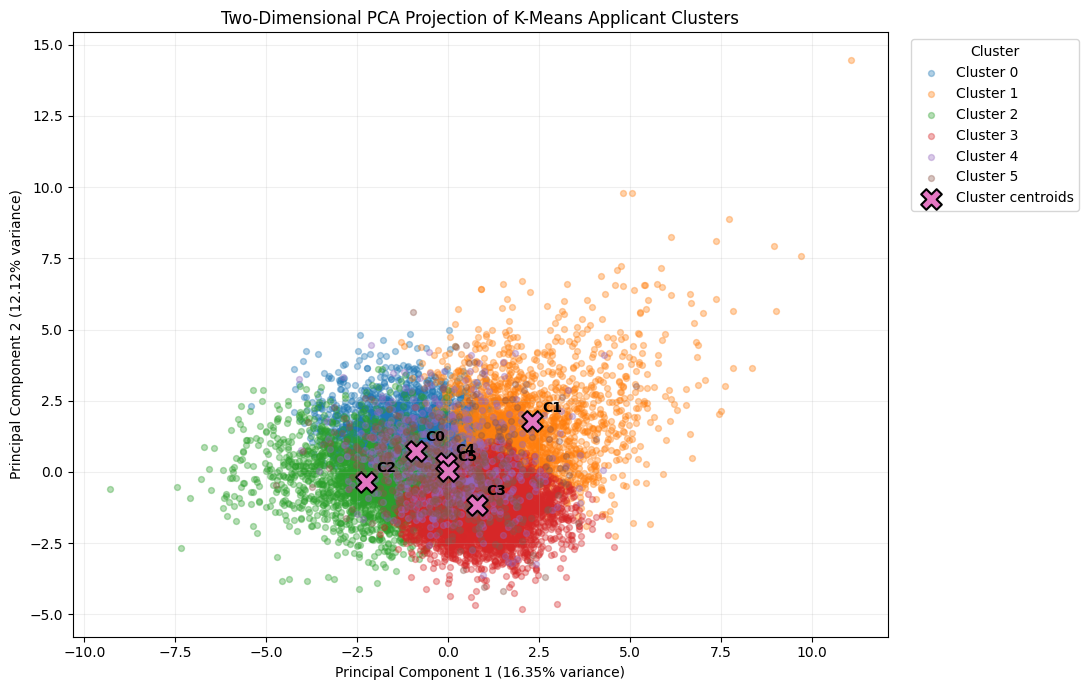


PCA-PROJECTED CLUSTER CENTROIDS
------------------------------------------------------------


,PC1_Centroid,PC2_Centroid,Cluster_Size,Cluster_Percentage
Cluster,,,,
0,-0.891,0.733,5143,32.144
1,2.321,1.770,1889,11.806
2,-2.252,-0.338,1917,11.981
3,0.785,-1.150,5827,36.419
4,-0.062,0.296,715,4.469
5,-0.009,0.037,509,3.181



TOP VARIABLES CONTRIBUTING TO PC1
------------------------------------------------------------


,PC1_Loading,PC2_Loading,PC1_Absolute_Loading,PC2_Absolute_Loading
TotalDebtToIncomeRatio,0.440,0.322,0.440,0.322
MonthlyIncome,-0.398,-0.068,0.398,0.068
AnnualIncome,-0.398,-0.068,0.398,0.068
Experience,-0.320,0.425,0.320,0.425
Age,-0.320,0.424,0.320,0.424
MonthlyLoanPayment,0.276,0.415,0.276,0.415
CreditScore,-0.265,0.291,0.265,0.291
LoanAmount,0.264,0.327,0.264,0.327



TOP VARIABLES CONTRIBUTING TO PC2
------------------------------------------------------------


,PC1_Loading,PC2_Loading,PC1_Absolute_Loading,PC2_Absolute_Loading
Experience,-0.320,0.425,0.320,0.425
Age,-0.320,0.424,0.320,0.424
MonthlyLoanPayment,0.276,0.415,0.276,0.415
LoanAmount,0.264,0.327,0.264,0.327
TotalDebtToIncomeRatio,0.440,0.322,0.440,0.322
LoanDuration,-0.038,-0.302,0.038,0.302
CreditScore,-0.265,0.291,0.265,0.291
InterestRate,0.256,-0.245,0.256,0.245



PCA-based cluster visualisation completed successfully.


In [93]:
# ============================================================
# 3.18 PCA-Based Visualisation of K-Means Clusters
# ============================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Fit a two-component PCA to the clustering matrix
# ------------------------------------------------------------

cluster_pca = PCA(
    n_components=2,
    random_state=42
)

X_cluster_pca = cluster_pca.fit_transform(
    X_cluster_scaled
)

explained_variance = (
    cluster_pca.explained_variance_ratio_ * 100
)

print("PCA-BASED CLUSTER VISUALISATION")
print("-" * 60)

print(
    f"Observations projected       : "
    f"{X_cluster_pca.shape[0]}"
)

print(
    f"Original clustering features : "
    f"{X_cluster_scaled.shape[1]}"
)

print(
    f"PC1 explained variance       : "
    f"{explained_variance[0]:.2f}%"
)

print(
    f"PC2 explained variance       : "
    f"{explained_variance[1]:.2f}%"
)

print(
    f"Combined explained variance  : "
    f"{explained_variance.sum():.2f}%"
)


# ------------------------------------------------------------
# 2. Create PCA plotting DataFrame
# ------------------------------------------------------------

pca_cluster_df = pd.DataFrame(
    X_cluster_pca,
    columns=[
        "PC1",
        "PC2"
    ],
    index=X_train_treated.index
)

pca_cluster_df["Cluster"] = (
    cluster_profile_data["Cluster"]
    .reindex(pca_cluster_df.index)
    .astype(int)
)


# ------------------------------------------------------------
# 3. Project K-Means centroids into PCA space
# ------------------------------------------------------------

centroids_pca = cluster_pca.transform(
    final_kmeans.cluster_centers_
)


# ------------------------------------------------------------
# 4. PCA cluster scatter plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 7)
)

for cluster_id in sorted(
    pca_cluster_df["Cluster"].unique()
):

    cluster_subset = pca_cluster_df[
        pca_cluster_df["Cluster"]
        == cluster_id
    ]

    ax.scatter(
        cluster_subset["PC1"],
        cluster_subset["PC2"],
        s=18,
        alpha=0.35,
        label=f"Cluster {cluster_id}"
    )


# Plot projected cluster centroids
ax.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=220,
    edgecolor="black",
    linewidth=1.5,
    label="Cluster centroids"
)

# Label centroids
for cluster_id, (
    pc1,
    pc2
) in enumerate(centroids_pca):

    ax.annotate(
        f"C{cluster_id}",
        (pc1, pc2),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )


ax.set_title(
    "Two-Dimensional PCA Projection of K-Means Applicant Clusters"
)

ax.set_xlabel(
    f"Principal Component 1 "
    f"({explained_variance[0]:.2f}% variance)"
)

ax.set_ylabel(
    f"Principal Component 2 "
    f"({explained_variance[1]:.2f}% variance)"
)

ax.legend(
    title="Cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    alpha=0.20
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. PCA cluster centroid coordinates
# ------------------------------------------------------------

centroid_pca_summary = pd.DataFrame(
    centroids_pca,
    columns=[
        "PC1_Centroid",
        "PC2_Centroid"
    ]
)

centroid_pca_summary.index.name = "Cluster"

centroid_pca_summary[
    "Cluster_Size"
] = [
    cluster_counts.get(i, 0)
    for i in range(final_k)
]

centroid_pca_summary[
    "Cluster_Percentage"
] = [
    cluster_percentages.get(i, 0)
    for i in range(final_k)
]


print(
    "\nPCA-PROJECTED CLUSTER CENTROIDS"
)

print("-" * 60)

display(
    centroid_pca_summary.round(3)
)


# ------------------------------------------------------------
# 6. PCA loading analysis
# ------------------------------------------------------------

pca_loading_summary = pd.DataFrame(
    cluster_pca.components_.T,
    index=clustering_features,
    columns=[
        "PC1_Loading",
        "PC2_Loading"
    ]
)

pca_loading_summary[
    "PC1_Absolute_Loading"
] = (
    pca_loading_summary[
        "PC1_Loading"
    ].abs()
)

pca_loading_summary[
    "PC2_Absolute_Loading"
] = (
    pca_loading_summary[
        "PC2_Loading"
    ].abs()
)


print(
    "\nTOP VARIABLES CONTRIBUTING TO PC1"
)

print("-" * 60)

display(
    pca_loading_summary
    .sort_values(
        "PC1_Absolute_Loading",
        ascending=False
    )
    .head(8)
    .round(3)
)


print(
    "\nTOP VARIABLES CONTRIBUTING TO PC2"
)

print("-" * 60)

display(
    pca_loading_summary
    .sort_values(
        "PC2_Absolute_Loading",
        ascending=False
    )
    .head(8)
    .round(3)
)


# ------------------------------------------------------------
# 7. Validation
# ------------------------------------------------------------

assert (
    X_cluster_pca.shape
    == (16000, 2)
)

assert (
    len(pca_cluster_df)
    == len(cluster_profile_data)
)

assert (
    centroids_pca.shape
    == (final_k, 2)
)

assert np.isfinite(
    X_cluster_pca
).all()

assert np.isfinite(
    centroids_pca
).all()


print(
    "\nPCA-based cluster visualisation "
    "completed successfully."
)

## 3.19 Final Model Evaluation and Analytical Summary

This section consolidates the main findings from the predictive and unsupervised modelling stages. The classification models are compared using the independent test set, while the clustering results are summarised separately because clustering is an unsupervised task and therefore cannot be evaluated using classification metrics.

The final predictive model is the threshold-optimised Logistic Regression model. Its performance is compared with the baseline Logistic Regression and Random Forest models using accuracy, precision, recall, F1-score and ROC-AUC. The PCA and K-Means analyses are then summarised to assess dimensional structure and applicant segmentation.

This consolidated evaluation provides the final evidence for model selection and highlights the principal analytical findings obtained from the modelling process.

In [97]:
# ============================================================
# 3.19 Final Model Evaluation and Analytical Summary
# ============================================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# ------------------------------------------------------------
# 1. Reconstruct classification metrics from existing outputs
# ------------------------------------------------------------

# Baseline Logistic Regression
baseline_accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

baseline_precision = precision_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

baseline_roc_auc = roc_auc_score(
    y_test,
    y_prob_baseline
)


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)


# ------------------------------------------------------------
# Threshold-Optimised Logistic Regression
# ------------------------------------------------------------

# These were already created in Section 3.12
optimised_test_proba = (
    test_probabilities_threshold
)

optimised_test_pred = (
    test_predictions_optimised
)

optimised_accuracy = accuracy_score(
    y_test,
    optimised_test_pred
)

optimised_precision = precision_score(
    y_test,
    optimised_test_pred,
    zero_division=0
)

optimised_recall = recall_score(
    y_test,
    optimised_test_pred,
    zero_division=0
)

optimised_f1 = f1_score(
    y_test,
    optimised_test_pred,
    zero_division=0
)

optimised_roc_auc = roc_auc_score(
    y_test,
    optimised_test_proba
)


# ------------------------------------------------------------
# 2. Consolidated classification performance
# ------------------------------------------------------------

final_performance_summary = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "Threshold-Optimised Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        baseline_accuracy,
        optimised_accuracy,
        rf_accuracy
    ],

    "Precision": [
        baseline_precision,
        optimised_precision,
        rf_precision
    ],

    "Recall": [
        baseline_recall,
        optimised_recall,
        rf_recall
    ],

    "F1_Score": [
        baseline_f1,
        optimised_f1,
        rf_f1
    ],

    "ROC_AUC": [
        baseline_roc_auc,
        optimised_roc_auc,
        rf_roc_auc
    ]
})


final_performance_summary["Accuracy_Rank"] = (
    final_performance_summary["Accuracy"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)

final_performance_summary["F1_Rank"] = (
    final_performance_summary["F1_Score"]
    .rank(
        ascending=False,
        method="min"
    )
    .astype(int)
)


final_performance_summary = (
    final_performance_summary
    .sort_values(
        ["F1_Rank", "Accuracy_Rank"]
    )
    .reset_index(drop=True)
)


print("FINAL CLASSIFICATION PERFORMANCE")
print("-" * 70)

display(
    final_performance_summary.round(4)
)


# ------------------------------------------------------------
# 3. Final selected classification model
# ------------------------------------------------------------

print("\nFINAL PREDICTIVE MODEL")
print("-" * 70)

print(
    "Selected model              : "
    "Threshold-Optimised Logistic Regression"
)

print(
    f"Regularisation parameter C   : "
    f"{best_C}"
)

print(
    f"Decision threshold           : "
    f"{optimal_threshold:.2f}"
)

print(
    f"Test accuracy                : "
    f"{optimised_accuracy:.4f}"
)

print(
    f"Test precision               : "
    f"{optimised_precision:.4f}"
)

print(
    f"Test recall                  : "
    f"{optimised_recall:.4f}"
)

print(
    f"Test F1-score                : "
    f"{optimised_f1:.4f}"
)

print(
    f"Test ROC-AUC                 : "
    f"{optimised_roc_auc:.4f}"
)


# ------------------------------------------------------------
# 4. Final confusion matrix and error analysis
# ------------------------------------------------------------

final_cm = confusion_matrix(
    y_test,
    optimised_test_pred
)

final_tn, final_fp, final_fn, final_tp = (
    final_cm.ravel()
)


final_error_summary = pd.DataFrame({
    "Error_Component": [
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives",
        "Total Errors"
    ],

    "Count": [
        final_tn,
        final_fp,
        final_fn,
        final_tp,
        final_fp + final_fn
    ]
})


print("\nFINAL CLASSIFICATION ERROR SUMMARY")
print("-" * 70)

display(
    final_error_summary
)


# ------------------------------------------------------------
# 5. PCA dimensionality summary
# ------------------------------------------------------------

pca_final_summary = pd.DataFrame({
    "Measure": [
        "Original numerical dimensions",
        "Selected principal components",
        "Variance retained (%)",
        "Dimensions removed",
        "Dimensionality reduction (%)"
    ],

    "Value": [
        len(pca_features),
        selected_components,
        variance_retained_selected,
        len(pca_features) - selected_components,
        (
            (
                len(pca_features)
                - selected_components
            )
            / len(pca_features)
            * 100
        )
    ]
})


print("\nPCA DIMENSIONALITY SUMMARY")
print("-" * 70)

display(
    pca_final_summary.round(2)
)


# ------------------------------------------------------------
# 6. K-Means clustering summary
# ------------------------------------------------------------

clustering_final_summary = pd.DataFrame({
    "Measure": [
        "Training observations",
        "Clustering variables",
        "Selected clusters",
        "Silhouette score",
        "Largest cluster (%)",
        "Smallest cluster (%)",
        "PCA 2D variance represented (%)"
    ],

    "Value": [
        X_cluster_scaled.shape[0],
        X_cluster_scaled.shape[1],
        final_k,
        final_cluster_silhouette,
        cluster_percentages.max(),
        cluster_percentages.min(),
        explained_variance.sum()
    ]
})


print("\nK-MEANS CLUSTERING SUMMARY")
print("-" * 70)

display(
    clustering_final_summary.round(3)
)


# ------------------------------------------------------------
# 7. Applicant segment summary
# ------------------------------------------------------------

print("\nFINAL APPLICANT SEGMENT SUMMARY")
print("-" * 70)

display(
    cluster_interpretation.round(2)
)


# ------------------------------------------------------------
# 8. Overall modelling conclusions
# ------------------------------------------------------------

print("\nOVERALL MODELLING CONCLUSIONS")
print("-" * 70)

print(
    "1. Logistic Regression produced the strongest "
    "classification performance."
)

print(
    "2. Stratified cross-validation showed that Logistic "
    "Regression was more stable and accurate than Random Forest."
)

print(
    f"3. Hyperparameter optimisation selected C = {best_C}."
)

print(
    "4. Decision-threshold optimisation selected a threshold "
    f"of {optimal_threshold:.2f} and produced a small but "
    "measurable improvement in classification performance."
)

print(
    "5. RiskScore sensitivity analysis showed that strong "
    "predictive performance remained even after RiskScore "
    "was removed."
)

print(
    "6. PCA reduced the numerical feature space while "
    "retaining most of the original variance."
)

print(
    f"7. K-Means identified {final_k} exploratory applicant "
    "segments."
)

print(
    "8. The relatively low silhouette score indicates "
    "considerable overlap between the applicant clusters."
)

print(
    "9. The first two clustering PCA components represented "
    f"{explained_variance.sum():.2f}% of total clustering "
    "variance, so the two-dimensional plot should not be "
    "interpreted as a complete representation of the full "
    "clustering structure."
)


# ------------------------------------------------------------
# 9. Final validation
# ------------------------------------------------------------

assert len(
    final_performance_summary
) == 3

assert (
    final_performance_summary[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1_Score",
            "ROC_AUC"
        ]
    ]
    .apply(
        lambda column:
        column.between(0, 1).all()
    )
    .all()
)

assert (
    final_tn
    + final_fp
    + final_fn
    + final_tp
    == len(y_test)
)

assert (
    final_k
    == len(cluster_interpretation)
)

assert np.isfinite(
    final_cluster_silhouette
)

assert np.isfinite(
    explained_variance
).all()

assert (
    selected_components
    <= len(pca_features)
)

print(
    "\nTask 3 final model evaluation "
    "completed successfully."
)

FINAL CLASSIFICATION PERFORMANCE
----------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Accuracy_Rank,F1_Rank
0,Threshold-Optimised Logistic Regression,0.9952,0.9906,0.9895,0.9901,0.9999,1,1
1,Baseline Logistic Regression,0.9950,0.9906,0.9885,0.9895,0.9999,2,2
2,Random Forest,0.9872,0.9799,0.9665,0.9731,0.9989,3,3



FINAL PREDICTIVE MODEL
----------------------------------------------------------------------
Selected model              : Threshold-Optimised Logistic Regression
Regularisation parameter C   : 1
Decision threshold           : 0.47
Test accuracy                : 0.9952
Test precision               : 0.9906
Test recall                  : 0.9895
Test F1-score                : 0.9901
Test ROC-AUC                 : 0.9999

FINAL CLASSIFICATION ERROR SUMMARY
----------------------------------------------------------------------


,Error_Component,Count
0,True Negatives,3035
1,False Positives,9
2,False Negatives,10
3,True Positives,946
4,Total Errors,19



PCA DIMENSIONALITY SUMMARY
----------------------------------------------------------------------


...


K-MEANS CLUSTERING SUMMARY
----------------------------------------------------------------------


,Measure,Value
0,Training observations,16000.000
1,Clustering variables,18.000
2,Selected clusters,6.000
3,Silhouette score,0.114
4,Largest cluster (%),36.419
5,Smallest cluster (%),3.181
6,PCA 2D variance represented (%),28.464



FINAL APPLICANT SEGMENT SUMMARY
----------------------------------------------------------------------


,Cluster,Applicants,Percentage,Interpretation
0,0,5143,32.14,"Older, experienced applicants with stronger cr..."
1,1,1889,11.81,High-loan and high debt-burden applicants
2,2,1917,11.98,High-income applicants with relatively low deb...
3,3,5827,36.42,"Younger, less experienced applicants with weak..."
4,4,715,4.47,High-net-worth and high-asset applicants
5,5,509,3.18,Extremely high credit-card-utilisation applicants



OVERALL MODELLING CONCLUSIONS
----------------------------------------------------------------------
1. Logistic Regression produced the strongest classification performance.
2. Stratified cross-validation showed that Logistic Regression was more stable and accurate than Random Forest.
3. Hyperparameter optimisation selected C = 1.
4. Decision-threshold optimisation selected a threshold of 0.47 and produced a small but measurable improvement in classification performance.
5. RiskScore sensitivity analysis showed that strong predictive performance remained even after RiskScore was removed.
6. PCA reduced the numerical feature space while retaining most of the original variance.
7. K-Means identified 6 exploratory applicant segments.
8. The relatively low silhouette score indicates considerable overlap between the applicant clusters.
9. The first two clustering PCA components represented 28.46% of total clustering variance, so the two-dimensional plot should not be interpreted as a comp

# Task 4 — Application Development

## 4.1 Application Architecture and Model Deployment Preparation

A multipage graphical application is developed to provide interactive access to the analytical and modelling outputs produced in Tasks 2 and 3.

The application is implemented using Streamlit and contains three principal sections:

- **Modelling and Prediction** — allows users to enter applicant information, select a trained classification model and generate a loan-approval prediction.
- **Data Overview** — provides summary information about the loan-application dataset.
- **Exploratory Data Analysis** — provides selected interactive visualisations and descriptive insights from the exploratory analysis.

The modelling interface includes the baseline Logistic Regression, threshold-optimised Logistic Regression and Random Forest models. The optimised Logistic Regression configuration is identified as the preferred model based on the evaluation completed in Task 3.

The trained preprocessing objects, models and supporting metadata are stored separately from the application code so that the GUI can perform prediction without retraining the models each time the application starts.

4.3 Export Trained Models for Streamlit Application

In [99]:
# ============================================================
# 4.3 Export Trained Models for Streamlit Application
# ============================================================

import os
import joblib


# ------------------------------------------------------------
# 1. Create model output directory
# ------------------------------------------------------------

model_dir = "../models"

os.makedirs(
    model_dir,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. Validate required Task 3 objects
# ------------------------------------------------------------

required_objects = {
    "preprocessor": preprocessor,
    "baseline_logistic": baseline_logistic,
    "final_logistic": threshold_model,
    "random_forest": random_forest_model,
    "optimal_threshold": optimal_threshold
}

print("MODEL EXPORT VALIDATION")
print("-" * 60)

for object_name, object_value in required_objects.items():

    assert object_value is not None, (
        f"{object_name} is not available."
    )

    print(
        f"{object_name:<25}: available"
    )


# ------------------------------------------------------------
# 3. Save preprocessing pipeline
# ------------------------------------------------------------

preprocessor_path = os.path.join(
    model_dir,
    "preprocessor.joblib"
)

joblib.dump(
    preprocessor,
    preprocessor_path
)


# ------------------------------------------------------------
# 4. Save baseline Logistic Regression
# ------------------------------------------------------------

baseline_path = os.path.join(
    model_dir,
    "baseline_logistic.joblib"
)

joblib.dump(
    baseline_logistic,
    baseline_path
)


# ------------------------------------------------------------
# 5. Save final Logistic Regression
# ------------------------------------------------------------

final_logistic_path = os.path.join(
    model_dir,
    "final_logistic.joblib"
)

joblib.dump(
    threshold_model,
    final_logistic_path
)


# ------------------------------------------------------------
# 6. Save Random Forest
# ------------------------------------------------------------

random_forest_path = os.path.join(
    model_dir,
    "random_forest.joblib"
)

joblib.dump(
    random_forest_model,
    random_forest_path
)


# ------------------------------------------------------------
# 7. Save final decision threshold
# ------------------------------------------------------------

threshold_path = os.path.join(
    model_dir,
    "optimal_threshold.joblib"
)

joblib.dump(
    float(optimal_threshold),
    threshold_path
)


# ------------------------------------------------------------
# 8. Save feature metadata
# ------------------------------------------------------------

feature_metadata = {
    "numerical_features": list(numerical_features),
    "categorical_features": list(categorical_features),
    "binary_features": list(binary_features),
    "final_feature_names": list(final_feature_names)
}

metadata_path = os.path.join(
    model_dir,
    "feature_metadata.joblib"
)

joblib.dump(
    feature_metadata,
    metadata_path
)


# ------------------------------------------------------------
# 9. Verify exported files
# ------------------------------------------------------------

expected_files = [
    "preprocessor.joblib",
    "baseline_logistic.joblib",
    "final_logistic.joblib",
    "random_forest.joblib",
    "optimal_threshold.joblib",
    "feature_metadata.joblib"
]


print("\nEXPORTED MODEL FILES")
print("-" * 60)

for filename in expected_files:

    filepath = os.path.join(
        model_dir,
        filename
    )

    assert os.path.exists(filepath), (
        f"Export failed: {filename}"
    )

    file_size_kb = (
        os.path.getsize(filepath)
        / 1024
    )

    print(
        f"{filename:<30} "
        f"{file_size_kb:>10.2f} KB"
    )


print(
    "\nTask 4.3 model export "
    "completed successfully."
)


MODEL EXPORT VALIDATION
------------------------------------------------------------
preprocessor             : available
baseline_logistic        : available
final_logistic           : available
random_forest            : available
optimal_threshold        : available

EXPORTED MODEL FILES
------------------------------------------------------------
preprocessor.joblib                  7.25 KB
baseline_logistic.joblib             1.26 KB
final_logistic.joblib                1.26 KB
random_forest.joblib             14512.34 KB
optimal_threshold.joblib             0.02 KB
feature_metadata.joblib              2.34 KB

Task 4.3 model export completed successfully.


In [100]:
# ============================================================
# 4.4 Deployment Configuration Export
# ============================================================

import os
import joblib

model_dir = "../models"

# Variables winsorised during Task 2
winsor_features = [
    "AnnualIncome",
    "MonthlyDebtPayments",
    "CheckingAccountBalance",
    "TotalLiabilities",
    "NetWorth",
    "LoanAmount",
    "CreditCardUtilizationRate",
    "SavingsAccountBalance",
    "TotalAssets"
]

# Recreate the training-derived 1st/99th percentile limits
winsor_bounds = {}

for feature in winsor_features:
    winsor_bounds[feature] = {
        "lower": float(
            X_train_financial[feature].quantile(0.01)
        ),
        "upper": float(
            X_train_financial[feature].quantile(0.99)
        )
    }

deployment_config = {
    "winsor_bounds": winsor_bounds,
    "preprocessor_input_features":
        list(preprocessor.feature_names_in_)
}

deployment_config_path = os.path.join(
    model_dir,
    "deployment_config.joblib"
)

joblib.dump(
    deployment_config,
    deployment_config_path
)

print("DEPLOYMENT CONFIGURATION EXPORT")
print("-" * 60)

print(
    f"Preprocessor input features : "
    f"{len(preprocessor.feature_names_in_)}"
)

print(
    f"Winsorised features         : "
    f"{len(winsor_features)}"
)

print(
    f"Configuration saved         : "
    f"{deployment_config_path}"
)

print(
    "\nTask 4.4 deployment configuration "
    "exported successfully."
)

DEPLOYMENT CONFIGURATION EXPORT
------------------------------------------------------------
Preprocessor input features : 33
Winsorised features         : 9
Configuration saved         : ../models\deployment_config.joblib

Task 4.4 deployment configuration exported successfully.


In [101]:
# ============================================================
# Find fitted preprocessors and transformed feature counts
# ============================================================

print("PREPROCESSOR OBJECT AUDIT")
print("-" * 60)

for name, obj in list(globals().items()):

    try:

        if (
            hasattr(obj, "transform")
            and hasattr(obj, "get_feature_names_out")
        ):

            feature_names = obj.get_feature_names_out()

            print(
                f"{name:<35} "
                f"{len(feature_names)} features"
            )

    except Exception:
        pass

PREPROCESSOR OBJECT AUDIT
------------------------------------------------------------
preprocessor                        50 features
fitted_numerical_pipeline           25 features
fitted_categorical_pipeline         22 features
numerical_imputer                   25 features
numerical_scaler                    25 features
categorical_encoder                 22 features
final_preprocessor                  53 features
pca_imputer                         23 features
pca_scaler                          23 features
pca_full                            23 features
pca_selected                        16 features
cluster_scaler                      18 features
kmeans_candidate                    10 features
final_kmeans                        6 features
cluster_pca                         2 features


In [102]:
# ============================================================
# 4.4 Fix Exported Preprocessor for Final 53-Feature Models
# ============================================================

import joblib
import os

model_dir = "../models"

correct_preprocessor_path = os.path.join(
    model_dir,
    "preprocessor.joblib"
)

joblib.dump(
    final_preprocessor,
    correct_preprocessor_path
)

# Verify transformed feature count
exported_preprocessor = joblib.load(
    correct_preprocessor_path
)

exported_feature_names = (
    exported_preprocessor.get_feature_names_out()
)

print("FINAL PREPROCESSOR EXPORT FIX")
print("-" * 60)

print(
    f"Exported preprocessor features : "
    f"{len(exported_feature_names)}"
)

print(
    f"Final model expected features  : "
    f"{baseline_logistic.n_features_in_}"
)

print(
    f"Feature counts match           : "
    f"{len(exported_feature_names) == baseline_logistic.n_features_in_}"
)

assert (
    len(exported_feature_names)
    == baseline_logistic.n_features_in_
)

print(
    "\nCorrect 53-feature preprocessor "
    "exported successfully."
)

FINAL PREPROCESSOR EXPORT FIX
------------------------------------------------------------
Exported preprocessor features : 53
Final model expected features  : 53
Feature counts match           : True

Correct 53-feature preprocessor exported successfully.


In [103]:
# ============================================================
# 4.4 Fix Deployment Configuration for Final Preprocessor
# ============================================================

import os
import joblib

model_dir = "../models"

winsor_features = [
    "AnnualIncome",
    "MonthlyDebtPayments",
    "CheckingAccountBalance",
    "TotalLiabilities",
    "NetWorth",
    "LoanAmount",
    "CreditCardUtilizationRate",
    "SavingsAccountBalance",
    "TotalAssets"
]

# Training-derived winsorisation bounds
winsor_bounds = {}

for feature in winsor_features:

    winsor_bounds[feature] = {
        "lower": float(
            X_train_financial[feature].quantile(0.01)
        ),
        "upper": float(
            X_train_financial[feature].quantile(0.99)
        )
    }


# IMPORTANT:
# Use final_preprocessor, not the old preprocessor
deployment_config = {
    "winsor_bounds": winsor_bounds,

    "preprocessor_input_features":
        list(final_preprocessor.feature_names_in_)
}


deployment_config_path = os.path.join(
    model_dir,
    "deployment_config.joblib"
)

joblib.dump(
    deployment_config,
    deployment_config_path
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

reloaded_config = joblib.load(
    deployment_config_path
)

required_inputs = (
    reloaded_config[
        "preprocessor_input_features"
    ]
)

print("FINAL DEPLOYMENT CONFIGURATION")
print("-" * 60)

print(
    f"Preprocessor input features : "
    f"{len(required_inputs)}"
)

print(
    f"MonthlyIncome included      : "
    f"{'MonthlyIncome' in required_inputs}"
)

print(
    f"MonthlyLoanPayment included : "
    f"{'MonthlyLoanPayment' in required_inputs}"
)

print(
    f"DTI included                : "
    f"{'TotalDebtToIncomeRatio' in required_inputs}"
)

print(
    f"Winsorised features         : "
    f"{len(winsor_bounds)}"
)

assert (
    "MonthlyIncome"
    in required_inputs
)

assert (
    "MonthlyLoanPayment"
    in required_inputs
)

assert (
    "TotalDebtToIncomeRatio"
    in required_inputs
)

print(
    "\nFinal deployment configuration "
    "exported successfully."
)

FINAL DEPLOYMENT CONFIGURATION
------------------------------------------------------------
Preprocessor input features : 36
MonthlyIncome included      : True
MonthlyLoanPayment included : True
DTI included                : True
Winsorised features         : 9

Final deployment configuration exported successfully.


## Application Validation

The multipage Streamlit application was tested to verify that all major components operate correctly. The home interface loads successfully and provides navigation to the Modelling and Prediction, Data Overview, and Exploratory Data Analysis sections.

The prediction interface was validated using multiple applicant profiles and all available classification models. Changes to applicant characteristics produced corresponding changes in predicted approval probabilities, confirming that the input, feature-engineering, preprocessing, and prediction pipeline operates dynamically. The threshold-optimised Logistic Regression model correctly applies the training-derived decision threshold of 0.47.

The Data Overview page correctly reports 20,000 integrated applicant records and reproduces the expected loan-approval distribution. The EDA page provides responsive numerical, categorical, correlation, and approval-rate exploration while excluding high-cardinality identifier fields from unnecessary visualisation.

Overall, the application successfully connects the analytical workflow developed in Tasks 2 and 3 with an interactive graphical interface.

## Task 4 Summary

A multipage Streamlit application was developed to provide interactive access to the loan-approval analysis and trained predictive models. The application includes a model-prediction interface, a dataset overview, and an exploratory analysis section.

Users can select between Baseline Logistic Regression, Threshold-Optimised Logistic Regression, and Random Forest models. The final Logistic Regression configuration incorporates the improved 0.47 decision threshold identified during Task 3 and presents the corresponding prediction probability and engineered financial measures.

The application loads previously trained model and preprocessing artifacts rather than retraining them at runtime, providing a reproducible separation between model development and deployment. The completed interface therefore demonstrates the practical application of the analytical and machine-learning workflow within a functional GUI environment.

## Task 5: Version Control

Git and GitHub were used for version control throughout the development of the loan approval analysis project. Changes were committed at significant stages of the project using descriptive commit messages to provide a traceable record of development.

The Git history demonstrates the progression of the project from initial repository setup, through data integration and validation, to the development of the final multipage Streamlit application.

The repository contains commits including:

- Initialize loan approval analytics project — initial project structure and repository setup.
- Complete data integration and primary key validation — integration of the supplied datasets and validation of applicant identifiers.
- Complete Streamlit multipage loan approval application — completion of the interactive application, trained model artifacts, prediction interface, Data Overview, and EDA pages.

The screenshot below provides evidence of the commit history maintained on GitHub.

![GitHub Commit History](../screenshots/Task 5 git commit history.png)

This version-control workflow provides a documented history of the main stages of project development and enables previous versions of the work to be identified through individual Git commits.